# Carnet d'ordres : modélisation stochastique du Bid et de l'Ask

Ce notebook étudie la dynamique d'un carnet d'ordres à cours limité (LOB) dans lequel les volumes aux meilleurs niveaux **Bid** ($q_b$) et **Ask** ($q_a$) sont modélisés par des processus de comptage. On part d'un modèle markovien (processus de Poisson) puis on enrichit progressivement le cadre en introduisant l'auto-excitation (Hawkes), le couplage bid/ask, la reconstruction de la dynamique de prix, et les méthodes Monte-Carlo avancées pour les événements rares.

---

## Plan du notebook

| § | Titre | Méthode clé |
|---|-------|-------------|
| **0** | Choix des paramètres | — |
| **1** | Modèle de base : processus de Poisson | Simulation exacte |
| **2** | Estimation Monte-Carlo du temps moyen d'atteinte | Estimateur empirique + IC |
| **3** | Trajectoire conjointe dans le plan $(q_b, q_a)$ | Synchronisation par `searchsorted` |
| **4** | Approximation diffusive (mouvement brownien avec dérive) | TCL fonctionnel |
| **5** | Loi du temps d'atteinte : loi inverse-gaussienne | IG + validation KS |
| **6** | Probabilité que l'ask atteigne 0 avant le bid | Quadrature IG + MC |
| **7** | Surface 3D du temps moyen $\mathbb{E}[\min(\tau_a,\tau_b)]$ | MC + IC sur grille |
| **8** | Modèle de Hawkes : intensité auto-excitée | Point fixe stationnaire |
| **9** | Simulation par thinning d'Ogata | Algorithme de rejet |
| **10** | Hawkes couplés bid/ask (excitation croisée) | Thinning bivarié |
| **11** | Comparaison des distributions de temps d'arrêt | 4 modèles côte à côte |
| **12** | Distribution conditionnelle du processus auxiliaire $q_2$ | MC conditionnel |
| **13** | Intensité $\lambda^+_2$ excitée par les décréments de l'ask | Hawkes univarié sur $q_2$ |
| **14** | Passage au prix : modèle à quatre limites | Simulation multi-cycles |
| **15** | Splitting multiniveau (AMS) pour la distribution de $Q_{a,2}$ | AMS $Q_0$ paliers |
| **16** | Distribution des états aux niveaux de splitting ($\hat\pi_k$) | Bootstrapping hors-ligne |
| **17** | Flash crash : $k$ chutes de prix consécutives | AMS itéré sur $k$ cycles |
| **18** | Importance Sampling par basculement exponentiel | Tilt $e^\theta$ sur intensités |
| **19** | Intervalles de confiance : AMS vs Importance Sampling | CLT delta-méthode / CLT classique |
| **20** | Métriques de risque de liquidité | Score function, ES du flash crash |
| **21** | Calibration par maximum de vraisemblance (MLE) | Hawkes bivarié, Nelder-Mead |
| **22** | Application aux données réelles : Bitcoin Black Thursday | Binance API 1h + AMS |

---

**Notations principales :**
$\lambda^+, \lambda^-$ intensités Poisson~; $\mu^-, \alpha, \beta$ paramètres de Hawkes (taux de fond, gain, relaxation)~; $\tau_a, \tau_b$ premiers temps d'atteinte de 0~; $q_0 = Q_0$ volume initial~; $a, b$ paramètres d'excitation croisée vers $q_2$.

**Accélération :** les boucles internes critiques sont compilées JIT avec [Numba](https://numba.pydata.org/) (`@njit`).


## 0. Choix des paramètres

Les valeurs numériques utilisées dans tout le notebook sont rassemblées ci-dessous.

| Paramètre | Valeur | Rôle | Justification |
|---|---|---|---|
| $\lambda^+$ | $1.2$ | Intensité d'insertion | $\lambda^+ < \lambda^-$ → drift $\mu = -0.8 < 0$, atteinte de 0 p.s. |
| $\lambda^-$ | $2.0$ | Intensité d'annulation | $\sigma^2 = \lambda^+ + \lambda^- = 3.2$ ; $\|\mu\|/\sigma \approx 0.45$ |
| $T$ | $100$ | Horizon temporel | $T \gg \mathbb{E}[\tau] \approx 12.5$ ; figures lisibles |
| $Q_0$ | $10$ | Volume initial | Régime fluide ($Q_0 \gg 1$) ; $\mathbb{E}[\tau]$ observable |
| $\mu^-$ (Hawkes) | $2.0$ | Intensité de fond | Égale à $\lambda^-$ pour comparer Poisson et Hawkes à fond identique |
| $\alpha$ | $0.5$ | Gain d'excitation Hawkes | $\rho = \alpha/\beta = 0.5 < 1$ (stabilité) ; excitation modérée |
| $\beta$ | $1.0$ | Taux de relaxation | Mémoire $1/\beta = 1$ ≈ inter-événement moyen $\approx 0.31$ |
| $a$ | $0.8$ | Excitation $\lambda^+_2$ par baisses d'ask | Effet visible sans déstabiliser ($a < \mu^+_2$) |
| $b$ | $1.0$ | Décroissance de l'excitation sur $q_2$ | Même échelle que $\beta$ |
| $dt$ | $0.01$ | Pas Euler-Maruyama | Biais discrétisation $\ll q_0$ |
| $M$ (MC) | $10^3$–$5\cdot10^3$ | Taille MC | $\hat\sigma/\sqrt{M} \approx 1\,\%$ de l'estimée |
| $M$ (surfaces) | $200$–$500$ | Taille MC sur grille $10\times10$ | Compromis temps/précision |
| $N$ (AMS) | $300$–$1000$ | Particules splitting | Convergence validée par CLT delta-méthode |

**Valeurs théoriques de référence :**

$$\mathbb{E}[\tau]_{\mathrm{BM}} = \frac{q_0}{|\mu|} = 12.5, \qquad
\mathrm{Var}(\tau)_{\mathrm{BM}} = \frac{q_0\,\sigma^2}{|\mu|^3} = 62.5, \qquad
\bar\lambda^-_\infty = \frac{\mu^-\beta - \lambda^+\alpha}{\beta - \alpha} = 2.8.$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sps
from numba import njit as _njit


# Reproductibilité globale
np.random.seed(0)
import time as _time


## 1. Modèle de base : processus de Poisson

On suppose que les arrivées d'ordres au meilleur Bid et au meilleur Ask sont régies par deux processus de Poisson indépendants :

- **Insertion** d'un ordre limite (saut $+1$) avec intensité $\lambda^+$,
- **Annulation** ou consommation par un ordre marché (saut $-1$) avec intensité $\lambda^-$.

Le volume au meilleur niveau $q$ suit ainsi un processus de naissance et mort sur $\mathbb{N}$,
$$q(t) = q(0) + N^+_{\lambda^+}(t) - N^-_{\lambda^-}(t),$$
absorbé en 0. Le temps inter-événements suit une loi exponentielle de paramètre $\lambda^+ + \lambda^-$, et chaque événement est un saut de $+1$ avec probabilité $\lambda^+/(\lambda^+ + \lambda^-)$, sinon $-1$. Pour étudier l'épuisement effectif, on prend $\lambda^- > \lambda^+$ (drift négatif) — c'est le réglage par défaut du notebook (`LAMBDA_PLUS = 1.2`, `LAMBDA_MINUS = 2`).

C'est exactement ce que simule la fonction `simulate_only_one_process`, et `simulate_poisson_process_until_zero` enchaîne les simulations indépendantes pour les côtés bid et ask.

In [2]:
LAMBDA_PLUS   = 1.2
LAMBDA_MINUS  = 2
LAMBDA_MINUS_2 = 2
LAMBDA_PLUS_2  = 1.2
T    = 100
Q_0  = 10
Q_0_B = 10
Q_0_A = 10
Q_0_2 = 10

# ── Noyau JIT : marche aléatoire ±1 jusqu'à q = 0 ────────────────────────────
@_njit
def _poisson_loop(lp, lm, q0):
    """Simule q(t) = q_0 + N⁺(t) − N⁻(t) (intensités Poisson) jusqu'à q = 0."""
    MAX = 500_000
    times = np.empty(MAX)
    qvals = np.empty(MAX, dtype=np.int64)
    n = 1; times[0] = 0.; qvals[0] = q0
    q = q0; t = 0.; rate = lp + lm
    while q > 0:
        t += np.random.exponential(1. / rate)
        q = q + 1 if np.random.random() < lp / rate else q - 1
        if q < 0: q = 0
        times[n] = t; qvals[n] = q; n += 1
    return times[:n], qvals[:n]

# Compilation JIT au chargement (évite le délai au premier appel)
_poisson_loop(1.2, 2., 10)
print('_poisson_loop compilé.')


def simulate_only_one_process(lambda_plus, lambda_minus, q_0=Q_0_A,
                               stopping_condition=None):
    """
    Simule une file d'attente Poisson.

    Si stopping_condition est None (défaut) : utilise _poisson_loop (JIT, rapide).
    Si stopping_condition est un callable(q, t) : boucle Python générique
    (utilisée pour les arrêts temporels dans les sections 12-13).
    """
    if stopping_condition is None:
        times, qvals = _poisson_loop(float(lambda_plus), float(lambda_minus), int(q_0))
        return times.tolist(), qvals.tolist()
    # Chemin générique (stopping_condition = lambda q, t: ...)
    q = q_0
    times = [0]
    q_values = [q]
    while stopping_condition(q, times[-1]):
        total_rate = lambda_plus + lambda_minus
        time_to_next_event = np.random.exponential(1 / total_rate)
        times.append(times[-1] + time_to_next_event)
        if np.random.rand() < lambda_plus / total_rate:
            q += 1
        else:
            q -= 1
        q_values.append(max(0, q))
    return times, q_values


def simulate_poisson_process_until_zero(lambda_plus, lambda_minus,
                                         q_0_a=Q_0_A, q_0_b=Q_0_B):
    """Simule bid et ask (Poisson) jusqu'à ce que l'une des deux files atteigne 0."""
    times_b, q_b_values = simulate_only_one_process(lambda_plus, lambda_minus, q_0_b)
    times_a, q_a_values = simulate_only_one_process(lambda_plus, lambda_minus, q_0_a)
    return times_b, q_b_values, times_a, q_a_values


def plot_poisson_process(times_b, q_b_values, times_a, q_a_values):
    plt.figure(figsize=(12, 6))
    plt.subplot(2, 1, 1)
    plt.step(times_b, q_b_values, where='post')
    plt.title('Évolution de q_b au fil du temps')
    plt.xlabel('Temps'); plt.ylabel('q_b'); plt.grid()
    plt.subplot(2, 1, 2)
    plt.step(times_a, q_a_values, where='post')
    plt.title('Évolution de q_a au fil du temps')
    plt.xlabel('Temps'); plt.ylabel('q_a')
    plt.tight_layout(); plt.grid(); plt.show()


def plot_combined(times_b, q_b_values, times_a, q_a_values):
    plt.figure()
    plt.plot(times_b, q_b_values, label='q_b')
    plt.plot(times_a, q_a_values, label='q_a')
    plt.title('Évolution de q_b et q_a au fil du temps')
    plt.xlabel('Temps'); plt.ylabel('Quantité')
    plt.grid(); plt.legend(); plt.show()


_poisson_loop compilé.


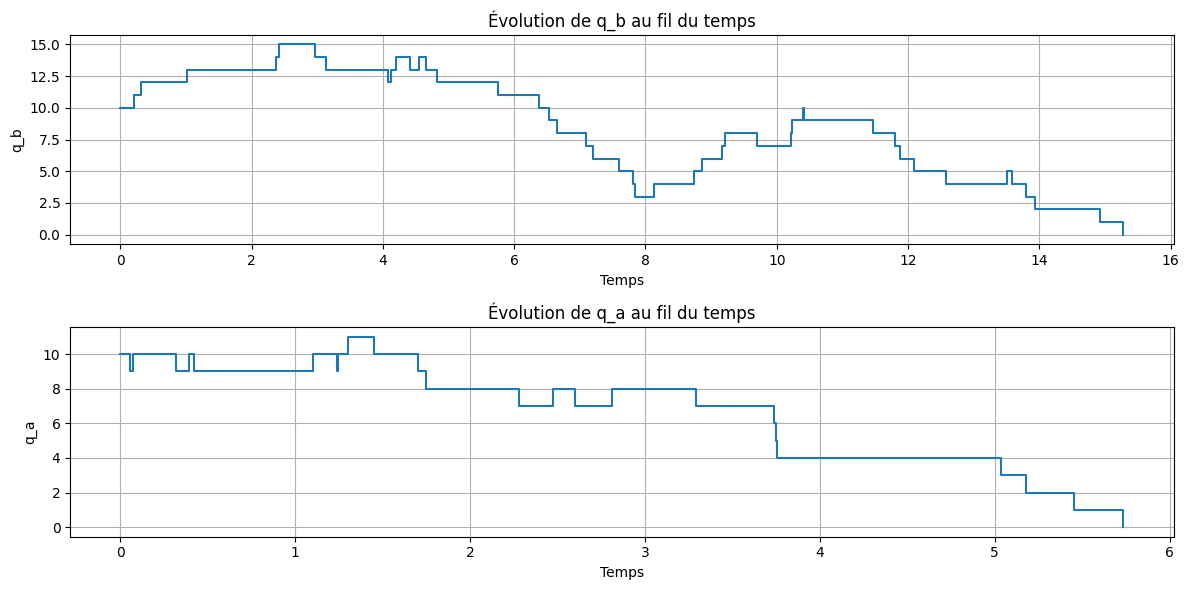

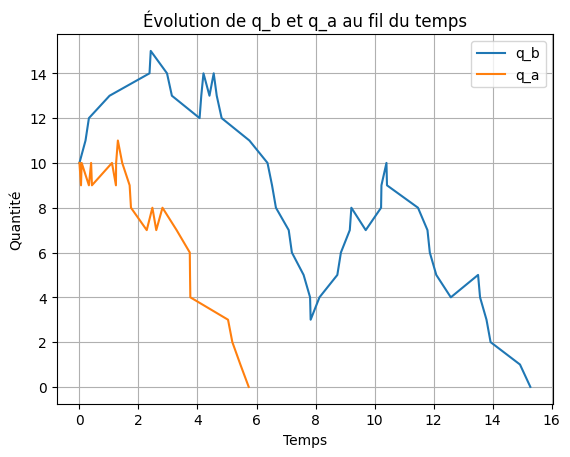

In [3]:
times_b, q_b_values, times_a, q_a_values = simulate_poisson_process_until_zero(LAMBDA_PLUS, LAMBDA_MINUS)
plot_poisson_process(times_b, q_b_values, times_a, q_a_values)
plot_combined(times_b, q_b_values, times_a, q_a_values)

## 2. Estimation Monte-Carlo de l'espérance du temps d'atteinte de 0

Pour estimer
$$\mathbb{E}[\tau], \qquad \tau = \inf\{t \ge 0 : q(t) = 0\},$$
on tire $M$ trajectoires indépendantes et on calcule la moyenne empirique
$$\hat{\mathbb{E}}[\tau] = \frac{1}{M}\sum_{i=1}^M \tau^{(i)}, \qquad \mathrm{IC}_{1-\alpha} = \hat{\mathbb{E}}[\tau] \pm z_{1-\alpha/2}\,\frac{\hat\sigma}{\sqrt{M}},$$
où $\hat\sigma$ est l'écart-type empirique. L'intervalle de confiance est asymptotiquement valide par TCL (les $\tau^{(i)}$ ont une variance finie sous $\lambda^- > \lambda^+$).

On distingue deux estimateurs :

- `estimate_time_to_zero_for_one_process` : $\mathbb{E}[\tau]$ pour un seul processus (file isolée).
- `estimate_time_to_zero` : $\mathbb{E}[\min(\tau_a, \tau_b)]$ pour deux files indépendantes (premier des deux à toucher 0).

In [4]:
def estimate_time_to_zero(lambda_plus, lambda_minus, q_0_a=Q_0_A, q_0_b=Q_0_B,
                          num_simulations=1000, quantile=0.95):
    """Monte-Carlo naïf de E[min(τ_a, τ_b)] avec intervalle de confiance."""
    times_to_zero = []
    for _ in range(num_simulations):
        times_b, _, times_a, _ = simulate_poisson_process_until_zero(
            lambda_plus, lambda_minus, q_0_a, q_0_b)
        times_to_zero.append(min(times_b[-1], times_a[-1]))
    estimate = np.mean(times_to_zero)
    z = sps.norm.ppf((1 + quantile) / 2)
    se = np.std(times_to_zero) / np.sqrt(num_simulations)
    lo, hi = estimate - z * se, estimate + z * se
    print(f"E[min(τ_a, τ_b)] ≈ {estimate:.2f}  "
          f"IC {int(quantile*100)}% : [{lo:.2f}, {hi:.2f}]")
    return estimate, lo, hi


def estimate_time_to_zero_for_one_process(lambda_plus, lambda_minus, q_0=Q_0_A,
                                           num_simulations=1000, quantile=0.95):
    """
    Monte-Carlo naïf de E[τ_0] pour une seule file.
    Réutilise simulate_only_one_process (chemin JIT si stopping_condition=None).
    """
    times_to_zero = [
        simulate_only_one_process(lambda_plus, lambda_minus, q_0)[0][-1]
        for _ in range(num_simulations)
    ]
    estimate = np.mean(times_to_zero)
    z = sps.norm.ppf((1 + quantile) / 2)
    se = np.std(times_to_zero) / np.sqrt(num_simulations)
    lo, hi = estimate - z * se, estimate + z * se
    print(f"E[τ_0] ≈ {estimate:.2f}  IC {int(quantile*100)}% : [{lo:.2f}, {hi:.2f}]")
    return estimate, lo, hi


In [5]:
t0 = _time.perf_counter()
estimate1, lower_IC_bound1, upper_IC_bound1 = estimate_time_to_zero(
    LAMBDA_PLUS, LAMBDA_MINUS, num_simulations=100_000, quantile=0.95)
print(f'  Temps MC (min τ) : {_time.perf_counter()-t0:.2f}s')

t0 = _time.perf_counter()
estimate1, lower_IC_bound1, upper_IC_bound1 = estimate_time_to_zero_for_one_process(
    LAMBDA_PLUS, LAMBDA_MINUS, num_simulations=100_000, quantile=0.95)
print(f'  Temps MC (τ unique) : {_time.perf_counter()-t0:.2f}s')


E[min(τ_a, τ_b)] ≈ 8.47  IC 95% : [8.44, 8.49]
  Temps MC (min τ) : 11.58s
E[τ_0] ≈ 12.51  IC 95% : [12.46, 12.56]
  Temps MC (τ unique) : 3.68s


## 3. Trajectoire dans le plan $(q_b, q_a)$

On peut visualiser conjointement les deux files en traçant la trajectoire $(q_b(t), q_a(t))$ dans le plan jusqu'au premier passage à 0 d'une des deux. Comme les deux processus ont leurs propres temps d'événement, on synchronise les échelles de temps via une recherche binaire (`np.searchsorted`) sur les temps fusionnés, en O($n \log n$). La densité d'occupation des points $(q_b, q_a)$ est encodée dans la **transparence** : les états visités fréquemment apparaissent opaques, les transitoires restent translucides. Le point rouge marque le départ et le vert l'arrêt (un des deux côtés à 0).

In [6]:
def trajectory_grid(times_b, q_b_values, times_a, q_a_values):
    tb = np.array(times_b)
    ta = np.array(times_a)
    qb = np.array(q_b_values)
    qa = np.array(q_a_values)

    # O(n log n) merge: for each event time, find the last known q_b and q_a via binary search
    t_stop = min(tb[-1], ta[-1])                                     
    all_times = np.sort(np.concatenate([ta, tb]))
    all_times = all_times[all_times <= t_stop]
    q_B = qb[np.searchsorted(tb, all_times, side='right') - 1]
    q_A = qa[np.searchsorted(ta, all_times, side='right') - 1]

    # Count visits per (bid, ask) grid point
    points = np.stack([q_B, q_A], axis=1)
    _, inverse, unique_counts = np.unique(points, axis=0, return_inverse=True, return_counts=True)
    counts = unique_counts[inverse].astype(float)

    # Rare points → transparent, frequent points → opaque
    min_alpha = 0.5
    span = counts.max() - counts.min()
    alphas = min_alpha + (1 - min_alpha) * (counts - counts.min()) / (span if span > 0 else 1)

    rgba = np.column_stack([
        np.full(len(q_B), 0.2),
        np.full(len(q_B), 0.4),
        np.full(len(q_B), 0.8),
        alphas,
    ])

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.plot(q_B, q_A, color='blue', alpha=0.5, linewidth=0.5, zorder=1)
    ax.scatter(q_B[1:-1], q_A[1:-1], c=rgba[1:-1], s=40, zorder=2)
    ax.set_title('Trajectoire de (Bid, Ask) dans le plan')
    plt.scatter([q_B[0]], [q_A[0]], s=40, zorder=2, c='red', label='Début')
    plt.scatter([q_B[-1]], [q_A[-1]], s=40, zorder=2, c='green', label='Fin')
    plt.legend()
    ax.set_xlabel('Bid (q_b)')
    ax.set_ylabel('Ask (q_a)')
    plt.grid(alpha=0.3)
    plt.show()


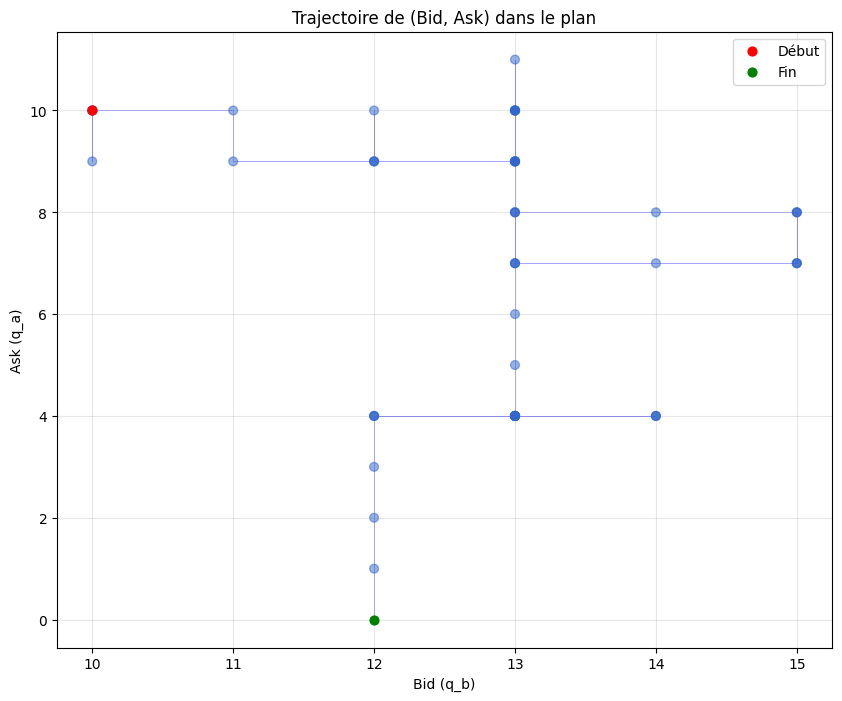

In [7]:
trajectory_grid(times_b, q_b_values, times_a, q_a_values)

## 4. Approximation diffusive (mouvement brownien avec dérive)

Lorsque les intensités $\lambda^\pm$ sont grandes (régime fluide), un théorème central limite fonctionnel pour les processus de Poisson centrés-renormalisés montre que
$$q(t) \;\xrightarrow[\lambda^\pm \to \infty]{}\; Q_t,$$
où $Q$ est solution de l'EDS
$$dQ_t = (\lambda^+ - \lambda^-)\,dt + \sqrt{\lambda^+ + \lambda^-}\,dW_t.$$

À l'instant $T$ (tant que la barrière 0 n'a pas été touchée), on a donc approximativement
$$q(T) \;\sim\; \mathcal{N}\!\left(q_0 + (\lambda^+ - \lambda^-)\,T,\; (\lambda^+ + \lambda^-)\,T\right).$$

L'histogramme des simulations Poisson est superposé à la densité gaussienne théorique pour valider visuellement cette approximation.

In [8]:
#Showing that Q_a can be approximated by a Brownian motion with drift lambda_plus - lambda_minus and variance lambda_plus + lambda_minus
def plot_approximation(T, lambda_plus, lambda_minus, num_simulations=1000, q_0 = Q_0_A):
    drift = lambda_plus - lambda_minus
    variance = lambda_plus + lambda_minus
    samples = []
    for _ in range(num_simulations):
        q = q_0
        t = 0
        while t < T:
            dt = np.random.exponential(1 / (lambda_plus + lambda_minus))
            t += dt
            q += 1 if np.random.rand() < lambda_plus / (lambda_plus + lambda_minus) else -1
        samples.append(q)
    plt.figure(figsize=(10, 6))
    plt.hist(samples, bins='auto', density=True, alpha=0.6, color='g', label='Simulations')
    x = np.linspace(min(samples), max(samples), 100)
    plt.plot(x, sps.norm.pdf(x, loc=q_0 + drift * T, scale=np.sqrt(variance * T)), 'r-', label='Approximation normale')
    plt.xlabel('q')
    plt.ylabel('Densité')
    plt.title('Distribution de q à l\'instant T')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


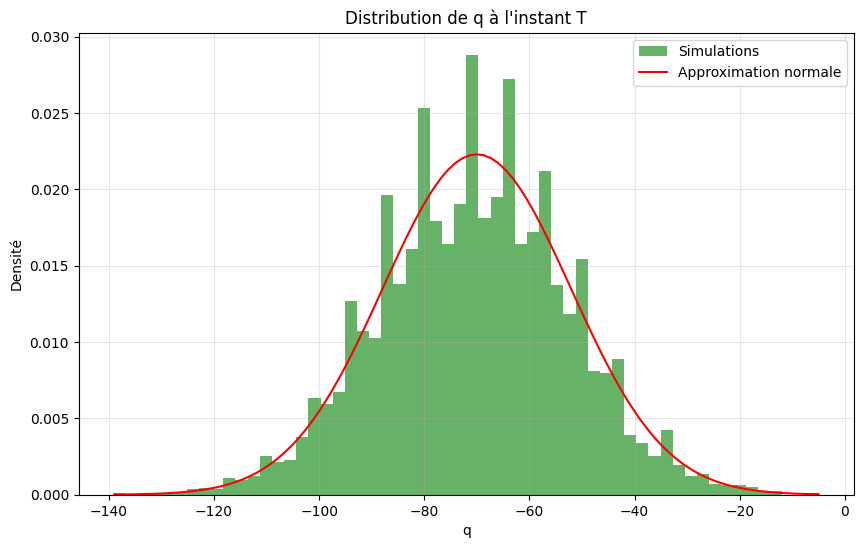

In [9]:
plot_approximation(100, LAMBDA_PLUS, LAMBDA_MINUS , num_simulations=10000, q_0 = Q_0_A)

## 5. Loi du temps d'atteinte de 0 (loi inverse-gaussienne)

Pour un mouvement brownien $X_t = q_0 + \mu t + \sigma W_t$ avec dérive **négative** ($\mu < 0$), le premier temps d'atteinte de 0
$$\tau = \inf\{t \ge 0 : X_t = 0\}$$
suit une **loi inverse-gaussienne** $\mathrm{IG}(\mu_{IG}, \lambda_{IG})$ de densité
$$f_\tau(t) = \sqrt{\frac{\lambda_{IG}}{2\pi t^3}}\,\exp\!\left(-\frac{\lambda_{IG}(t - \mu_{IG})^2}{2\,\mu_{IG}^2\,t}\right),$$
avec
$$\mu_{IG} = \frac{q_0}{|\mu|}, \qquad \lambda_{IG} = \frac{q_0^2}{\sigma^2}.$$

En convention SciPy, `sps.invgauss(mu = sigma**2 / (q_0 * |mu|), scale = q_0**2 / sigma**2)`. On compare ici la densité théorique à la fois à la simulation **Poisson exacte** (`stopping_time_distribution`) et à la simulation **brownienne discrétisée** (`stopping_time_distribution_brownian`), ce qui valide l'approximation diffusive sur la queue gauche du temps d'arrêt.

In [10]:
def stopping_time_distribution(lambda_plus, lambda_minus, q_0=Q_0_A, num_simulations=1000):
    stopping_times = []
    for _ in range(num_simulations):
        times, q_values = simulate_only_one_process(lambda_plus, lambda_minus, q_0)
        stopping_times.append(times[-1])
    drift = lambda_plus - lambda_minus
    sigma2 = lambda_plus + lambda_minus
    shape = q_0**2 / sigma2
    mu_sc = sigma2 / (q_0 * abs(drift))
    plt.figure(figsize=(10, 6))
    X = np.linspace(0.01, max(stopping_times), 300)
    plt.plot(X, sps.invgauss.pdf(X, mu=mu_sc, scale=shape), 'r-', label='Distribution inverse gaussienne théorique')
    plt.hist(stopping_times, bins='auto', density=True, alpha=0.6, color='b', label='Simulation Poisson')
    plt.xlabel("Temps jusqu'à ce que q atteigne zéro")
    plt.ylabel('Densité')
    plt.title("Distribution du temps d'arrêt pour q")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

def simulate_brownian_motion_until_zero(drift, variance, q_0=Q_0_A, dt=0.01):
    q = q_0
    t = 0.0
    while q > 0:
        q_prev = q
        t_prev = t
        q += drift * dt + np.sqrt(variance * dt) * np.random.randn()
        t += dt
    frac = q_prev / (q_prev - q)
    return t_prev + frac * dt

def stopping_time_distribution_brownian(drift, variance, q_0=Q_0_A, num_simulations=1000):
    stopping_times = [simulate_brownian_motion_until_zero(drift, variance, q_0) for _ in range(num_simulations)]
    shape = q_0**2 / variance
    mu_sc = variance / (q_0 * abs(drift))
    plt.figure(figsize=(10, 6))
    X = np.linspace(0.01, max(stopping_times), 300)
    plt.plot(X, sps.invgauss.pdf(X, mu=mu_sc, scale=shape), 'r-', label='Distribution inverse gaussienne théorique')
    plt.hist(stopping_times, bins='auto', density=True, alpha=0.6, color='m', label='Simulation Brownienne')
    plt.xlabel("Temps jusqu'à ce que q atteigne zéro (Brownien)")
    plt.ylabel('Densité')
    plt.title("Distribution du temps d'arrêt pour le processus brownien")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

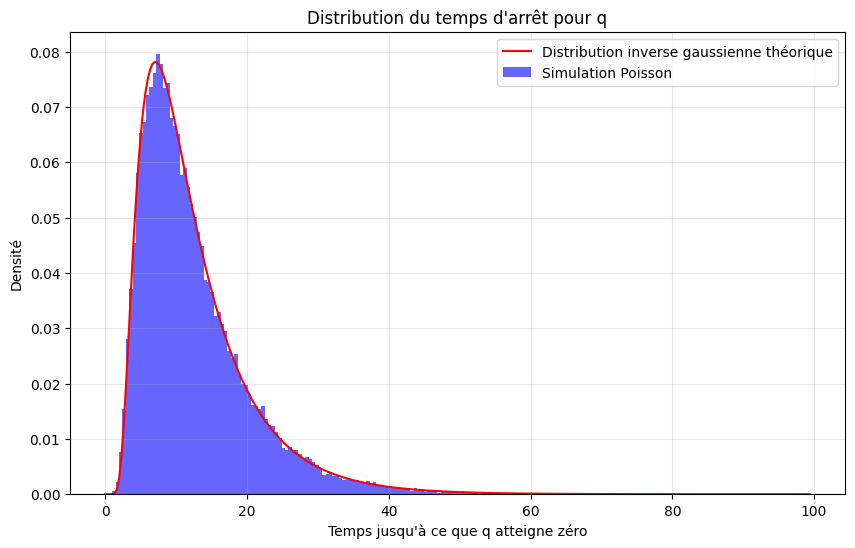

  Temps Poisson (JIT) : 2.62s


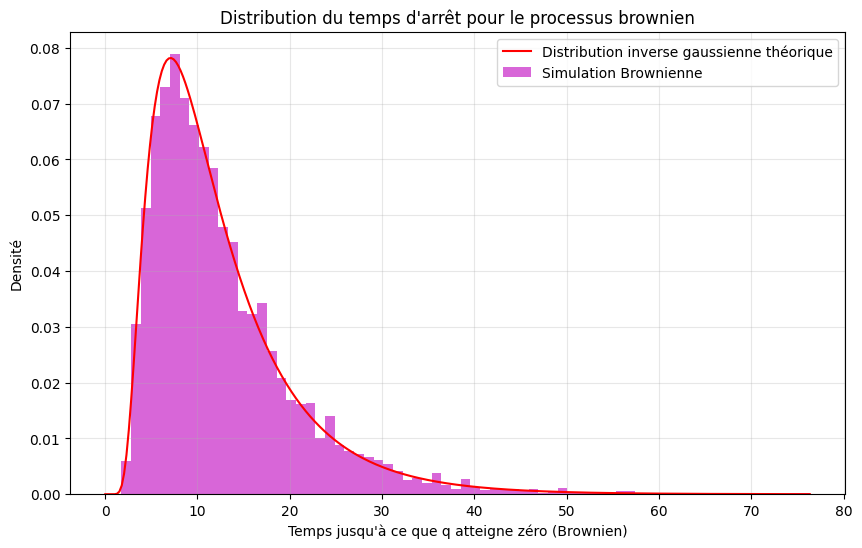

  Temps Brownien (Python) : 10.44s


In [11]:
t0 = _time.perf_counter()
stopping_time_distribution(LAMBDA_PLUS, LAMBDA_MINUS, q_0=Q_0_A, num_simulations=50_000)
print(f'  Temps Poisson (JIT) : {_time.perf_counter()-t0:.2f}s')

# Brownien : boucle Python (dt=0.01), N réduit en conséquence
t0 = _time.perf_counter()
stopping_time_distribution_brownian(
    LAMBDA_PLUS - LAMBDA_MINUS, LAMBDA_PLUS + LAMBDA_MINUS,
    q_0=Q_0_A, num_simulations=5_000)
print(f'  Temps Brownien (Python) : {_time.perf_counter()-t0:.2f}s')


### Validation : test d'adéquation à la loi inverse-gaussienne

L'approximation $\tau \approx \mathrm{IG}(\mu_{IG}, \lambda_{IG})$ avec $\mu_{IG} = q_0/|\mu|$ et $\lambda_{IG} = q_0^2/\sigma^2$ doit être confirmée numériquement. On vérifie deux choses :

1. **Adéquation des moments** : on compare $\mathbb E[\tau]_{\text{th}} = q_0/|\mu|$ et $\mathrm{Var}(\tau)_{\text{th}} = q_0\sigma^2/|\mu|^3$ aux estimations empiriques.
2. **Test de Kolmogorov-Smirnov** sur les $N=5000$ temps d'arrêt simulés Poisson, contre la CDF inverse-gaussienne théorique. Une $p$-value > 0.05 indique qu'on ne peut rejeter l'hypothèse d'adéquation.

In [12]:
def validate_inverse_gaussian(lambda_plus, lambda_minus, q_0=Q_0_A, num_simulations=5000):
    samples = np.empty(num_simulations)
    for i in range(num_simulations):
        times, _ = simulate_only_one_process(lambda_plus, lambda_minus, q_0)
        samples[i] = times[-1]

    drift = lambda_plus - lambda_minus
    sigma2 = lambda_plus + lambda_minus

    mean_th = q_0 / abs(drift)
    var_th = q_0 * sigma2 / abs(drift)**3
    mean_emp = samples.mean()
    var_emp = samples.var(ddof=1)

    mu_sc = sigma2 / (q_0 * abs(drift))
    shape = q_0**2 / sigma2
    ks_stat, ks_pval = sps.kstest(samples, lambda x: sps.invgauss.cdf(x, mu=mu_sc, scale=shape))

    print(f"--- Validation IG (q_0={q_0}, lambda+={lambda_plus}, lambda-={lambda_minus}) ---")
    print(f"Moyenne theorique  : {mean_th:.4f}     Moyenne empirique : {mean_emp:.4f}     ecart : {100*(mean_emp-mean_th)/mean_th:+.2f} %")
    print(f"Variance theorique : {var_th:.4f}     Variance empirique : {var_emp:.4f}    ecart : {100*(var_emp-var_th)/var_th:+.2f} %")
    print(f"Kolmogorov-Smirnov : statistique = {ks_stat:.4f}, p-value = {ks_pval:.4f}")
    return mean_th, mean_emp, var_th, var_emp, ks_stat, ks_pval


t0 = _time.perf_counter()
_ = validate_inverse_gaussian(LAMBDA_PLUS, LAMBDA_MINUS, q_0=Q_0_A, num_simulations=50_000)
print(f'  Temps validation IG : {_time.perf_counter()-t0:.2f}s')

--- Validation IG (q_0=10, lambda+=1.2, lambda-=2) ---
Moyenne theorique  : 12.5000     Moyenne empirique : 12.5004     ecart : +0.00 %
Variance theorique : 62.5000     Variance empirique : 63.0426    ecart : +0.87 %
Kolmogorov-Smirnov : statistique = 0.0052, p-value = 0.1278
  Temps validation IG : 2.06s


## 6. Probabilité que l'ask atteigne 0 avant le bid

Sous l'hypothèse de processus indépendants, on s'intéresse à la probabilité de **ruine asymétrique**
$$p(q_0^a, q_0^b) = \mathbb{P}(\tau_a < \tau_b),$$
où $\tau_a, \tau_b$ sont les premiers temps d'atteinte de 0 des deux files. Dans l'approximation brownienne avec drift commun $\mu = \lambda^+ - \lambda^-$, on retrouve une expression analytique de type *gambler's ruin* qui dépend des conditions initiales relatives ; ici on l'estime numériquement par Monte-Carlo sur une grille $(q_0^a, q_0^b) \in \{1,\dots,q_{\max}\}^2$ et on en trace la **surface 3D**. Cette surface est utilisée comme référence pour le tracé conjoint avec le temps moyen ci-dessous.

In [13]:
def probability_of_asking_price_reaching_zero_before_bid(lambda_plus, lambda_minus, q_0_a=Q_0_A, q_0_b=Q_0_B, num_simulations=1000):
    count_ask_zero_first = 0
    for _ in range(num_simulations):
        times_b, _, times_a, _ = simulate_poisson_process_until_zero(lambda_plus, lambda_minus, q_0_a=q_0_a, q_0_b=q_0_b)
        if times_a[-1] < times_b[-1]:
            count_ask_zero_first += 1
    probability = count_ask_zero_first / num_simulations
    return probability

def plot_proba_as_a_function_of_initial_conditions(lambda_plus, lambda_minus, num_simulations=1000, q_max=10):
    q_0_values = range(1, q_max + 1)
    Q0_A_vals, Q0_B_vals = np.meshgrid(list(q_0_values), list(q_0_values))
    probabilities = np.zeros_like(Q0_A_vals, dtype=float)

    for i, q0_a in enumerate(q_0_values):
        for j, q0_b in enumerate(q_0_values):
            probabilities[j, i] = probability_of_asking_price_reaching_zero_before_bid(
                lambda_plus, lambda_minus, q_0_a=q0_a, q_0_b=q0_b, num_simulations=num_simulations
            )

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    surf = ax.plot_surface(Q0_A_vals, Q0_B_vals, probabilities, cmap='viridis', alpha=0.85)

    ax.set_xlabel('q_0_a')
    ax.set_ylabel('q_0_b')
    ax.set_zlabel('P(ask → 0 first)')  # labelpad pushes it away from the axis
    ax.set_title("Probabilité que l'ask atteigne 0 avant le bid")

    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='P(ask → 0 first)')

    plt.tight_layout()
    plt.show()

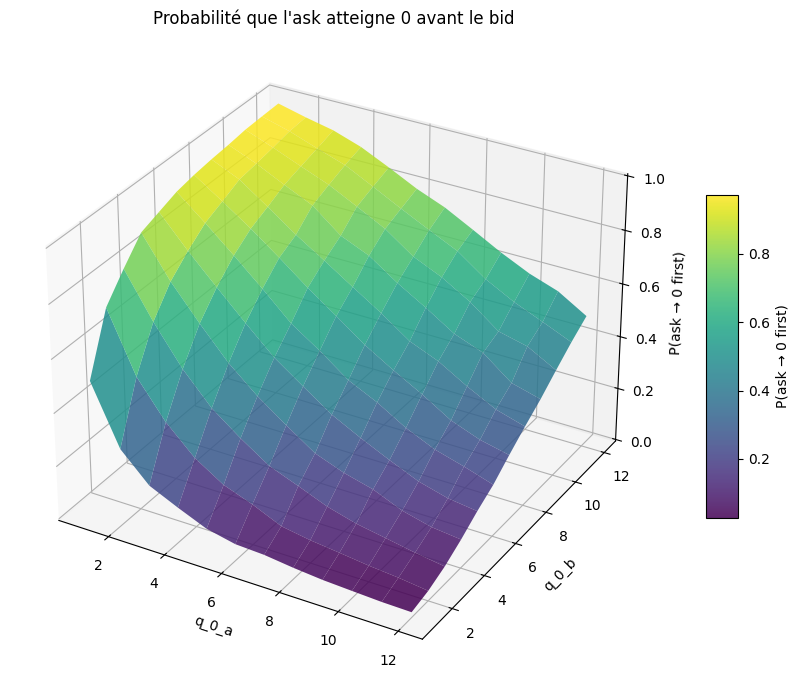

  Temps surface 3D probabilité : 54.55s


In [14]:
t0 = _time.perf_counter()
plot_proba_as_a_function_of_initial_conditions(
    LAMBDA_PLUS, LAMBDA_MINUS, num_simulations=5000, q_max=12)
print(f'  Temps surface 3D probabilité : {_time.perf_counter()-t0:.2f}s')


### Validation : surface MC vs prédiction brownienne pour $\mathbb P(\tau_a<\tau_b)$

Pour évaluer la qualité de l'estimateur MC, on compare la surface empirique à la **prédiction de l'approximation diffusive**. Sous la diffusion, $\tau_a \sim \mathrm{IG}(\mu_a, \lambda_a)$ et $\tau_b \sim \mathrm{IG}(\mu_b, \lambda_b)$ sont indépendants ; on calcule alors numériquement
$$\mathbb P(\tau_a < \tau_b) = \int_0^\infty f_{\tau_a}(t)\,\bigl(1 - F_{\tau_b}(t)\bigr)\,dt$$
par quadrature, et on confronte cette surface théorique à la surface MC. L'écart résiduel mesure conjointement (a) le bruit Monte-Carlo et (b) le biais de l'approximation brownienne sur des entiers petits.

Erreur absolue max  : 0.0574
Erreur absolue moy. : 0.0140
Erreur relative max : 72.413%


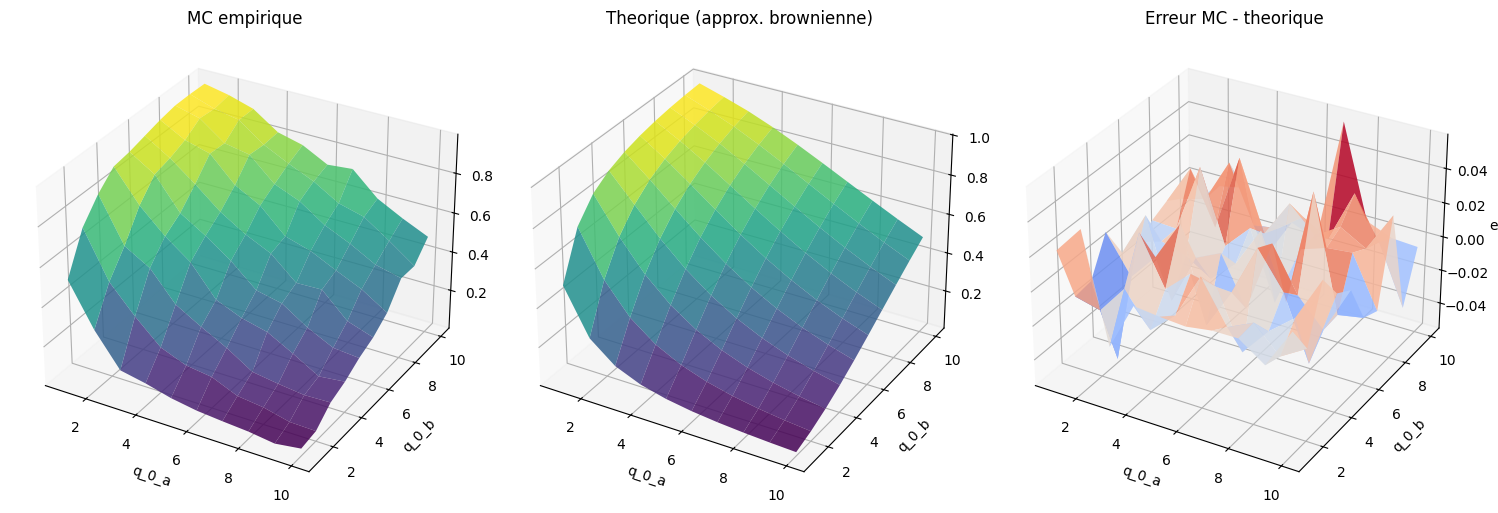

In [15]:
def gamblers_ruin_analytic(q_0_a, q_0_b, lambda_plus, lambda_minus):
    """
    Pour deux marches Bernoulli +1/-1 independantes avec p = lambda^+/(lambda^+ + lambda^-) < 1/2,
    la probabilite que la marche A atteigne 0 avant la marche B (entre A=q_a et B=q_b)
    n'a pas de forme close simple. On utilise donc l'approximation diffusive :
    P(tau_a < tau_b) = P(B^a_{q0_a} < B^b_{q0_b}) ou B^k est inverse-gaussien.
    Pour la version exacte de la marche, on calcule p_k = P(0 atteint avant n par marche
    de pas +1 prob p, -1 prob q=1-p, depart en k) = (r^k - r^n)/(1 - r^n) avec r = p/q,
    et on combine par independance avec la convolution sur le min des deux temps.
    """
    p = lambda_plus / (lambda_plus + lambda_minus)
    q = 1 - p
    r = p / q
    return r, p, q


def validate_gamblers_ruin_via_brownian(lambda_plus, lambda_minus, q_max=10):
    """
    Approximation diffusive : tau_k suit IG(mu_k, lambda_k) avec
       mu_k = k / |drift|, lambda_k = k^2 / sigma^2,  drift = lambda^+ - lambda^-, sigma^2 = lambda^+ + lambda^-.
    Pour deux IG independants on calcule P(tau_a < tau_b) par integration numerique.
    """
    drift = lambda_plus - lambda_minus
    sigma2 = lambda_plus + lambda_minus
    surface = np.zeros((q_max, q_max))
    for i, qa in enumerate(range(1, q_max + 1)):
        for j, qb in enumerate(range(1, q_max + 1)):
            mu_a = qa / abs(drift); shape_a = qa**2 / sigma2
            mu_b = qb / abs(drift); shape_b = qb**2 / sigma2
            # P(tau_a < tau_b) = int_0^inf f_a(t) (1 - F_b(t)) dt
            t_grid = np.linspace(1e-3, max(mu_a, mu_b) * 30, 5000)
            f_a = sps.invgauss.pdf(t_grid, mu=sigma2/(qa*abs(drift)), scale=shape_a)
            S_b = 1 - sps.invgauss.cdf(t_grid, mu=sigma2/(qb*abs(drift)), scale=shape_b)
            surface[j, i] = np.trapezoid(f_a * S_b, t_grid)
    return surface


def compare_proba_surface(lambda_plus, lambda_minus, num_simulations=500, q_max=10):
    surface_mc = np.zeros((q_max, q_max))
    for i, qa in enumerate(range(1, q_max + 1)):
        for j, qb in enumerate(range(1, q_max + 1)):
            surface_mc[j, i] = probability_of_asking_price_reaching_zero_before_bid(
                lambda_plus, lambda_minus, q_0_a=qa, q_0_b=qb, num_simulations=num_simulations
            )
    surface_th = validate_gamblers_ruin_via_brownian(lambda_plus, lambda_minus, q_max=q_max)
    err = surface_mc - surface_th
    abs_err = np.abs(err)

    print(f"Erreur absolue max  : {abs_err.max():.4f}")
    print(f"Erreur absolue moy. : {abs_err.mean():.4f}")
    print(f"Erreur relative max : {(abs_err / np.maximum(surface_th, 1e-3)).max():.3%}")

    fig = plt.figure(figsize=(15, 5))
    Q0_A, Q0_B = np.meshgrid(range(1, q_max + 1), range(1, q_max + 1))
    ax1 = fig.add_subplot(1, 3, 1, projection='3d')
    ax1.plot_surface(Q0_A, Q0_B, surface_mc, cmap='viridis', alpha=0.85)
    ax1.set_title("MC empirique"); ax1.set_xlabel('q_0_a'); ax1.set_ylabel('q_0_b'); ax1.set_zlabel('P')
    ax2 = fig.add_subplot(1, 3, 2, projection='3d')
    ax2.plot_surface(Q0_A, Q0_B, surface_th, cmap='viridis', alpha=0.85)
    ax2.set_title("Theorique (approx. brownienne)"); ax2.set_xlabel('q_0_a'); ax2.set_ylabel('q_0_b'); ax2.set_zlabel('P')
    ax3 = fig.add_subplot(1, 3, 3, projection='3d')
    ax3.plot_surface(Q0_A, Q0_B, err, cmap='coolwarm', alpha=0.85)
    ax3.set_title("Erreur MC - theorique"); ax3.set_xlabel('q_0_a'); ax3.set_ylabel('q_0_b'); ax3.set_zlabel('err')
    plt.tight_layout(); plt.show()
    return surface_mc, surface_th


_ = compare_proba_surface(LAMBDA_PLUS, LAMBDA_MINUS, num_simulations=500, q_max=10)

## 7. Surface 3D du temps moyen d'atteinte de 0

Dans le même esprit que la surface précédente $\mathbb{P}(\tau_a < \tau_b)$, on estime maintenant la surface du **temps moyen d'épuisement d'un côté** :
$$T(q_0^a, q_0^b) = \mathbb{E}[\min(\tau_a, \tau_b)],$$
pour chaque couple de conditions initiales $(q_0^a, q_0^b) \in \{1,\dots,q_{\max}\}^2$. La fonction `time_to_zero_surface` calcule simultanément :

- la moyenne empirique sur $M$ simulations,
- les bornes de l'intervalle de confiance asymptotique à 95% ($\hat T \pm z_{0.975}\,\hat\sigma/\sqrt M$),
- la probabilité $\mathbb{P}(\tau_a < \tau_b)$ (réutilisée pour comparaison avec la surface du chapitre 6).

On affiche ensuite les deux surfaces côte à côte, le maillage rouge/noir matérialisant l'intervalle de confiance autour de la surface des temps moyens. La surface $T$ est strictement croissante en chacune des deux variables : un plus gros volume initial repousse le moment d'épuisement.

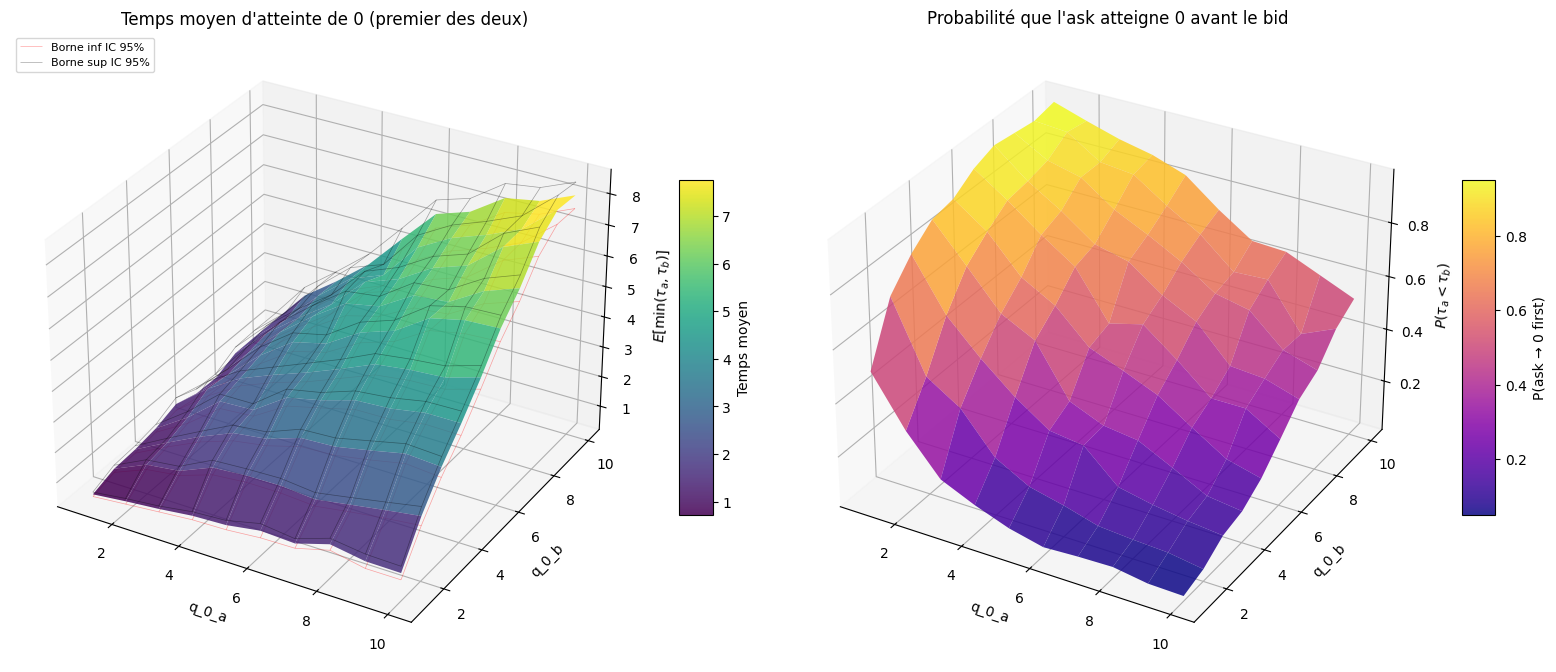

In [16]:
def time_to_zero_surface(lambda_plus, lambda_minus, num_simulations=300, q_max=10, quantile=0.95):
    q_0_values = list(range(1, q_max + 1))
    Q0_A_vals, Q0_B_vals = np.meshgrid(q_0_values, q_0_values)
    mean_times = np.zeros_like(Q0_A_vals, dtype=float)
    lower = np.zeros_like(Q0_A_vals, dtype=float)
    upper = np.zeros_like(Q0_A_vals, dtype=float)
    proba_ask_first = np.zeros_like(Q0_A_vals, dtype=float)
    z = sps.norm.ppf((1 + quantile) / 2)

    for i, q0_a in enumerate(q_0_values):
        for j, q0_b in enumerate(q_0_values):
            samples = np.empty(num_simulations)
            ask_first = 0
            for k in range(num_simulations):
                tb, _, ta, _ = simulate_poisson_process_until_zero(
                    lambda_plus, lambda_minus, q_0_a=q0_a, q_0_b=q0_b
                )
                samples[k] = min(tb[-1], ta[-1])
                if ta[-1] < tb[-1]:
                    ask_first += 1
            m = samples.mean()
            se = samples.std(ddof=1) / np.sqrt(num_simulations)
            mean_times[j, i] = m
            lower[j, i] = m - z * se
            upper[j, i] = m + z * se
            proba_ask_first[j, i] = ask_first / num_simulations

    return Q0_A_vals, Q0_B_vals, mean_times, lower, upper, proba_ask_first


def plot_time_and_probability_surfaces(lambda_plus, lambda_minus, num_simulations=300, q_max=10, quantile=0.95):
    Q0_A, Q0_B, mean_times, lower, upper, proba = time_to_zero_surface(
        lambda_plus, lambda_minus,
        num_simulations=num_simulations, q_max=q_max, quantile=quantile,
    )

    fig = plt.figure(figsize=(16, 7))

    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    surf1 = ax1.plot_surface(Q0_A, Q0_B, mean_times, cmap='viridis', alpha=0.85)
    ax1.plot_wireframe(Q0_A, Q0_B, lower, color='red', alpha=0.35, linewidth=0.5,
                       label=f'Borne inf IC {int(quantile*100)}%')
    ax1.plot_wireframe(Q0_A, Q0_B, upper, color='black', alpha=0.35, linewidth=0.5,
                       label=f'Borne sup IC {int(quantile*100)}%')
    ax1.set_xlabel('q_0_a')
    ax1.set_ylabel('q_0_b')
    ax1.set_zlabel(r'$E[\min(\tau_a, \tau_b)]$')
    ax1.set_title("Temps moyen d'atteinte de 0 (premier des deux)")
    fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, label='Temps moyen')
    ax1.legend(loc='upper left', fontsize=8)

    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    surf2 = ax2.plot_surface(Q0_A, Q0_B, proba, cmap='plasma', alpha=0.85)
    ax2.set_xlabel('q_0_a')
    ax2.set_ylabel('q_0_b')
    ax2.set_zlabel(r'$P(\tau_a < \tau_b)$')
    ax2.set_title("Probabilité que l'ask atteigne 0 avant le bid")
    fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, label='P(ask → 0 first)')

    plt.tight_layout()
    plt.show()

    return mean_times, lower, upper, proba


_ = plot_time_and_probability_surfaces(
    LAMBDA_PLUS, LAMBDA_MINUS, num_simulations=300, q_max=10, quantile=0.95
)

## 8. Modèle de Hawkes : intensité auto-excitée

On enrichit le modèle en remplaçant l'intensité constante $\lambda^-$ par une **intensité de Hawkes** auto-excitée :

$$\lambda^-(t) = \mu^- + \sum_{T_i < t} \alpha\, e^{-\beta(t - T_i)},$$

où les $T_i$ sont les temps de saut. Chaque événement augmente instantanément l'intensité de $\alpha$ ; entre deux événements, $\lambda^-$ relaxe exponentiellement vers la valeur de fond $\mu^-$ à un taux $\beta$.

**Stationnarité.** En régime stationnaire, l'intensité moyenne $\bar\lambda^-$ vérifie
$$\bar\lambda^- = \mu^- + \frac{\alpha}{\beta}\,\bar\lambda^-,$$
ce qui donne une intensité moyenne finie ssi $\alpha < \beta$. La fonction `determine_lambda_minus_stationarity` calcule la valeur stationnaire prédite à partir des paramètres.

In [17]:
def determine_lambda_minus_stationarity(mu_minus, alpha, beta, lambda_plus=LAMBDA_PLUS):
    return (mu_minus * beta - lambda_plus * alpha) / (beta - alpha)

## 9. Simulation par algorithme de thinning d'Ogata

L'intensité $\lambda^-(t)$ est non bornée a priori, mais bornée par morceaux entre deux événements (elle décroît exponentiellement). On simule donc le processus par l'**algorithme de thinning d'Ogata** :

1. Entre deux événements, on majore $\lambda^-(t)$ par $\bar\lambda = \max(\mu^-, \lambda^-(t_{\text{last}}))$.
2. On échantillonne un candidat exponentiel de paramètre $\bar\lambda + \lambda^+$.
3. Au candidat $t'$, on calcule la valeur effective $\lambda^-(t') = \mu^- + (\lambda^-_{t_{\text{last}}} - \mu^-)e^{-\beta(t' - t_{\text{last}})}$.
4. Avec un tirage uniforme on accepte/rejette : on accepte un saut $+1$ avec probabilité $\lambda^+/(\bar\lambda + \lambda^+)$, un saut $-1$ avec probabilité $\lambda^-(t')/(\bar\lambda + \lambda^+)$, sinon on rejette et on relaxe l'intensité.

Lors d'un événement effectif, on met à jour $\lambda^-$ par un saut $\pm \alpha$ selon le signe du saut sur $q$.

In [18]:
def hawkes_simulation(mu_minus, alpha, beta,lambda_plus = LAMBDA_PLUS, q_0 = Q_0, stopping_condition=lambda q,t: t > T):
    q = q_0
    t = 0
    t_last = 0
    lambda_bar = mu_minus
    lambda_minus_t = mu_minus
    lambda_minus_list = [lambda_minus_t]
    times = [t]
    q_values = [q]
    while not stopping_condition(q, t):
        lambda_bar = max(mu_minus, lambda_minus_t)
        sup_lambda = lambda_bar + lambda_plus
        time_to_next_event = np.random.exponential(1 / sup_lambda)
        t_prime = t + time_to_next_event
        lambda_pre = mu_minus + (lambda_minus_t - mu_minus) * np.exp(-beta * (t_prime - t_last))
        lambda_eff = max(lambda_pre, 0)
        U = np.random.rand()
        if U < lambda_plus / sup_lambda:
            q += 1
            t = t_prime
            t_last = t
            lambda_minus_t = lambda_pre - alpha
            times.append(t)
            q_values.append(q)
            lambda_minus_list.append(lambda_minus_t)
        elif U < (lambda_eff+lambda_plus) / sup_lambda:
            q -= 1
            t = t_prime
            t_last = t
            lambda_minus_t = lambda_pre + alpha
            times.append(t)
            q_values.append(q)
            lambda_minus_list.append(lambda_minus_t)
        else:
            lambda_minus_t = lambda_pre
            t_last = t_prime
            t = t_prime
        
    return times, q_values, lambda_minus_list

def plot_hawkes_process(times, q_values):
    plt.figure(figsize=(12, 6))
    plt.step(times, q_values, where='post')
    plt.title('Évolution de q au fil du temps (Hawkes)')
    plt.xlabel('Temps')
    plt.ylabel('q')
    plt.grid()
    plt.show()
    
def distribution_of_stopping_times_hawkes(mu_minus, alpha, beta, lambda_plus=LAMBDA_PLUS, q_0=Q_0, num_simulations=1000):
    stopping_times = []
    for _ in range(num_simulations):
        times, _, _ = hawkes_simulation(mu_minus, alpha, beta, lambda_plus, q_0=q_0, stopping_condition=lambda q,t: q == 0)
        stopping_times.append(times[-1])
    plt.figure(figsize=(10, 6))
    plt.hist(stopping_times, bins='auto', density=True, alpha=0.6, color='c', label='Simulation Hawkes')
    plt.xlabel("Temps jusqu'à ce que q atteigne zéro (Hawkes)")
    plt.ylabel('Densité')
    plt.title("Distribution du temps d'arrêt pour le processus Hawkes")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    
def plot_lambda_minus_over_time(times, lambda_minus_list):
    plt.figure(figsize=(12, 6))
    plt.step(times, lambda_minus_list, where='post')
    plt.title('Évolution de λ⁻ au fil du temps (Hawkes)')
    plt.xlabel('Temps')
    plt.ylabel('λ⁻(t)')
    plt.grid()
    plt.show()

def distribution_last_lambda_minus(T=T, num_simulations=1000, mu_minus=2, alpha=0.5, beta=1, lambda_plus=LAMBDA_PLUS, q_0=Q_0):
    stationnary_lambda_minus = determine_lambda_minus_stationarity(mu_minus, alpha, beta, lambda_plus)
    last_lambda_minus_values = []
    for _ in range(num_simulations):
        times, _, lambda_minus_list = hawkes_simulation(mu_minus, alpha, beta, lambda_plus, q_0=q_0, stopping_condition=lambda q,t: t > T)
        times_arr = np.array(times)
        idx = np.searchsorted(times_arr, T, side='right') - 1
        lambda_at_T = mu_minus + (lambda_minus_list[idx] - mu_minus) * np.exp(-beta * (T - times[idx]))
        last_lambda_minus_values.append(lambda_at_T)
    plt.figure(figsize=(10, 6))
    plt.hist(last_lambda_minus_values, bins='auto', density=True, alpha=0.6, color='m', label='Simulation Hawkes')
    plt.xlabel("Valeur de λ⁻ à l'instant T")
    plt.ylabel('Densité')
    plt.title("Distribution de λ⁻ à l'instant T pour le processus Hawkes")
    plt.axvline(stationnary_lambda_minus, color='r', linestyle='--', label=f'λ⁻ stationnaire ≈ {stationnary_lambda_minus:.2f}')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    

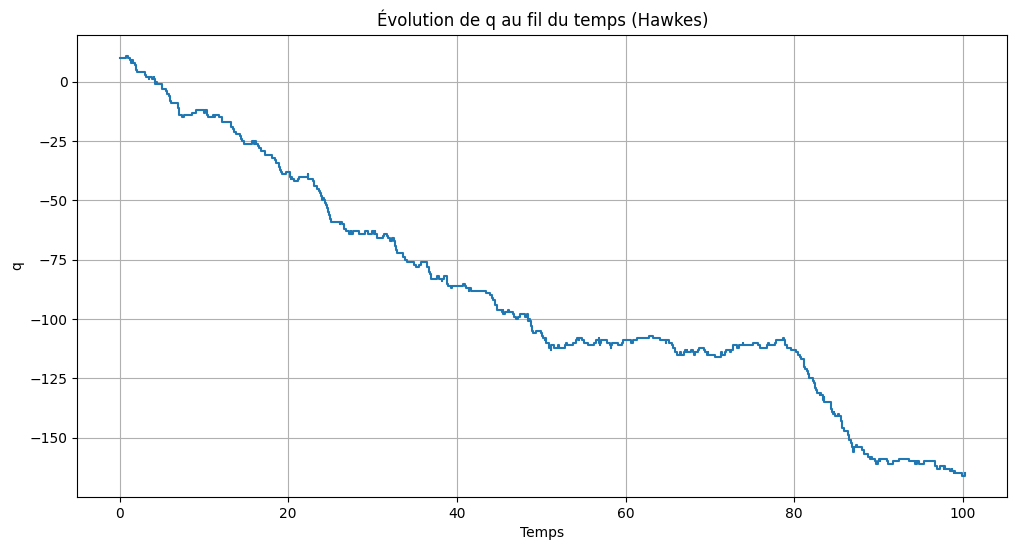

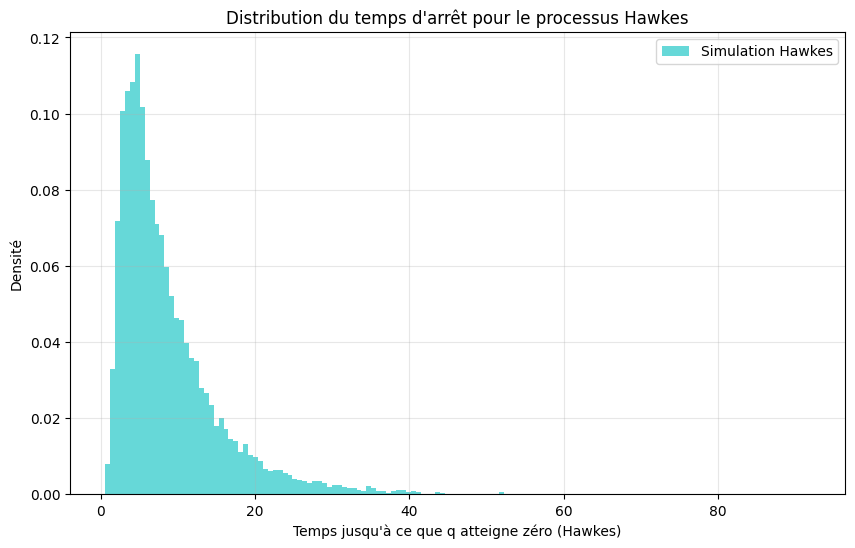

In [19]:
times, q_values, lambda_minus_list = hawkes_simulation(mu_minus=2, alpha=0.5, beta=1, lambda_plus=LAMBDA_PLUS, q_0=Q_0, stopping_condition=lambda q,t: t > T)
plot_hawkes_process(times, q_values)
distribution_of_stopping_times_hawkes (mu_minus=2, alpha=0.5, beta=1, num_simulations=10000)


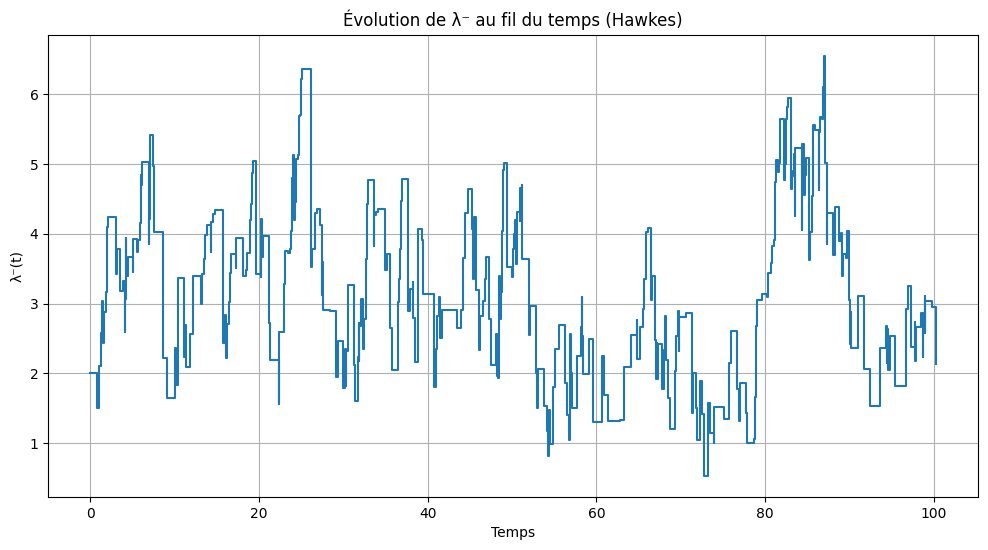

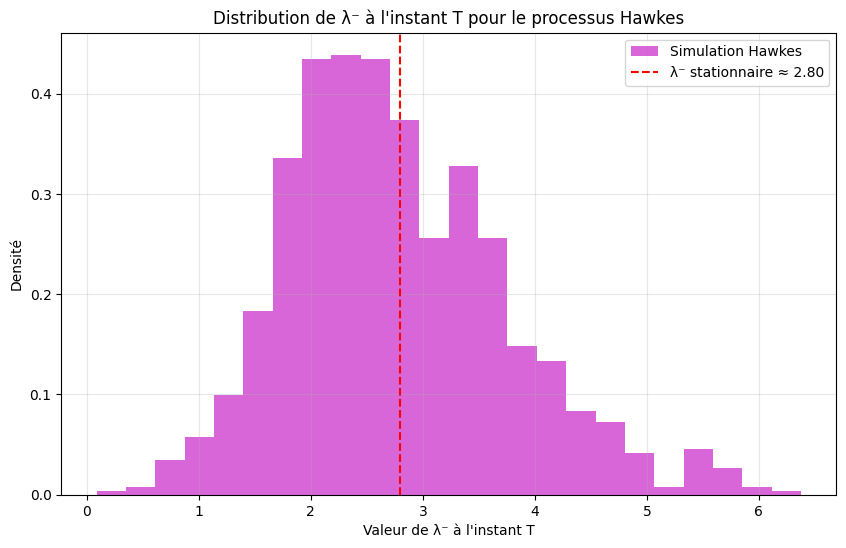

In [20]:
plot_lambda_minus_over_time(times, lambda_minus_list)
distribution_last_lambda_minus(T=1000, num_simulations=1000, mu_minus=2, alpha=0.5, beta=1, lambda_plus=LAMBDA_PLUS, q_0=Q_0)

### Validation : moyenne stationnaire de $\lambda^-$

Le calcul de point fixe donne, pour le Hawkes ouvert sur les sauts $\pm 1$ symétriques autour de $\mu^-$ :
$$\bar\lambda^-_\infty = \frac{\mu^-\beta - \lambda^+\alpha}{\beta - \alpha}.$$
Avec $\mu^-=2,\ \alpha=0.5,\ \beta=1,\ \lambda^+=1.2$ on attend $\bar\lambda^-_\infty = 2.8$.

On le vérifie en simulant $N$ trajectoires longues ($T=2000$) avec $q_0$ très grand (pour ne pas s'arrêter en 0), en jetant un *burn-in* initial pour éliminer le transitoire, puis en calculant la **moyenne temporelle** de $\lambda^-(t)$ sur chaque trajectoire. La moyenne d'ensemble doit être proche de la valeur théorique.

In [21]:
def validate_stationary_lambda_minus(mu_minus=2, alpha=0.5, beta=1, lambda_plus=LAMBDA_PLUS,
                                     T_long=2000, num_simulations=200, burn_in=200):
    theoretical = determine_lambda_minus_stationarity(mu_minus, alpha, beta, lambda_plus)
    empirical_means = []
    for _ in range(num_simulations):
        times, _, lambda_minus_list = hawkes_simulation(
            mu_minus, alpha, beta, lambda_plus, q_0=10**6,
            stopping_condition=lambda q, t: t > T_long,
        )
        times_arr = np.asarray(times)
        lam_arr = np.asarray(lambda_minus_list)
        mask = times_arr >= burn_in
        if mask.sum() < 2:
            continue
        t_kept = times_arr[mask]
        lam_kept = lam_arr[mask]
        dt = np.diff(t_kept)
        time_avg = np.sum(lam_kept[:-1] * dt) / (t_kept[-1] - t_kept[0])
        empirical_means.append(time_avg)

    empirical_means = np.array(empirical_means)
    mean_emp = empirical_means.mean()
    std_emp = empirical_means.std(ddof=1)
    se = std_emp / np.sqrt(len(empirical_means))
    z = sps.norm.ppf(0.975)
    print(f"Valeur theorique stationnaire de lambda^- : {theoretical:.4f}")
    print(f"Moyenne empirique (n={len(empirical_means)} trajectoires, T={T_long}, burn-in={burn_in}) : "
          f"{mean_emp:.4f} +/- {z*se:.4f} (IC 95%)")
    print(f"Ecart relatif : {100*(mean_emp - theoretical)/theoretical:+.2f} %")
    return theoretical, mean_emp, se


t0 = _time.perf_counter()
_ = validate_stationary_lambda_minus(mu_minus=2, alpha=0.5, beta=1, lambda_plus=LAMBDA_PLUS,
                                     T_long=2000, num_simulations=200, burn_in=200)
print(f'  Temps validation λ stationnaire : {_time.perf_counter()-t0:.2f}s')

Valeur theorique stationnaire de lambda^- : 2.8000
Moyenne empirique (n=200 trajectoires, T=2000, burn-in=200) : 2.9649 +/- 0.0079 (IC 95%)
Ecart relatif : +5.89 %
  Temps validation λ stationnaire : 5.83s


## 10. Processus de Hawkes couplés (Bid / Ask)

On introduit deux files (bid et ask) avec leurs intensités propres $\lambda^-_a$ et $\lambda^-_b$, **mutuellement excitées** : un événement sur l'ask diminue l'intensité côté ask et augmente celle côté bid (et réciproquement). Cela modélise grossièrement la propagation d'un déséquilibre — quand un côté du carnet se vide, la pression de marché s'accumule de l'autre côté.

$$
\lambda^-_a(t) = \mu^-_a + \sum_{T_i^a < t} \alpha_a^{ii}\, e^{-\beta(t - T_i^a)} + \sum_{T_j^b < t} \alpha_a^{ij}\, e^{-\beta(t - T_j^b)}, \qquad \text{(idem pour } \lambda^-_b\text{)}.
$$

Sur le plan algorithmique, on combine un thinning d'Ogata global (avec borne $\bar\lambda_a + \bar\lambda_b + \lambda^+_a + \lambda^+_b$) et la mise à jour conjointe des deux intensités à chaque événement.

In [22]:
def simulated_coupled_hawkes_processes(mu_minus_a, mu_minus_b, alpha, beta, lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS, q_0_a=Q_0_A, q_0_b=Q_0_B):
    q_a = q_0_a
    q_b = q_0_b
    t = 0
    t_last_a = 0
    t_last_b = 0
    lambda_bar_a = mu_minus_a
    lambda_bar_b = mu_minus_b
    lambda_minus_a_t = mu_minus_a
    lambda_minus_b_t = mu_minus_b
    times = [t]
    times_a = [t]
    times_b = [t]
    q_a_values = [q_a]
    q_b_values = [q_b]
    while q_a > 0 and q_b > 0:
        lambda_bar_a = max(mu_minus_a, lambda_minus_a_t)
        lambda_bar_b = max(mu_minus_b, lambda_minus_b_t)
        sup_lambda = lambda_bar_a + lambda_bar_b + lambda_plus_a + lambda_plus_b
        time_to_next_event = np.random.exponential(1 / sup_lambda)
        t_prime = t + time_to_next_event
        lambda_pre_a = mu_minus_a + (lambda_minus_a_t - mu_minus_a) * np.exp(-beta * (t_prime - t_last_a))
        lambda_pre_b = mu_minus_b + (lambda_minus_b_t - mu_minus_b) * np.exp(-beta * (t_prime - t_last_b))
        lambda_eff_a = max(lambda_pre_a, 0)
        lambda_eff_b = max(lambda_pre_b, 0)
        U = np.random.rand()
        if U < lambda_plus_a / sup_lambda:
            q_a += 1
            t = t_prime
            t_last_a = t
            lambda_minus_a_t = lambda_pre_a - alpha
            lambda_minus_b_t = lambda_pre_b + alpha
            times.append(t)
            times_a.append(t)
            q_a_values.append(q_a)
        elif U < (lambda_eff_a+lambda_plus_a) / sup_lambda:
            q_a -= 1
            t = t_prime
            t_last_a = t
            lambda_minus_a_t = lambda_pre_a + alpha
            lambda_minus_b_t = lambda_pre_b - alpha
            times.append(t)
            times_a.append(t)   
            q_a_values.append(q_a)
        elif U < (lambda_bar_a+lambda_plus_a) / sup_lambda:
            lambda_minus_a_t = lambda_pre_a
            lambda_minus_b_t = lambda_pre_b
            t_last_a = t_prime
            t = t_prime
        elif U < (lambda_bar_a+lambda_plus_a+lambda_plus_b) / sup_lambda:
            q_b += 1
            t = t_prime
            t_last_b = t
            lambda_minus_b_t = lambda_pre_b - alpha
            lambda_minus_a_t = lambda_pre_a + alpha
            times.append(t)
            times_b.append(t)
            q_b_values.append(q_b)
        elif U < (lambda_bar_a+lambda_plus_a+lambda_eff_b+lambda_plus_b) / sup_lambda:
            q_b -= 1
            t = t_prime
            t_last_b = t
            lambda_minus_b_t = lambda_pre_b + alpha
            lambda_minus_a_t = lambda_pre_a - alpha
            times.append(t)
            times_b.append(t)
            q_b_values.append(q_b)
        else:
            lambda_minus_b_t = lambda_pre_b
            lambda_minus_a_t = lambda_pre_a
            t_last_b = t_prime
            t = t_prime
    return times, times_a, times_b, q_a_values, q_b_values


def plot_coupled_hawkes_process(times, times_a, times_b, q_a_values, q_b_values):
    plt.figure(figsize=(12, 6))
    plt.subplot(2, 1, 1)
    plt.step(times_a, q_a_values, where='post')
    plt.title('Évolution de q_a au fil du temps (Hawkes couplé)')
    plt.xlabel('Temps')
    plt.ylabel('q_a')
    plt.grid()
    plt.subplot(2, 1, 2)
    plt.step(times_b, q_b_values, where='post')
    plt.title('Évolution de q_b au fil du temps (Hawkes couplé)')
    plt.xlabel('Temps')
    plt.ylabel('q_b')
    plt.tight_layout()
    plt.grid()
    plt.show()
    
def plot_stopping_time_distribution_coupled_hawkes(mu_minus_a, mu_minus_b, alpha, beta, lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS, q_0_a=Q_0_A, q_0_b=Q_0_B, num_simulations=1000):
    stopping_times = []
    for _ in range(num_simulations):
        times,_ ,_ , _, _ = simulated_coupled_hawkes_processes(mu_minus_a, mu_minus_b, alpha, beta, lambda_plus_a, lambda_plus_b, q_0_a, q_0_b)
        stopping_times.append(times[-1])
    plt.figure(figsize=(10, 6))
    plt.hist(stopping_times, bins='auto', density=True, alpha=0.6, color='purple', label='Simulation Hawkes couplé')
    plt.xlabel("Temps jusqu'à ce que q_a ou q_b atteigne zéro (Hawkes couplé)")
    plt.ylabel('Densité')
    plt.title("Distribution du temps d'arrêt pour les processus Hawkes couplés")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

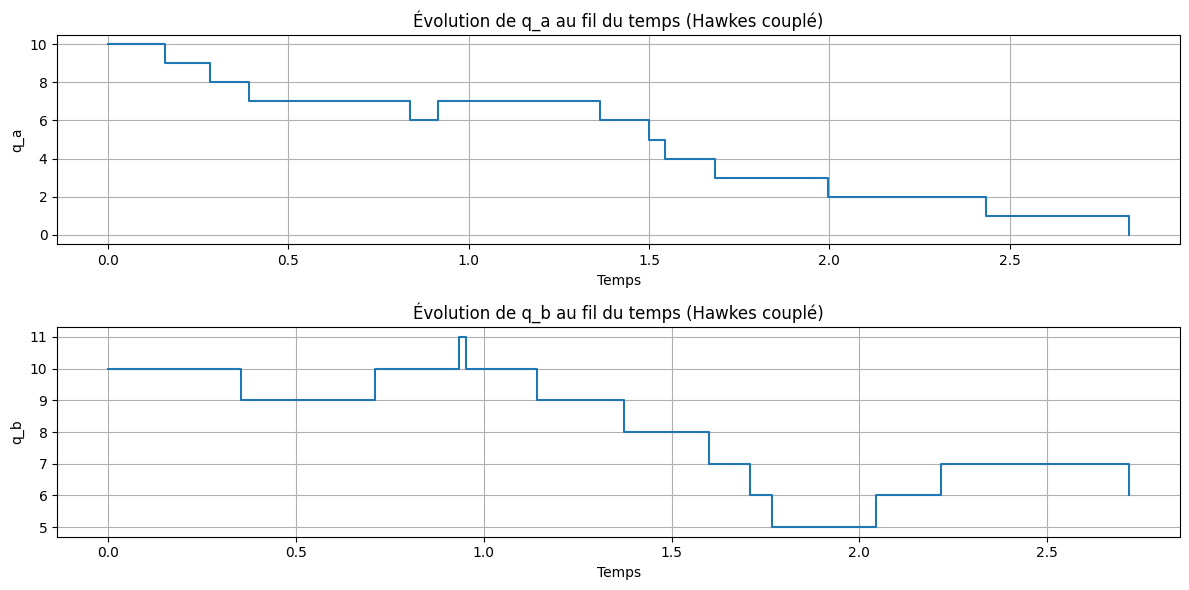

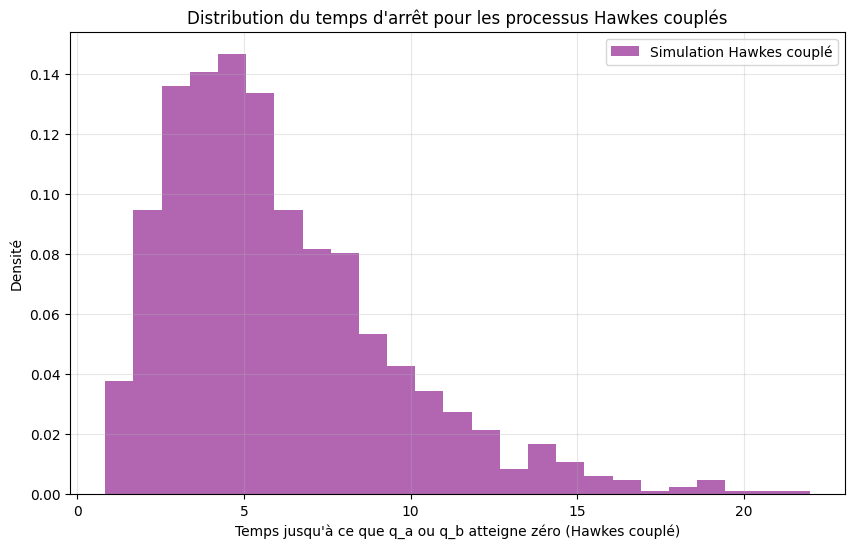

In [23]:
times,times_a, times_b, q_a_values, q_b_values = simulated_coupled_hawkes_processes(mu_minus_a=2, mu_minus_b=2, alpha=0.5, beta=1, lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS, q_0_a=Q_0_A, q_0_b=Q_0_B)
plot_coupled_hawkes_process(times, times_a, times_b, q_a_values, q_b_values)
plot_stopping_time_distribution_coupled_hawkes(mu_minus_a=2, mu_minus_b=2, alpha=0.5, beta=1, lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS, q_0_a=Q_0_A, q_0_b=Q_0_B)

### Surfaces 3D pour le processus de Hawkes couplé

On reproduit ici les deux surfaces 3D estimées à la section §7 (cas Poisson indépendant), mais cette fois sous le **modèle de Hawkes couplé** introduit ci-dessus. Sur la grille $(q_0^a, q_0^b) \in \{1,\dots,q_{\max}\}^2$, on estime par Monte-Carlo :

- $T(q_0^a, q_0^b) = \mathbb{E}[\min(\tau_a, \tau_b)]$ — temps moyen avant qu'un côté ne s'épuise,
- $p(q_0^a, q_0^b) = \mathbb{P}(\tau_a < \tau_b)$ — probabilité que l'ask cède en premier,

avec leurs intervalles de confiance asymptotiques à 95% (matérialisés par les wireframes rouge/noir autour de la surface des temps moyens).

**Différence majeure avec le cas Poisson.** Contrairement à la ruine du gambler dans le cas Poisson indépendant, il n'existe pas ici de formule analytique simple : le couplage entre $\lambda^-_a$ et $\lambda^-_b$ rend le système non-Markovien dans $(q_a, q_b)$ seul (il faut adjoindre l'état des intensités $(\lambda^-_a, \lambda^-_b)$). Le Monte-Carlo reste cependant valide.

**Lectures attendues des surfaces.**

- Lorsque $\mu^-_a = \mu^-_b$ (cas symétrique), la surface $p$ doit être symétrique le long de la diagonale $q_0^a = q_0^b$, et $p \approx 1/2$ sur cette diagonale.
- Pour des paramètres asymétriques ($\mu^-_a \neq \mu^-_b$), la surface $p$ s'écarte de la diagonale, traduisant un côté plus fragile.
- L'**auto-excitation** ($\alpha > 0$) tend à raccourcir $T$ par rapport au cas Poisson, un phénomène déjà visible dans la comparaison de la section §11.

La simulation de Hawkes couplés étant nettement plus coûteuse que celle des Poisson indépendants (thinning d'Ogata global avec mises à jour des deux intensités à chaque itération), on prend `num_simulations=200` par défaut au lieu de 300.

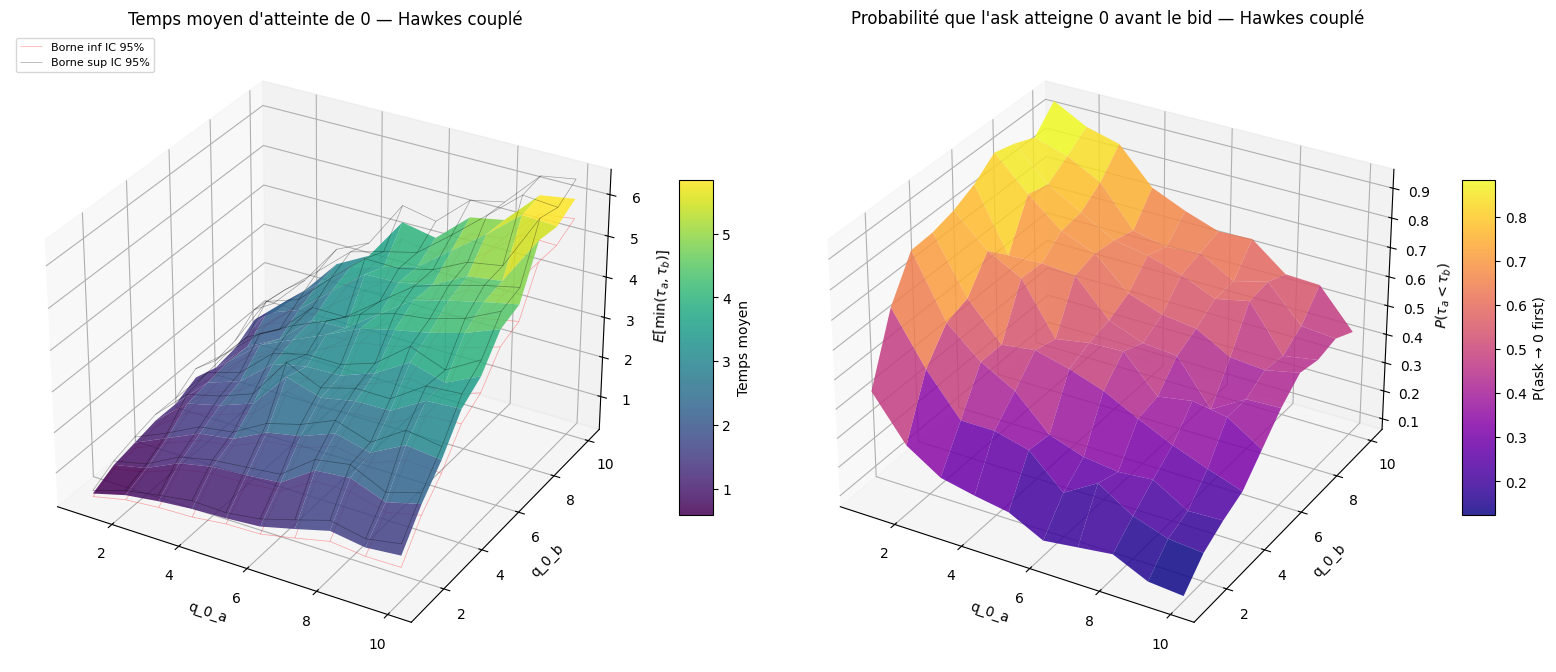

In [24]:
def coupled_hawkes_surface(mu_minus_a, mu_minus_b, alpha, beta,
                           lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                           num_simulations=200, q_max=10, quantile=0.95):
    q_0_values = list(range(1, q_max + 1))
    Q0_A_vals, Q0_B_vals = np.meshgrid(q_0_values, q_0_values)
    mean_times = np.zeros_like(Q0_A_vals, dtype=float)
    lower = np.zeros_like(Q0_A_vals, dtype=float)
    upper = np.zeros_like(Q0_A_vals, dtype=float)
    proba_ask_first = np.zeros_like(Q0_A_vals, dtype=float)
    z = sps.norm.ppf((1 + quantile) / 2)

    for i, q0_a in enumerate(q_0_values):
        for j, q0_b in enumerate(q_0_values):
            samples = np.empty(num_simulations)
            ask_first = 0
            for k in range(num_simulations):
                times, _, _, q_a_values, q_b_values = simulated_coupled_hawkes_processes(
                    mu_minus_a, mu_minus_b, alpha, beta,
                    lambda_plus_a=lambda_plus_a, lambda_plus_b=lambda_plus_b,
                    q_0_a=q0_a, q_0_b=q0_b,
                )
                samples[k] = times[-1]
                if q_a_values[-1] == 0:
                    ask_first += 1
            m = samples.mean()
            se = samples.std(ddof=1) / np.sqrt(num_simulations)
            mean_times[j, i] = m
            lower[j, i] = m - z * se
            upper[j, i] = m + z * se
            proba_ask_first[j, i] = ask_first / num_simulations

    return Q0_A_vals, Q0_B_vals, mean_times, lower, upper, proba_ask_first


def plot_coupled_hawkes_surfaces(mu_minus_a, mu_minus_b, alpha, beta,
                                 lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                                 num_simulations=200, q_max=10, quantile=0.95):
    Q0_A, Q0_B, mean_times, lower, upper, proba = coupled_hawkes_surface(
        mu_minus_a, mu_minus_b, alpha, beta,
        lambda_plus_a=lambda_plus_a, lambda_plus_b=lambda_plus_b,
        num_simulations=num_simulations, q_max=q_max, quantile=quantile,
    )

    fig = plt.figure(figsize=(16, 7))

    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    surf1 = ax1.plot_surface(Q0_A, Q0_B, mean_times, cmap='viridis', alpha=0.85)
    ax1.plot_wireframe(Q0_A, Q0_B, lower, color='red', alpha=0.35, linewidth=0.5,
                       label=f'Borne inf IC {int(quantile*100)}%')
    ax1.plot_wireframe(Q0_A, Q0_B, upper, color='black', alpha=0.35, linewidth=0.5,
                       label=f'Borne sup IC {int(quantile*100)}%')
    ax1.set_xlabel('q_0_a')
    ax1.set_ylabel('q_0_b')
    ax1.set_zlabel(r'$E[\min(\tau_a, \tau_b)]$')
    ax1.set_title("Temps moyen d'atteinte de 0 — Hawkes couplé")
    fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, label='Temps moyen')
    ax1.legend(loc='upper left', fontsize=8)

    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    surf2 = ax2.plot_surface(Q0_A, Q0_B, proba, cmap='plasma', alpha=0.85)
    ax2.set_xlabel('q_0_a')
    ax2.set_ylabel('q_0_b')
    ax2.set_zlabel(r'$P(\tau_a < \tau_b)$')
    ax2.set_title("Probabilité que l'ask atteigne 0 avant le bid — Hawkes couplé")
    fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, label='P(ask → 0 first)')

    plt.tight_layout()
    plt.show()

    return mean_times, lower, upper, proba


_ = plot_coupled_hawkes_surfaces(
    mu_minus_a=2, mu_minus_b=2, alpha=0.5, beta=1,
    lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
    num_simulations=200, q_max=10, quantile=0.95,
)

## 11. Comparaison des distributions de temps d'arrêt

On compare les distributions du temps d'atteinte de 0 obtenues sous différents modèles : Poisson seul, premier de deux Poisson indépendants, Hawkes seul, et Hawkes couplé. On visualise ainsi l'impact respectif :

- du **second processus** (passage à $\min(\tau_a,\tau_b)$, qui réduit mécaniquement le temps d'arrêt),
- de l'**auto-excitation** (queues plus lourdes, variance plus grande),
- du **couplage** entre les deux files (asymétrie systématique entre les côtés bid et ask).

In [25]:
#comparing all different stopping times from individual poisson, first of two poisson, hawkes and coupled hawkes
def compare_stopping_time_distributions(mu_minus, alpha, beta, lambda_plus=LAMBDA_PLUS, q_0=Q_0, num_simulations=1000):
    stopping_times_poisson = []
    stopping_times_first_of_two = []
    stopping_times_hawkes = []
    stopping_times_coupled_hawkes = []
    
    for _ in range(num_simulations):
        # Poisson
        times, _ = simulate_only_one_process(lambda_plus, mu_minus, q_0)
        stopping_times_poisson.append(times[-1])
        
        # First of two Poisson
        times_b, _, times_a, _ = simulate_poisson_process_until_zero(lambda_plus, mu_minus, q_0_a=q_0, q_0_b=q_0)
        stopping_times_first_of_two.append(min(times_b[-1], times_a[-1]))
        
        # Hawkes
        times_hawkes, _, _ = hawkes_simulation(mu_minus, alpha, beta, lambda_plus, q_0=q_0, stopping_condition=lambda q,t: q == 0)
        stopping_times_hawkes.append(times_hawkes[-1])
        
        # Coupled Hawkes
        times_coupled_hawkes, _, _, _, _ = simulated_coupled_hawkes_processes(mu_minus, mu_minus, alpha, beta, lambda_plus, lambda_plus, q_0, q_0)
        stopping_times_coupled_hawkes.append(times_coupled_hawkes[-1])
    
    plt.figure(figsize=(12, 8))
    plt.hist(stopping_times_poisson, bins='auto', density=True, alpha=0.6, color='b', label='Poisson individuel')
    plt.hist(stopping_times_first_of_two, bins='auto', density=True, alpha=0.6, color='g', label='Premier des deux Poisson')
    plt.hist(stopping_times_hawkes, bins='auto', density=True, alpha=0.6, color='r', label='Hawkes')
    plt.hist(stopping_times_coupled_hawkes, bins='auto', density=True, alpha=0.6, color='purple', label='Hawkes couplé')
    plt.xlabel("Temps jusqu'à ce que q atteigne zéro")
    plt.ylabel('Densité')
    plt.title("Comparaison des distributions du temps d'arrêt")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

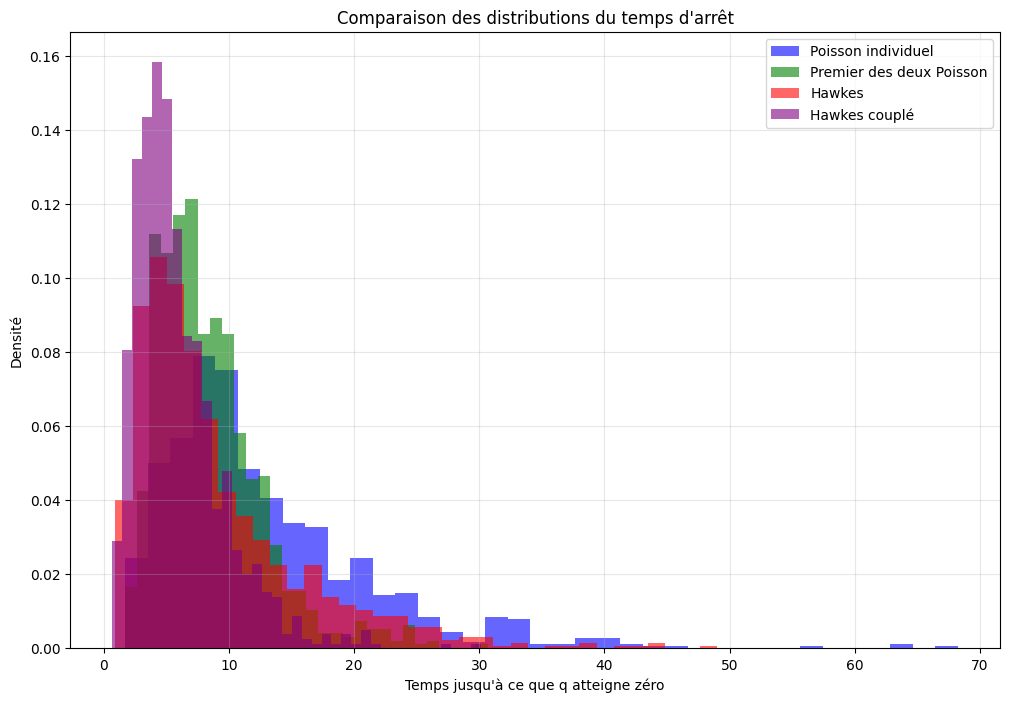

In [26]:
compare_stopping_time_distributions(mu_minus=2, alpha=0.5, beta=1, lambda_plus=LAMBDA_PLUS, q_0=Q_0, num_simulations=1000)

## 12. Distribution conditionnelle d'un processus auxiliaire $q_2$

On considère un troisième processus $q_2$ représentant un autre niveau du carnet, modélisé pour l'instant comme un processus de Poisson de paramètres $(\lambda^+_2, \lambda^-_2)$ simulé en parallèle des deux files Hawkes couplées. On étudie la **loi conditionnelle** de $q_2(\tau)$ sachant l'événement déclenchant $\tau$ :

- soit l'**ask** atteint 0 en premier ($\tau = \tau_a$),
- soit le **bid** atteint 0 en premier ($\tau = \tau_b$).

Cela permet d'estimer empiriquement la distribution de la profondeur restante au niveau adjacent au moment de l'épuisement d'un côté du meilleur niveau, donnée utile pour estimer le coût d'impact d'une exécution agressive.

In [27]:
def simulate_second_limit_distribution(mu_minus_a, mu_minus_b, alpha, beta,lambda_plus_2=LAMBDA_PLUS_2, lambda_minus_2=LAMBDA_MINUS_2, q_0_2=Q_0_2, lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS, q_0_a=Q_0_A, q_0_b=Q_0_B, num_desired=1000):
    count_ask = 0
    count_bid = 0
    q_2_given_ask = []
    times_2_given_ask = []
    q2_given_bid = []
    times_2_given_bid = []
    while count_ask < num_desired or count_bid < num_desired:
        times, times_a, times_b, q_a_values, q_b_values = simulated_coupled_hawkes_processes(mu_minus_a, mu_minus_b, alpha, beta, lambda_plus_a=lambda_plus_a, lambda_plus_b=lambda_plus_b, q_0_a=q_0_a, q_0_b=q_0_b)
        times_2, q_2_values = simulate_only_one_process(lambda_plus_2, lambda_minus_2, q_0_2, stopping_condition=lambda q,t: t < times[-1])
        if q_a_values[-1] == 0:
            count_ask += 1
            q_2_given_ask.append(q_2_values[-1])
            times_2_given_ask.append(times[-1])
        else:
            count_bid += 1
            q2_given_bid.append(q_2_values[-1])
            times_2_given_bid.append(times[-1])
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.hist(q_2_given_ask, bins='auto', density=True, alpha=0.6, color='c', label='q_2 donné ask → 0')
    plt.xlabel("Valeur de q_2 à l'instant où ask atteint zéro")
    plt.ylabel('Densité')
    plt.title("Distribution de q_2 conditionnée à ask → 0")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.subplot(1, 2, 2)
    plt.hist(q2_given_bid, bins='auto', density=True, alpha=0.6, color='m', label='q_2 donné bid → 0')
    plt.xlabel("Valeur de q_2 à l'instant où bid atteint zéro")
    plt.ylabel('Densité')
    plt.title("Distribution de q_2 conditionnée à bid → 0")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

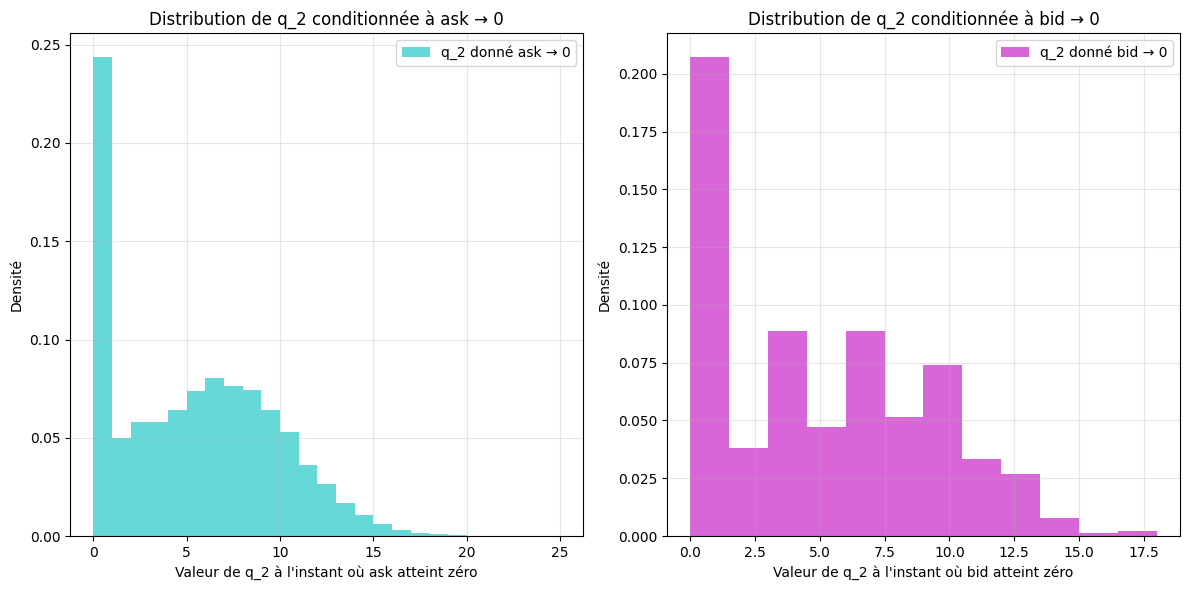

In [28]:
simulate_second_limit_distribution(mu_minus_a=2, mu_minus_b=1.2, alpha=0.5, beta=1, lambda_plus_2=LAMBDA_PLUS_2, lambda_minus_2=LAMBDA_MINUS_2, q_0_2=Q_0_2, lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS, q_0_a=Q_0_A, q_0_b=Q_0_B, num_desired=1000)

## 13. Intensité de $q_2$ excitée par les décréments de l'ask

On raffine le modèle précédent en couplant l'intensité $\lambda^+_2$ du processus auxiliaire au flux d'**événements décrémentant l'ask** : chaque baisse de l'ask augmente instantanément $\lambda^+_2$ d'un saut $a$, qui décroît ensuite exponentiellement au taux $b$. Cela traduit l'idée qu'une consommation rapide d'un niveau d'ask accroît la probabilité d'apparition de nouveaux ordres au niveau adjacent.

$$\lambda^+_2(t) = \mu^+_2 + \sum_{T_i^{\downarrow,a} < t} a\, e^{-b(t - T_i^{\downarrow,a})}.$$

La simulation utilise à nouveau un thinning d'Ogata, en majorant $\lambda^+_2$ par $\mu^+_2 + a \times (\text{nombre total de baisses d'ask sur le run de référence})$ et en filtrant par la valeur effective au candidat. On compare ensuite la distribution conditionnelle obtenue à celle du modèle à intensité constante.

In [29]:
def lambda_plus_ask_2(t, times_ask_decr, a , b, mu_plus_ask_2):
    lambda_plus_2_t = mu_plus_ask_2
    for t_i in times_ask_decr:
        if t_i < t:
            lambda_plus_2_t += a * np.exp(-b * (t - t_i))
    return lambda_plus_2_t

def simulate_only_one_process_with_varying_intensity(jump_times, a,lambda_plus_func, lambda_minus, q_0=Q_0_2, stopping_condition=lambda q,t: t > T):
    q = q_0
    t = 0
    times = [t]
    q_values = [q]
    lambda_bar_plus = lambda_plus_func(0) + a*len(jump_times)
    total_rate = lambda_bar_plus + lambda_minus
    while stopping_condition(q, t):
        lambda_plus_t = lambda_plus_func(t)
        time_to_next_event = np.random.exponential(1 / total_rate)
        t += time_to_next_event
        U = np.random.rand()
        if U < lambda_plus_t / total_rate:
            q += 1
            q = max(q, 0)
            times.append(t)
            q_values.append(q)
        else :
            if U < (lambda_plus_t + lambda_minus) / total_rate:
                q -= 1
                q = max(q, 0)
                times.append(t)
                q_values.append(q)
    return times, q_values

def simulate_second_limit_with_time_varying_lambda(mu_minus_a, mu_minus_b, alpha, beta, a, b, mu_plus_ask_2, lambda_minus_2, q_0_2=Q_0_2, lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS, q_0_a=Q_0_A, q_0_b=Q_0_B, num_desired=1000):
    count_ask = 0
    count_bid = 0
    q_2_given_ask = []
    times_2_given_ask = []
    q2_given_bid = []
    times_2_given_bid = []
    while count_ask < num_desired or count_bid < num_desired:
        times, times_a, times_b, q_a_values, q_b_values = simulated_coupled_hawkes_processes(mu_minus_a, mu_minus_b, alpha, beta, lambda_plus_a=lambda_plus_a, lambda_plus_b=lambda_plus_b, q_0_a=q_0_a, q_0_b=q_0_b)
        times_ask_decr = [times_a[i] for i in range(1,len(times_a)) if q_a_values[i] < q_a_values[i-1]]
        def time_varying_lambda(t):
            return lambda_plus_ask_2(t, times_ask_decr, a , b, mu_plus_ask_2)
        times_2, q_2_values = simulate_only_one_process_with_varying_intensity(times_ask_decr, a, time_varying_lambda, lambda_minus_2, q_0_2, stopping_condition=lambda q,t: t < times[-1])
        if q_a_values[-1] == 0:
            count_ask += 1
            q_2_given_ask.append(q_2_values[-1])
            times_2_given_ask.append(times[-1])
        else:
            count_bid += 1
            q2_given_bid.append(q_2_values[-1])
            times_2_given_bid.append(times[-1])
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.hist(q_2_given_ask, bins='auto', density=True, alpha=0.6, color='c', label='q_2 donné ask → 0')
    plt.xlabel("Valeur de q_2 à l'instant où ask atteint zéro")
    plt.ylabel('Densité')
    plt.title("Distribution de q_2 conditionnée à ask → 0")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.subplot(1, 2, 2)
    plt.hist(q2_given_bid, bins='auto', density=True, alpha=0.6, color='m', label='q_2 donné bid → 0')
    plt.xlabel("Valeur de q_2 à l'instant où bid atteint zéro")
    plt.ylabel('Densité')
    plt.title("Distribution de q_2 conditionnée à bid → 0")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    

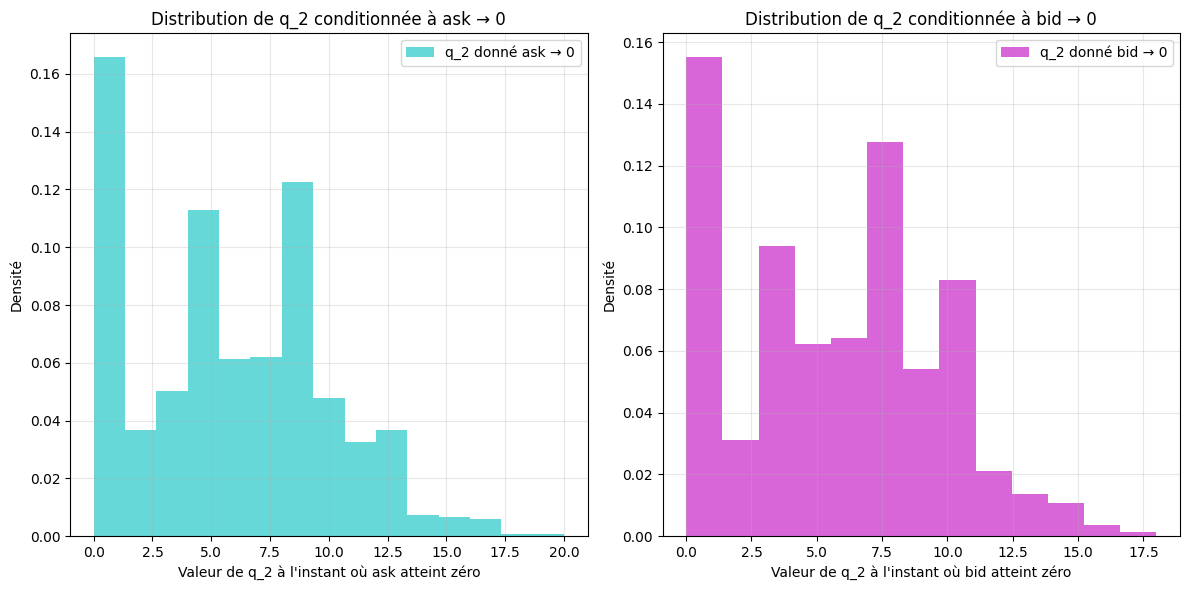

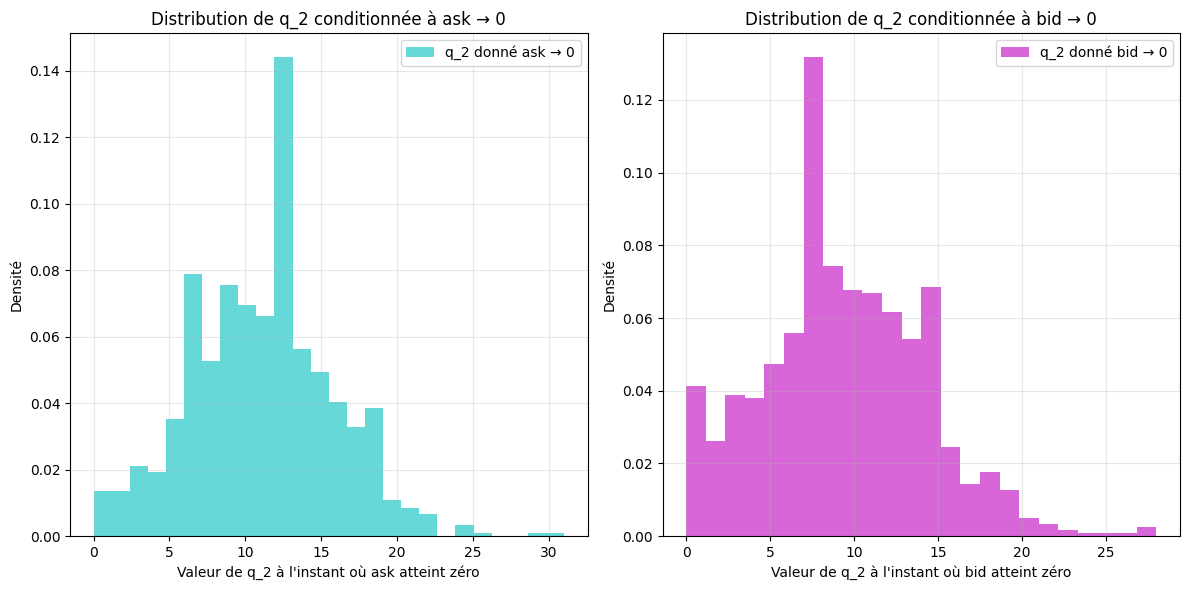

In [30]:
simulate_second_limit_distribution(mu_minus_a=2, mu_minus_b=2, alpha=0.5, beta=1, lambda_plus_2=LAMBDA_PLUS_2, lambda_minus_2=LAMBDA_MINUS_2, q_0_2=Q_0_2, lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS, q_0_a=Q_0_A, q_0_b=Q_0_B, num_desired=1000)
simulate_second_limit_with_time_varying_lambda(mu_minus_a=2, mu_minus_b=2, alpha=0.5, beta=1, a=0.5, b=1, mu_plus_ask_2=LAMBDA_PLUS_2, lambda_minus_2=LAMBDA_MINUS_2, q_0_2=Q_0_2, lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS, q_0_a=Q_0_A, q_0_b=Q_0_B, num_desired=1000)

## 14. Passage au prix

Nous construisons maintenant la **trajectoire du mid-price** en modélisant simultanément
les **deux premières limites** (Hawkes couplé) et les **deux deuxièmes limites**
(Poisson à intensité variable) du carnet d'ordres.

### Architecture du modèle à quatre limites

On maintient à tout instant quatre files :
- $q_{a,1}$ : première limite ask (la plus proche du mid-price côté vendeur)
- $q_{a,2}$ : deuxième limite ask
- $q_{b,1}$ : première limite bid (la plus proche du mid-price côté acheteur)
- $q_{b,2}$ : deuxième limite bid

Toutes initialisées à $q_0$.

### Dynamique des premières limites : Hawkes couplé

Les files $q_{a,1}$ et $q_{b,1}$ évoluent selon le **processus de Hawkes couplé** de la
section 10 : les décréments de l'ask excitent la dynamique du bid (et vice versa).
La simulation s'arrête dès que l'une des deux atteint zéro.

**Continuité des intensités entre cycles** : lors du passage au cycle suivant, les
valeurs finales $\lambda_a^\tau$ et $\lambda_b^\tau$ servent d'intensités initiales pour
le nouveau cycle Hawkes, préservant ainsi la mémoire du processus.

### Dynamique des deuxièmes limites : Poisson à intensité variable

Pendant le même intervalle $[0,\tau]$, les files $q_{a,2}$ et $q_{b,2}$ évoluent comme
des **processus de Poisson à intensité variable** (section 13), dont l'intensité est
excitée par les décréments de la première limite correspondante via un noyau exponentiel.

### Mécanique du saut de prix

Lorsque la première limite ask $q_{a,1}$ s'épuise :
$$q_{a,1} \leftarrow q_{a,2}, \quad q_{a,2} \leftarrow q_0, \quad p_0 \uparrow \tfrac{\delta^p}{2}$$

Symétriquement, si c'est $q_{b,1}$ qui s'épuise :
$$q_{b,1} \leftarrow q_{b,2}, \quad q_{b,2} \leftarrow q_0, \quad p_0 \downarrow \tfrac{\delta^p}{2}$$

La côte survivante conserve son niveau courant et continue dans le cycle suivant.


In [31]:
# (import numba défini en cellule 2)

# ── Noyau JIT : thinning Ogata pour les processus de Hawkes couplés ──────────
@_njit
def _hawkes_loop(mu_a, mu_b, alpha, beta, lp_a, lp_b, q_a, q_b, la0, lb0):
    """Simulation de (q_a, q_b) jusqu'au premier épuisement. Numba-accéléré."""
    MAX = 100000
    ta = np.empty(MAX); qa = np.empty(MAX, dtype=np.int64)
    tb = np.empty(MAX); qb = np.empty(MAX, dtype=np.int64)
    na = nb = 1
    ta[0] = 0.; qa[0] = q_a; tb[0] = 0.; qb[0] = q_b
    t = tla = tlb = 0.
    la = la0; lb = lb0
    while q_a > 0 and q_b > 0:
        ba = la if la > mu_a else mu_a
        bb = lb if lb > mu_b else mu_b
        sup = ba + bb + lp_a + lp_b
        tp = t + np.random.exponential(1. / sup)
        pa = mu_a + (la - mu_a) * np.exp(-beta * (tp - tla))
        pb = mu_b + (lb - mu_b) * np.exp(-beta * (tp - tlb))
        ea = pa if pa > 0. else 0.
        eb = pb if pb > 0. else 0.
        u = np.random.random()
        if u < lp_a / sup:
            q_a += 1; t = tp; tla = t; la = pa - alpha; lb = pb + alpha
            ta[na] = t; qa[na] = q_a; na += 1
        elif u < (ea + lp_a) / sup:
            q_a -= 1; t = tp; tla = t; la = pa + alpha; lb = pb - alpha
            ta[na] = t; qa[na] = q_a; na += 1
        elif u < (ba + lp_a) / sup:
            la = pa; lb = pb; tla = tp; t = tp
        elif u < (ba + lp_a + lp_b) / sup:
            q_b += 1; t = tp; tlb = t; lb = pb - alpha; la = pa + alpha
            tb[nb] = t; qb[nb] = q_b; nb += 1
        elif u < (ba + lp_a + eb + lp_b) / sup:
            q_b -= 1; t = tp; tlb = t; lb = pb + alpha; la = pa - alpha
            tb[nb] = t; qb[nb] = q_b; nb += 1
        else:
            la = pa; lb = pb; tla = tp; t = tp
    tau = ta[na-1] if ta[na-1] > tb[nb-1] else tb[nb-1]
    return ta[:na], qa[:na], tb[:nb], qb[:nb], la, lb, tau


# ── Noyau JIT : file secondaire avec intensité variant dans le temps ──────────
@_njit
def _second_limit(decr_times, a, b, mu_p, lm, q0, tau):
    """Poisson à intensité variable pour la file de second niveau. Numba-accéléré."""
    MAX = 50000
    ot = np.empty(MAX); oq = np.empty(MAX, dtype=np.int64)
    n = 1; ot[0] = 0.; oq[0] = q0
    q = q0; t = 0.
    nd = len(decr_times)
    rate = mu_p + a * nd + lm
    while t < tau:
        t += np.random.exponential(1. / rate)
        if t >= tau:
            break
        lp = mu_p
        for i in range(nd):
            if decr_times[i] < t:
                lp += a * np.exp(-b * (t - decr_times[i]))
        u = np.random.random()
        if u < lp / rate:
            q += 1
            ot[n] = t; oq[n] = q; n += 1
        elif u < (lp + lm) / rate:
            q -= 1
            if q < 0: q = 0
            ot[n] = t; oq[n] = q; n += 1
    return ot[:n], oq[:n]


# Compilation JIT au chargement
_hawkes_loop(2., 2., .5, 1., 1.2, 1.2, 5, 5, 2., 2.)
_second_limit(np.array([0.5, 1.0]), 0.8, 1.0, 1.2, 2.0, 5, 5.0)
print('_hawkes_loop et _second_limit compilés.')


# ── Wrapper (signature rétro-compatible) ─────────────────────────────────────
def simulate_coupled_hawkes_with_intensities(
        mu_minus_a, mu_minus_b, alpha, beta,
        lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
        q_0_a=Q_0_A, q_0_b=Q_0_B,
        lambda_a_0=None, lambda_b_0=None):
    ta, qa, tb, qb, la_f, lb_f, tau = _hawkes_loop(
        float(mu_minus_a), float(mu_minus_b), float(alpha), float(beta),
        float(lambda_plus_a), float(lambda_plus_b),
        int(q_0_a), int(q_0_b),
        float(lambda_a_0 if lambda_a_0 is not None else mu_minus_a),
        float(lambda_b_0 if lambda_b_0 is not None else mu_minus_b))
    merged = np.union1d(ta, tb)
    return (merged.tolist(), ta.tolist(), tb.tolist(),
            qa.tolist(), qb.tolist(), la_f, lb_f)
# ── Main price simulation ─────────────────────────────────────────────────────
def simulate_price_process_v2(n_cycles, mu_minus_a, mu_minus_b, alpha, beta,
                               a, b,
                               lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                               mu_plus_2=LAMBDA_PLUS_2, lambda_minus_2=LAMBDA_MINUS_2,
                               q_0_a=Q_0_A, q_0_b=Q_0_B, q_0_2=Q_0_2, delta_p=1.0):
    mid_price = 0.0; t_cumul = 0.0
    price_times = [0.0]; price_values = [mid_price]
    q_a1, q_b1 = int(q_0_a), int(q_0_b)
    la0, lb0 = float(mu_minus_a), float(mu_minus_b)

    fa, fb, a_, b_ = float(a), float(b), float(mu_plus_2), float(lambda_minus_2)

    for _ in range(n_cycles):
        ta, qa, tb, qb, la_f, lb_f, tau = _hawkes_loop(
            float(mu_minus_a), float(mu_minus_b), float(alpha), float(beta),
            float(lambda_plus_a), float(lambda_plus_b), q_a1, q_b1, la0, lb0)

        # Decrement times as contiguous float64 arrays for _second_limit
        ask_decr = ta[1:][qa[1:] < qa[:-1]]
        bid_decr = tb[1:][qb[1:] < qb[:-1]]

        _, q2a = _second_limit(ask_decr, fa, fb, a_, b_, int(q_0_2), tau)
        _, q2b = _second_limit(bid_decr, fa, fb, a_, b_, int(q_0_2), tau)

        t_cumul += tau
        q_a2 = max(1, int(q2a[-1]))
        q_b2 = max(1, int(q2b[-1]))

        if int(qa[-1]) == 0:           # ask exhausted -> price up
            mid_price += delta_p / 2
            q_a1 = q_a2
            q_b1 = max(1, int(qb[-1]))
        else:                           # bid exhausted -> price down
            mid_price -= delta_p / 2
            q_b1 = q_b2
            q_a1 = max(1, int(qa[-1]))

        la0 = la_f; lb0 = lb_f
        price_times.append(t_cumul)
        price_values.append(mid_price)

    return price_times, price_values


def plot_price_path(price_times, price_values, title='Trajectoire du mid-price'):
    plt.figure(figsize=(12, 4))
    plt.step(price_times, price_values, where='post', color='steelblue', linewidth=1.5)
    plt.xlabel('Temps')
    plt.ylabel('Mid-price $p_0$')
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def analyze_price_increments_v2(n_simulations, mu_minus_a, mu_minus_b, alpha, beta,
                                 lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                                 q_0_a=Q_0_A, q_0_b=Q_0_B, delta_p=1.0):
    up_moves = 0
    for _ in range(n_simulations):
        _, _, _, q_a_values, _ = simulated_coupled_hawkes_processes(
            mu_minus_a, mu_minus_b, alpha, beta, lambda_plus_a, lambda_plus_b, q_0_a, q_0_b)
        if q_a_values[-1] == 0:
            up_moves += 1
    p_up = up_moves / n_simulations
    p_down = 1 - p_up
    drift = delta_p / 2 * (p_up - p_down)
    print(f'P(hausse) = P(\u03c4_a < \u03c4_b) \u2248 {p_up:.3f}')
    print(f'P(baisse) = P(\u03c4_b < \u03c4_a) \u2248 {p_down:.3f}')
    print(f'D\u00e9rive par cycle : {drift:+.4f}')
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(['Hausse (+\u03b4/2)', 'Baisse (\u2212\u03b4/2)'], [p_up, p_down],
           color=['forestgreen', 'crimson'], alpha=0.75, edgecolor='black')
    ax.axhline(0.5, color='black', linestyle='--', linewidth=1.2, label='p = 0.5 (martingale)')
    ax.set_ylim(0, 1)
    ax.set_ylabel('Probabilit\u00e9 estim\u00e9e')
    ax.set_title('Distribution des incr\u00e9ments de prix')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return p_up


def long_run_price_distribution_v2(n_paths, n_cycles, mu_minus_a, mu_minus_b, alpha, beta,
                                    a, b,
                                    lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                                    mu_plus_2=LAMBDA_PLUS_2, lambda_minus_2=LAMBDA_MINUS_2,
                                    q_0_a=Q_0_A, q_0_b=Q_0_B, q_0_2=Q_0_2, delta_p=1.0):
    terminal_prices = np.array([
        simulate_price_process_v2(
            n_cycles, mu_minus_a, mu_minus_b, alpha, beta, a, b,
            lambda_plus_a, lambda_plus_b, mu_plus_2, lambda_minus_2,
            q_0_a, q_0_b, q_0_2, delta_p)[1][-1]
        for _ in range(n_paths)
    ])
    plt.figure(figsize=(8, 5))
    plt.hist(terminal_prices, bins='auto', density=True, alpha=0.65,
             color='steelblue', label=f'Prix final ({n_paths} trajectoires)')
    plt.xlabel('Prix final $p_0$')
    plt.ylabel('Densit\u00e9')
    plt.title(f'Distribution du prix apr\u00e8s {n_cycles} cycles ({n_paths} trajectoires)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return terminal_prices


_hawkes_loop et _second_limit compilés.


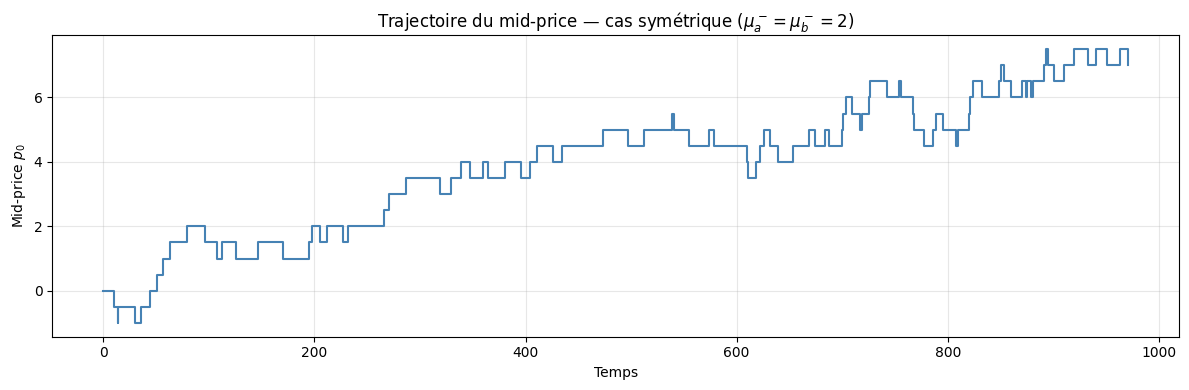

P(hausse) = P(τ_a < τ_b) ≈ 0.488
P(baisse) = P(τ_b < τ_a) ≈ 0.512
Dérive par cycle : -0.0120


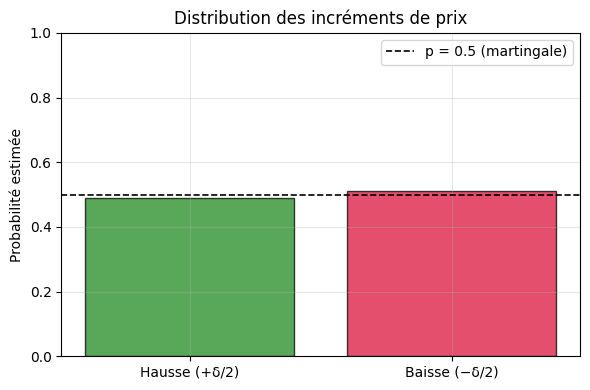

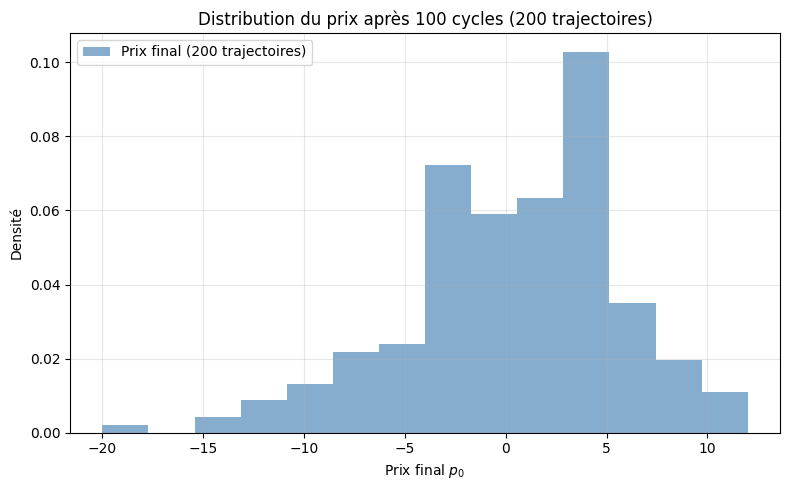

In [32]:
# Cas symétrique : mu_a^- = mu_b^-  →  martingale (p ≈ 0.5)
price_times_sym, price_values_sym = simulate_price_process_v2(
    n_cycles=100, mu_minus_a=2, mu_minus_b=2, alpha=0.5, beta=1, a=0.8, b=1.0)
plot_price_path(price_times_sym, price_values_sym,
                title='Trajectoire du mid-price — cas sym\u00e9trique ($\\mu_a^- = \\mu_b^- = 2$)')

p_up_sym = analyze_price_increments_v2(
    n_simulations=2000, mu_minus_a=2, mu_minus_b=2, alpha=0.5, beta=1)

values = long_run_price_distribution_v2(
    n_paths=200, n_cycles=100,
    mu_minus_a=2, mu_minus_b=2, alpha=0.5, beta=1, a=0.8, b=1.0)


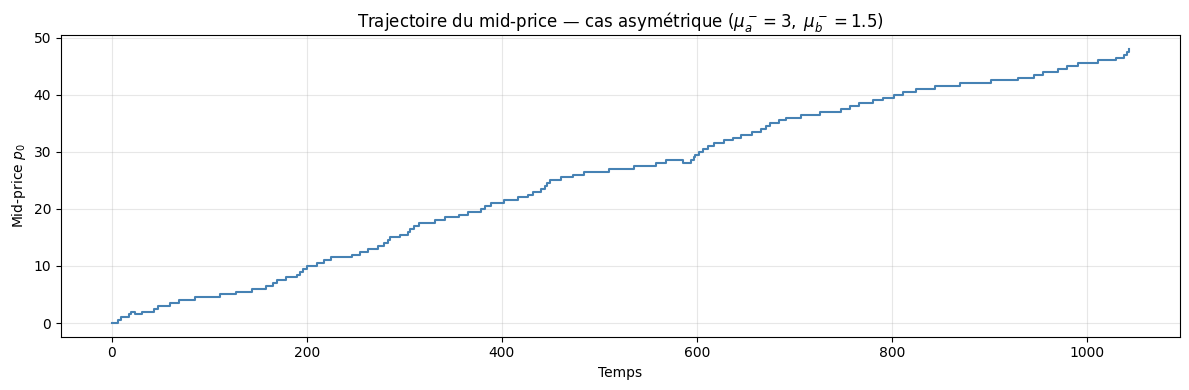

P(hausse) = P(τ_a < τ_b) ≈ 0.931
P(baisse) = P(τ_b < τ_a) ≈ 0.069
Dérive par cycle : +0.4315


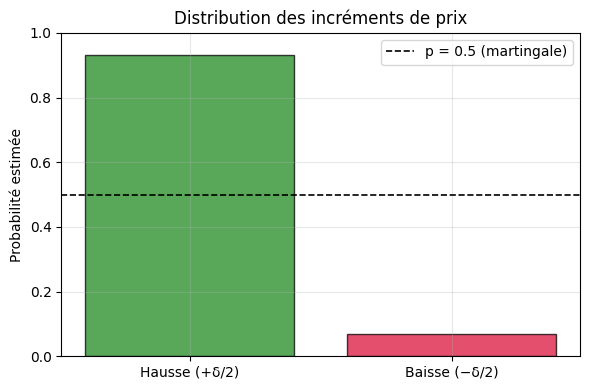

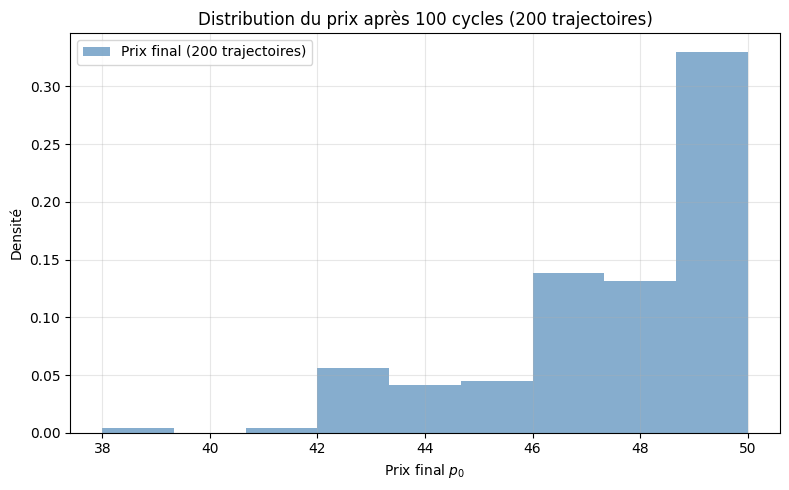

In [33]:
# Cas asymétrique : mu_a^- > mu_b^-  →  pression vendeuse accrue, dérive positive du prix
price_times_asym, price_values_asym = simulate_price_process_v2(
    n_cycles=100, mu_minus_a=3, mu_minus_b=1.5, alpha=0.5, beta=1, a=0.8, b=1.0)
plot_price_path(price_times_asym, price_values_asym,
                title='Trajectoire du mid-price — cas asym\u00e9trique ($\\mu_a^- = 3,\\; \\mu_b^- = 1.5$)')

p_up_asym = analyze_price_increments_v2(
    n_simulations=2000, mu_minus_a=3, mu_minus_b=1.5, alpha=0.5, beta=1)

values = long_run_price_distribution_v2(
    n_paths=200, n_cycles=100,
    mu_minus_a=3, mu_minus_b=1.5, alpha=0.5, beta=1, a=0.8, b=1.0)


In [34]:
import matplotlib.gridspec as gridspec

EPS_T = 1e-10  # tiny offset so queue-shift jumps appear cleanly in step plots


def simulate_order_book_evolution(n_cycles, mu_minus_a, mu_minus_b, alpha, beta,
                                   a, b,
                                   lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                                   mu_plus_2=LAMBDA_PLUS_2, lambda_minus_2=LAMBDA_MINUS_2,
                                   q_0_a=Q_0_A, q_0_b=Q_0_B, q_0_2=Q_0_2, delta_p=1.0):
    """Run n_cycles and collect the full 4-queue state history for visualization."""
    mid_price = 0.0; t_cumul = 0.0
    q_a1, q_b1 = int(q_0_a), int(q_0_b)
    la0, lb0 = float(mu_minus_a), float(mu_minus_b)
    fa, fb, mp, lm = float(a), float(b), float(mu_plus_2), float(lambda_minus_2)

    price_times  = [0.0]; price_values  = [mid_price]
    q_a1_times   = [0.0]; q_a1_values   = [q_0_a]
    q_b1_times   = [0.0]; q_b1_values   = [q_0_b]
    q_a2_times   = [0.0]; q_a2_values   = [q_0_2]
    q_b2_times   = [0.0]; q_b2_values   = [q_0_2]
    price_change_times = []; price_change_dirs = []

    for _ in range(n_cycles):
        ta, qa, tb, qb, la_f, lb_f, tau = _hawkes_loop(
            float(mu_minus_a), float(mu_minus_b), float(alpha), float(beta),
            float(lambda_plus_a), float(lambda_plus_b), q_a1, q_b1, la0, lb0)

        ask_decr = ta[1:][qa[1:] < qa[:-1]]
        bid_decr = tb[1:][qb[1:] < qb[:-1]]

        t2_a, q2_a = _second_limit(ask_decr, fa, fb, mp, lm, int(q_0_2), tau)
        t2_b, q2_b = _second_limit(bid_decr, fa, fb, mp, lm, int(q_0_2), tau)

        # First-limit trajectories (global time)
        for j in range(1, len(ta)):
            q_a1_times.append(t_cumul + ta[j]); q_a1_values.append(int(qa[j]))
        for j in range(1, len(tb)):
            q_b1_times.append(t_cumul + tb[j]); q_b1_values.append(int(qb[j]))

        # Second-limit trajectories (global time)
        for j in range(1, len(t2_a)):
            q_a2_times.append(t_cumul + t2_a[j]); q_a2_values.append(int(q2_a[j]))
        for j in range(1, len(t2_b)):
            q_b2_times.append(t_cumul + t2_b[j]); q_b2_values.append(int(q2_b[j]))

        t_cumul += tau
        q_a2_fin = max(1, int(q2_a[-1])); q_b2_fin = max(1, int(q2_b[-1]))

        if int(qa[-1]) == 0:
            mid_price += delta_p / 2; price_change_dirs.append(+1)
            q_a1 = q_a2_fin; q_b1 = max(1, int(qb[-1]))
        else:
            mid_price -= delta_p / 2; price_change_dirs.append(-1)
            q_b1 = q_b2_fin; q_a1 = max(1, int(qa[-1]))

        price_change_times.append(t_cumul)
        price_times.append(t_cumul); price_values.append(mid_price)

        # Queue-shift jump (EPS_T offset for clean step-plot rendering)
        q_a1_times.append(t_cumul + EPS_T); q_a1_values.append(q_a1)
        q_b1_times.append(t_cumul + EPS_T); q_b1_values.append(q_b1)
        q_a2_times.append(t_cumul + EPS_T); q_a2_values.append(int(q_0_2))
        q_b2_times.append(t_cumul + EPS_T); q_b2_values.append(int(q_0_2))

        la0 = la_f; lb0 = lb_f

    return dict(
        price_times=np.array(price_times),   price_values=np.array(price_values),
        q_a1_times=np.array(q_a1_times),     q_a1_values=np.array(q_a1_values),
        q_b1_times=np.array(q_b1_times),     q_b1_values=np.array(q_b1_values),
        q_a2_times=np.array(q_a2_times),     q_a2_values=np.array(q_a2_values),
        q_b2_times=np.array(q_b2_times),     q_b2_values=np.array(q_b2_values),
        price_change_times=np.array(price_change_times),
        price_change_dirs=np.array(price_change_dirs),
    )


def plot_order_book_evolution(data, title_suffix='', figsize=(15, 9)):
    C_ASK1  = '#c0392b'
    C_ASK2  = '#f0a899'
    C_BID1  = '#1a5276'
    C_BID2  = '#7fb3d3'
    C_PRICE = '#1e8449'
    C_UP    = '#27ae60'
    C_DOWN  = '#c0392b'

    fig, (ax_p, ax_a, ax_b) = plt.subplots(
        3, 1, figsize=figsize, facecolor='white',
        gridspec_kw={'height_ratios': [2, 1.5, 1.5]},
        sharex=True, constrained_layout=True)

    t_max = float(data['price_times'][-1])

    # ── Panel 1 : mid-price ─────────────────────────────────────────────
    ax_p.step(data['price_times'], data['price_values'], where='post',
              color=C_PRICE, linewidth=2.2, zorder=3)
    ax_p.fill_between(data['price_times'], data['price_values'],
                      data['price_values'].min() - 0.5,
                      step='post', color=C_PRICE, alpha=0.08, zorder=1)
    for i, (t, d) in enumerate(zip(data['price_change_times'], data['price_change_dirs'])):
        p_after = data['price_values'][i + 1]
        ax_p.scatter([t], [p_after],
                     color=C_UP if d > 0 else C_DOWN,
                     marker='^' if d > 0 else 'v',
                     s=80, zorder=5, linewidths=0)
    ax_p.set_ylabel('Mid-price $p_0$', fontsize=11)
    ax_p.set_title(
        f'\u00c9volution du carnet d\'ordres \u2014 {title_suffix}',
        fontsize=13, fontweight='bold', pad=9)

    # ── Panel 2 : ask ─────────────────────────────────────────────────
    ax_a.step(data['q_a1_times'], data['q_a1_values'], where='post',
              color=C_ASK1, linewidth=1.8, label='$q_{a,1}$ — Hawkes couplé', zorder=3)
    ax_a.step(data['q_a2_times'], data['q_a2_values'], where='post',
              color=C_ASK2, linewidth=1.3, linestyle='--', alpha=0.90,
              label='$q_{a,2}$ — Poisson variable', zorder=2)
    ax_a.fill_between(data['q_a1_times'], data['q_a1_values'], 0,
                      step='post', color=C_ASK1, alpha=0.13, zorder=1)
    ax_a.set_ylabel('File ask', fontsize=11)
    ax_a.legend(loc='upper right', fontsize=9.5, framealpha=0.92,
                ncol=2, edgecolor='#cccccc')

    # ── Panel 3 : bid ─────────────────────────────────────────────────
    ax_b.step(data['q_b1_times'], data['q_b1_values'], where='post',
              color=C_BID1, linewidth=1.8, label='$q_{b,1}$ — Hawkes couplé', zorder=3)
    ax_b.step(data['q_b2_times'], data['q_b2_values'], where='post',
              color=C_BID2, linewidth=1.3, linestyle='--', alpha=0.90,
              label='$q_{b,2}$ — Poisson variable', zorder=2)
    ax_b.fill_between(data['q_b1_times'], data['q_b1_values'], 0,
                      step='post', color=C_BID1, alpha=0.13, zorder=1)
    ax_b.set_ylabel('File bid', fontsize=11)
    ax_b.set_xlabel('Temps', fontsize=11)
    ax_b.legend(loc='upper right', fontsize=9.5, framealpha=0.92,
                ncol=2, edgecolor='#cccccc')

    # ── Shared decorations ──────────────────────────────────────────────
    for ax in (ax_p, ax_a, ax_b):
        for t, d in zip(data['price_change_times'], data['price_change_dirs']):
            ax.axvline(t, color=C_UP if d > 0 else C_DOWN,
                       alpha=0.18, linewidth=0.9, zorder=0)
        ax.set_xlim(0, t_max)
        ax.grid(True, alpha=0.30, linewidth=0.6, linestyle=':')
        ax.set_facecolor('#fafafa')
        for sp in ax.spines.values():
            sp.set_linewidth(0.7); sp.set_color('#cccccc')

    plt.setp(ax_p.get_xticklabels(), visible=False)
    plt.setp(ax_a.get_xticklabels(), visible=False)
    plt.show()


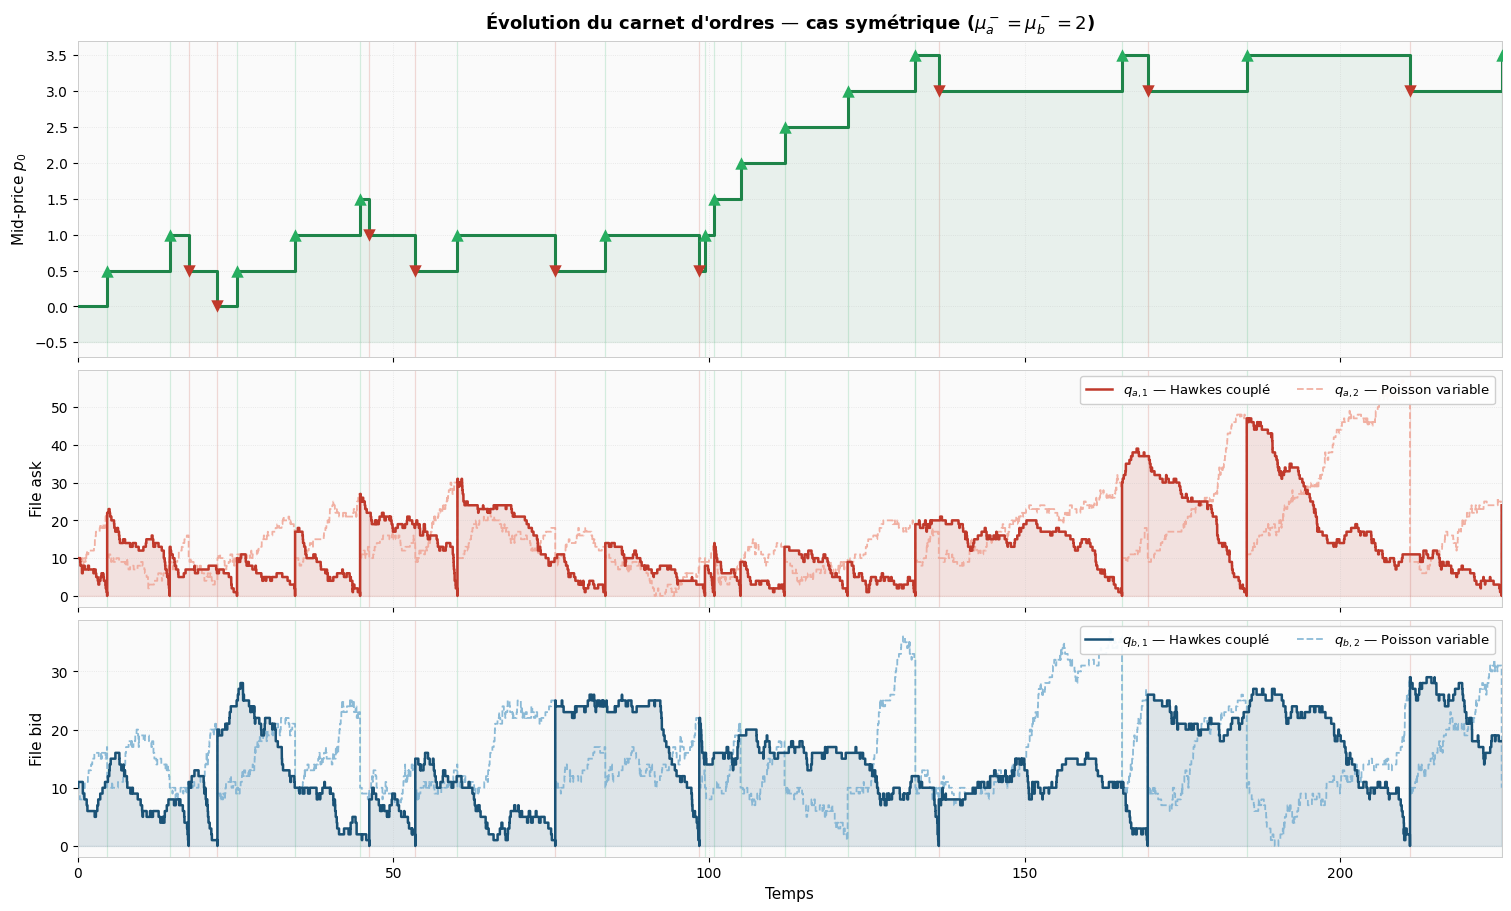

In [35]:
# Cas symétrique — visualisation de l'état du carnet d'ordres (25 cycles)
data_sym = simulate_order_book_evolution(
    n_cycles=25, mu_minus_a=2, mu_minus_b=2, alpha=0.5, beta=1, a=0.8, b=1.0)
plot_order_book_evolution(
    data_sym,
    title_suffix='cas sym\u00e9trique ($\\mu_a^- = \\mu_b^- = 2$)')


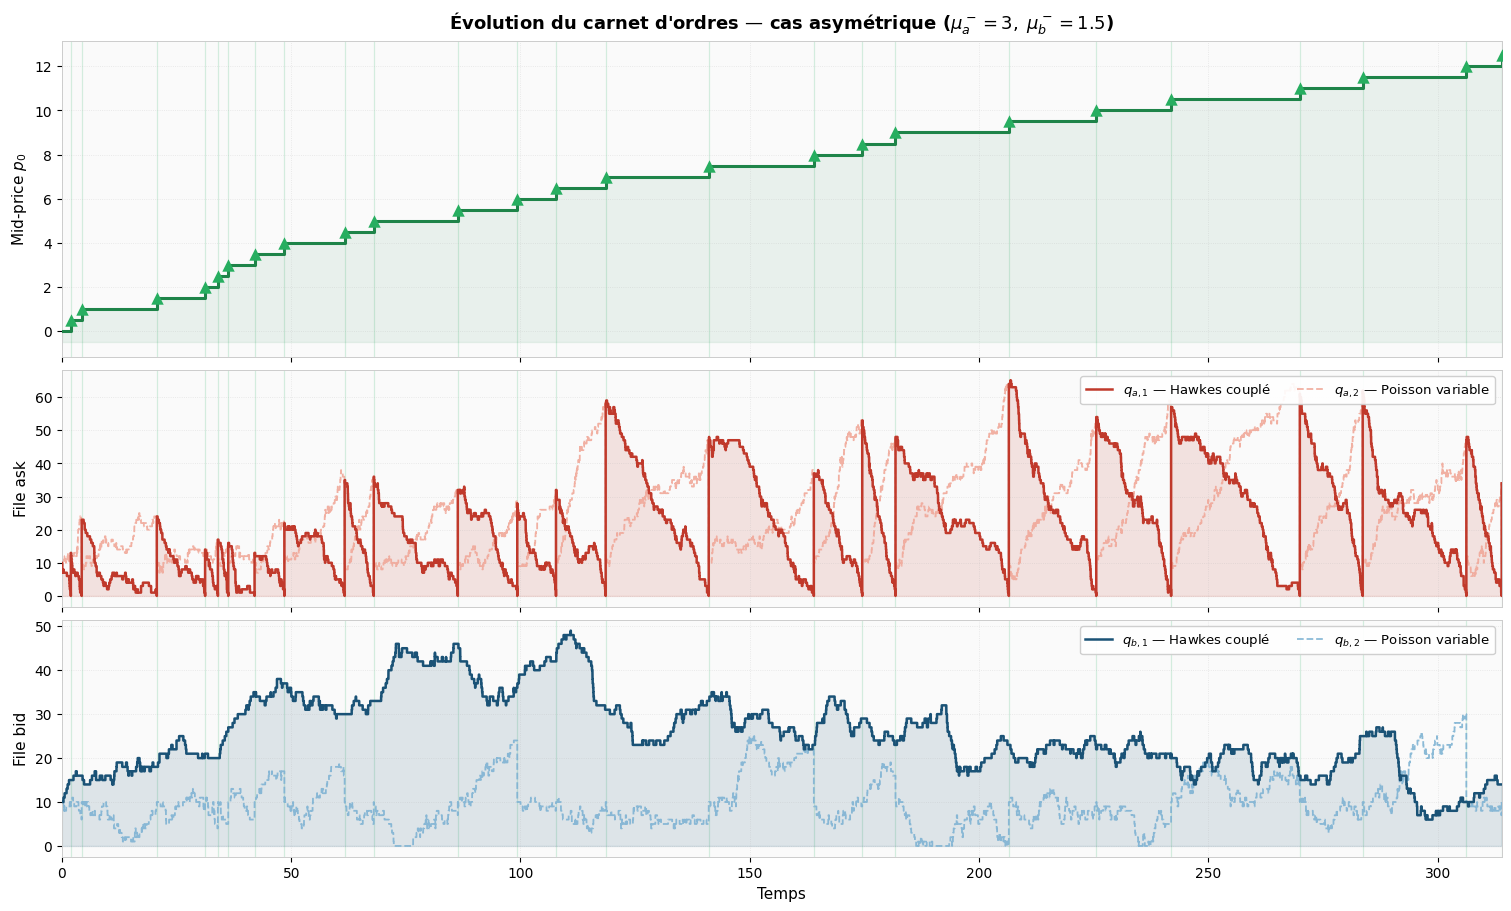

In [36]:
# Cas asymétrique — visualisation de l'état du carnet d'ordres (25 cycles)
data_asym = simulate_order_book_evolution(
    n_cycles=25, mu_minus_a=3, mu_minus_b=1.5, alpha=0.5, beta=1, a=0.8, b=1.0)
plot_order_book_evolution(
    data_asym,
    title_suffix='cas asym\u00e9trique ($\\mu_a^- = 3, \\; \\mu_b^- = 1.5$)')


## 15. Splitting pour la distribution conditionnelle de $Q_{a,2}$

### Problème et motivation

Dans la section 12, la distribution de $Q_{a,2}(\tau_a)$ conditionnellement à $\tau_a < \tau_b$
est estimée par **Monte Carlo direct** : on simule $N$ trajectoires Hawkes couplées et on
conserve celles où l'ask s'épuise en premier. Lorsque $p = \mathbb{P}(\tau_a < \tau_b) \ll 1$
(cas asymétrique $\mu_a^- \gg \mu_b^-$), seulement une fraction $p$ des trajectoires
contribuent : la variance de l'estimateur est $\propto (1-p)/(Np)$, ce qui diverge quand
$p \to 0$.

### Idée intuitive

Les trajectoires dont $q_{a,1}$ est déjà **proche de zéro** ont beaucoup plus de chances
d'atteindre l'épuisement $q_{a,1} = 0$. L'algorithme de **splitting multiniveau** exploite
cette observation : dès qu'une particule franchit un palier intermédiaire, on la
**clone** pour concentrer la simulation sur les trajectoires prometteuses.

### Algorithme formel (AMS à $N$ particules fixe)

**Niveaux** : on définit $Q_0$ paliers successifs
$$\mathcal{A}_k = \{q_{a,1} \leq k\}, \quad k = Q_0-1,\, Q_0-2,\, \ldots,\, 0.$$
Atteindre $\mathcal{A}_0 = \{q_{a,1} = 0\}$ est l'événement rare cible.

**Itération** : pour $k = Q_0-1$ jusqu'à $0$ :

1. Chaque particule en état $(q_{a,1}, q_{b,1}, \lambda_a, \lambda_b, t, \ldots)$ est simulée
   par le **processus de Hawkes couplé** jusqu'à ce que $q_{a,1}$ atteigne $k$
   (**succès**) ou $q_{b,1} = 0$ (**échec** — la particule est éliminée).  
   Les décréments de $q_{a,1}$ accumulés servent à exciter $Q_{a,2}$.

2. Soit $n_k$ le nombre de succès parmi $N$ particules.  
   On enregistre $\hat{p}_k = n_k/N$ et on **ré-échantillonne** $N$ copies parmi les
   $n_k$ survivants (avec remise), en héritant de l'état Hawkes complet
   $(\lambda_a^{\rm fin}, \lambda_b^{\rm fin}, t^{\rm fin}, \ldots)$.

3. À la fin ($q_{a,1} = 0$, instant $\tau_a$) : simuler $Q_{a,2}$ par le processus de
   Poisson à intensité variable (section 13) en utilisant l'historique complet des
   décréments accumulés.

**Continuité des intensités Hawkes** : les intensités finales $\lambda_a^{\rm fin},
\lambda_b^{\rm fin}$ d'une sous-simulation servent d'intensités initiales pour la
suivante, garantissant la cohérence de la trajectoire Hawkes sur $[0, \tau_a]$.

**Estimateur de la probabilité de conditionnement** :
$$\hat{p} = \prod_{k=0}^{Q_0-1} \hat{p}_k = \prod_{k=0}^{Q_0-1} \frac{n_k}{N}
\;\approx\; \mathbb{P}(\tau_a < \tau_b).$$

### Gain de variance

Pour MC direct avec $N_{\rm MC}$ trajectoires, le nombre effectif d'échantillons
conditionnels est $N_{\rm MC}\cdot p$. Avec le splitting et $N_{\rm split}$ particules,
toutes les particules atteignent $q_{a,1} = 0$, donnant $N_{\rm split}$ échantillons
conditionnels. Le gain est d'un facteur $\approx N_{\rm split} / (N_{\rm MC} \cdot p)$,
qui croît quand $p \to 0$.


In [37]:
# ── Noyau JIT unifié : un seul passage de thinning, côté ask OU bid ──────────
@_njit
def _hawkes_one_level(mu_a, mu_b, alpha, beta, lp_a, lp_b,
                       q_a, q_b, la, lb, t, tla, tlb, target, watch_a):
    """
    Thinning d'Ogata jusqu'à ce que la file surveillée descende à `target`.

    watch_a = 1 → surveille q_a (côté ask) ; s'arrête quand q_a ≤ target ou q_b = 0.
    watch_a = 0 → surveille q_b (côté bid) ; s'arrête quand q_b ≤ target ou q_a = 0.

    Retourne (ta, qa, tb, qb, la_f, lb_f, t_f, tla_f, tlb_f, ok).
    """
    MAX = 50000           # taille max du buffer d'événements
    MAX_STEPS = 2000      # garde-fou : évite la boucle infinie (supercritique lp > mu)
    ta = np.empty(MAX); qa = np.empty(MAX, dtype=np.int64)
    tb = np.empty(MAX); qb = np.empty(MAX, dtype=np.int64)
    na = nb = 0; n_steps = 0
    while True:
        # Condition d'arrêt selon le côté surveillé
        if watch_a != 0:
            if not (q_a > target and q_b > 0): break
        else:
            if not (q_b > target and q_a > 0): break
        # Garde-fou anti-boucle infinie (régime supercritique : lp > mu)
        n_steps += 1
        if n_steps >= MAX_STEPS:
            break
        ba = la if la > mu_a else mu_a
        bb = lb if lb > mu_b else mu_b
        sup = ba + bb + lp_a + lp_b
        tp = t + np.random.exponential(1. / sup)
        pa = mu_a + (la - mu_a) * np.exp(-beta * (tp - tla))
        pb = mu_b + (lb - mu_b) * np.exp(-beta * (tp - tlb))
        ea = pa if pa > 0. else 0.
        eb = pb if pb > 0. else 0.
        u = np.random.random()
        if u < lp_a / sup:
            q_a += 1; t = tp; tla = t; la = pa - alpha; lb = pb + alpha
            if na < MAX: ta[na] = t; qa[na] = q_a
            na += 1
        elif u < (ea + lp_a) / sup:
            q_a -= 1; t = tp; tla = t; la = pa + alpha; lb = pb - alpha
            if na < MAX: ta[na] = t; qa[na] = q_a
            na += 1
        elif u < (ba + lp_a) / sup:
            la = pa; lb = pb; tla = tp; t = tp
        elif u < (ba + lp_a + lp_b) / sup:
            q_b += 1; t = tp; tlb = t; lb = pb - alpha; la = pa + alpha
            if nb < MAX: tb[nb] = t; qb[nb] = q_b
            nb += 1
        elif u < (ba + lp_a + eb + lp_b) / sup:
            q_b -= 1; t = tp; tlb = t; lb = pb + alpha; la = pa - alpha
            if nb < MAX: tb[nb] = t; qb[nb] = q_b
            nb += 1
        else:
            lb = pb; la = pa; tlb = tp; t = tp
    ok = (q_a <= target) if watch_a != 0 else (q_b <= target)
    na_ret = na if na <= MAX else MAX
    nb_ret = nb if nb <= MAX else MAX
    return ta[:na_ret], qa[:na_ret], tb[:nb_ret], qb[:nb_ret], la, lb, t, tla, tlb, ok


# Compilation JIT des deux variantes (ask et bid) au chargement
_hawkes_one_level(2., 2., .5, 1., 1.2, 1.2, 5, 5, 2., 2., 0., 0., 0., 4, 1)
_hawkes_one_level(2., 2., .5, 1., 1.2, 1.2, 5, 5, 2., 2., 0., 0., 0., 4, 0)
print('_hawkes_one_level (ask + bid) compilé.')


# ── Wrapper bid (rétro-compatibilité) ────────────────────────────────────────
def _hawkes_one_level_bid(mu_a, mu_b, alpha, beta, lp_a, lp_b,
                           q_a, q_b, la, lb, t, tla, tlb, target_b):
    """Appelle _hawkes_one_level avec watch_a=0 (surveillance du côté bid)."""
    return _hawkes_one_level(mu_a, mu_b, alpha, beta, lp_a, lp_b,
                             q_a, q_b, la, lb, t, tla, tlb, target_b, 0)


# ── Estimateur splitting (ask OU bid) ────────────────────────────────────────
def splitting_Q2_distribution(N_particles, mu_minus_a, mu_minus_b, alpha, beta,
                               a, b,
                               lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                               mu_plus_2=LAMBDA_PLUS_2, lambda_minus_2=LAMBDA_MINUS_2,
                               q_0_a=Q_0_A, q_0_b=Q_0_B, q_0_2=Q_0_2,
                               side='ask'):
    """
    Estimateur AMS multiniveau de P(τ_ask < τ_bid) [side='ask']
                                 ou P(τ_bid < τ_ask) [side='bid'].
    Retourne (q2_values, p_hat).
    """
    mu_a = float(mu_minus_a); mu_b = float(mu_minus_b)
    al = float(alpha);        be = float(beta)
    lpa = float(lambda_plus_a); lpb = float(lambda_plus_b)
    a_ = float(a); b_ = float(b); mp = float(mu_plus_2); lm = float(lambda_minus_2)
    wa = 1 if side == 'ask' else 0          # watch_a flag
    q0_watch = int(q_0_a) if wa else int(q_0_b)
    decr_key  = 'decr_a' if wa else 'decr_b'

    particles = [{'q_a': int(q_0_a), 'q_b': int(q_0_b),
                  'la': mu_a, 'lb': mu_b,
                  't': 0., 'tla': 0., 'tlb': 0.,
                  decr_key: []}
                 for _ in range(N_particles)]
    prob = 1.0

    for target in range(q0_watch - 1, -1, -1):
        survivors = []
        for p in particles:
            ta, qa, tb, qb, la_f, lb_f, t_f, tla_f, tlb_f, ok = _hawkes_one_level(
                mu_a, mu_b, al, be, lpa, lpb,
                p['q_a'], p['q_b'], p['la'], p['lb'],
                p['t'], p['tla'], p['tlb'], target, wa)
            if ok:
                # Identifier les temps de décrémentation de la file surveillée
                if wa:
                    prev = np.empty(len(qa), dtype=np.int64)
                    prev[0] = p['q_a']
                    if len(qa) > 1: prev[1:] = qa[:-1]
                    new_decr = ta[qa < prev].tolist()
                else:
                    prev = np.empty(len(qb), dtype=np.int64)
                    prev[0] = p['q_b']
                    if len(qb) > 1: prev[1:] = qb[:-1]
                    new_decr = tb[qb < prev].tolist()
                surv = {
                    'q_a': int(qa[-1]) if len(qa) else p['q_a'],
                    'q_b': int(qb[-1]) if len(qb) else p['q_b'],
                    'la': la_f, 'lb': lb_f,
                    't': t_f, 'tla': tla_f, 'tlb': tlb_f,
                    decr_key: p[decr_key] + new_decr}
                if wa: surv['q_a'] = int(qa[-1])
                else:  surv['q_b'] = int(qb[-1])
                survivors.append(surv)

        n_s = len(survivors)
        if n_s == 0: return [], 0.0
        prob *= n_s / N_particles
        idx = np.random.choice(n_s, size=N_particles, replace=True)
        particles = [dict(survivors[i]) for i in idx]

    # Simuler Q2 pour chaque particule survivante
    q2_values = []
    for p in particles:
        td = (np.array(p[decr_key], dtype=np.float64)
              if p[decr_key] else np.empty(0, dtype=np.float64))
        _, q2v = _second_limit(td, a_, b_, mp, lm, int(q_0_2), float(p['t']))
        q2_values.append(int(q2v[-1]))

    return q2_values, prob


# Alias rétro-compatibles
def splitting_Q2_bid_distribution(N_particles, mu_minus_a, mu_minus_b, alpha, beta,
                                   a, b,
                                   lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                                   mu_plus_2=LAMBDA_PLUS_2, lambda_minus_2=LAMBDA_MINUS_2,
                                   q_0_a=Q_0_A, q_0_b=Q_0_B, q_0_2=Q_0_2):
    """Wrapper bid de splitting_Q2_distribution (rétro-compatibilité)."""
    return splitting_Q2_distribution(
        N_particles, mu_minus_a, mu_minus_b, alpha, beta, a, b,
        lambda_plus_a, lambda_plus_b, mu_plus_2, lambda_minus_2,
        q_0_a, q_0_b, q_0_2, side='bid')


# ── Visualisation splitting vs MC (ask OU bid) ───────────────────────────────
def plot_splitting_vs_mc(mu_minus_a, mu_minus_b, alpha, beta, a, b,
                          N_split=300, N_mc=3000,
                          lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                          mu_plus_2=LAMBDA_PLUS_2, lambda_minus_2=LAMBDA_MINUS_2,
                          q_0_a=Q_0_A, q_0_b=Q_0_B, q_0_2=Q_0_2,
                          side='ask'):
    """
    Compare splitting AMS vs MC direct pour la distribution de Q2.
    side='ask' → cible τ_a < τ_b ;  side='bid' → cible τ_b < τ_a.
    """
    label_q2  = '$Q_{a,2}(\\tau_a)$' if side == 'ask' else '$Q_{b,2}(\\tau_b)$'
    wa = 1 if side == 'ask' else 0

    # ── Splitting ──────────────────────────────────────────────────────────
    q2_spl, p_spl = splitting_Q2_distribution(
        N_split, mu_minus_a, mu_minus_b, alpha, beta, a, b,
        lambda_plus_a, lambda_plus_b, mu_plus_2, lambda_minus_2,
        q_0_a, q_0_b, q_0_2, side=side)

    # ── MC direct ──────────────────────────────────────────────────────────
    q2_mc = []
    for _ in range(N_mc):
        ta, qa, tb, qb, _, _, tau = _hawkes_loop(
            float(mu_minus_a), float(mu_minus_b), float(alpha), float(beta),
            float(lambda_plus_a), float(lambda_plus_b),
            int(q_0_a), int(q_0_b), float(mu_minus_a), float(mu_minus_b))
        # succès = côté cible épuisé en premier
        success = (int(qa[-1]) == 0) if wa else (int(qb[-1]) == 0)
        if success:
            ev = ta[1:][qa[1:] < qa[:-1]] if wa and len(qa) > 1 else (
                 tb[1:][qb[1:] < qb[:-1]] if not wa and len(qb) > 1
                 else np.empty(0, dtype=np.float64))
            _, q2v = _second_limit(ev.astype(np.float64), float(a), float(b),
                                    float(mu_plus_2), float(lambda_minus_2),
                                    int(q_0_2), float(tau))
            q2_mc.append(int(q2v[-1]))
    p_mc = len(q2_mc) / N_mc

    print(f'[{side}] Splitting : p̂ = {p_spl:.3f} ({len(q2_spl)} éch.)'
          f'   MC direct : p̂ = {p_mc:.3f} ({len(q2_mc)}/{N_mc})')

    all_vals = q2_spl + q2_mc
    if not all_vals: print('Aucune donnée à afficher.'); return
    bins = np.arange(-0.5, max(all_vals) + 2.5, 1.0)

    col_mc  = '#2980b9' if side == 'ask' else '#1a5276'
    col_spl = '#e67e22' if side == 'ask' else '#117a65'
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white',
                              constrained_layout=True)
    axes[0].hist(q2_mc, bins=bins, density=True, alpha=0.78, color=col_mc,
                  edgecolor='white', linewidth=0.5,
                  label=f'MC  N={N_mc},  p̂={p_mc:.3f}  ({len(q2_mc)} succ.)')

    axes[0].set_title('Monte Carlo direct', fontsize=12, fontweight='bold')
    axes[0].set_xlabel(label_q2, fontsize=11); axes[0].set_ylabel('Densité', fontsize=11)
    axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3, linestyle=':')
    axes[0].set_facecolor('#fafafa')

    axes[1].hist(q2_spl, bins=bins, density=True, alpha=0.78, color=col_spl,
                  edgecolor='white', linewidth=0.5,
                  label=f'Splitting  N={N_split},  p̂={p_spl:.3f}')

    axes[1].set_title('Splitting multiniveau', fontsize=12, fontweight='bold')
    axes[1].set_xlabel(label_q2, fontsize=11); axes[1].set_ylabel('Densité', fontsize=11)
    axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3, linestyle=':')
    axes[1].set_facecolor('#fafafa')

    fig.suptitle(
        f'Distribution de $Q_{{2}}$ sachant $\tau_{{{side}}} < \tau_{{{"bid" if side=="ask" else "ask"}}}'
        f'$ — $\\mu_a^-={mu_minus_a},\\; \\mu_b^-={mu_minus_b}$',
        fontsize=12, fontweight='bold')
    plt.show()


# Alias rétro-compatible
def plot_splitting_vs_mc_bid(mu_minus_a, mu_minus_b, alpha, beta, a, b,
                              N_split=300, N_mc=3000,
                              lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                              mu_plus_2=LAMBDA_PLUS_2, lambda_minus_2=LAMBDA_MINUS_2,
                              q_0_a=Q_0_A, q_0_b=Q_0_B, q_0_2=Q_0_2):
    """Wrapper bid de plot_splitting_vs_mc (rétro-compatibilité)."""
    return plot_splitting_vs_mc(
        mu_minus_a, mu_minus_b, alpha, beta, a, b,
        N_split, N_mc, lambda_plus_a, lambda_plus_b,
        mu_plus_2, lambda_minus_2, q_0_a, q_0_b, q_0_2, side='bid')


print('Section 15 : fonctions splitting unifiées (ask + bid).')


_hawkes_one_level (ask + bid) compilé.
Section 15 : fonctions splitting unifiées (ask + bid).


[ask] Splitting : p̂ = 0.501 (30000 éch.)   MC direct : p̂ = 0.496 (49593/100000)


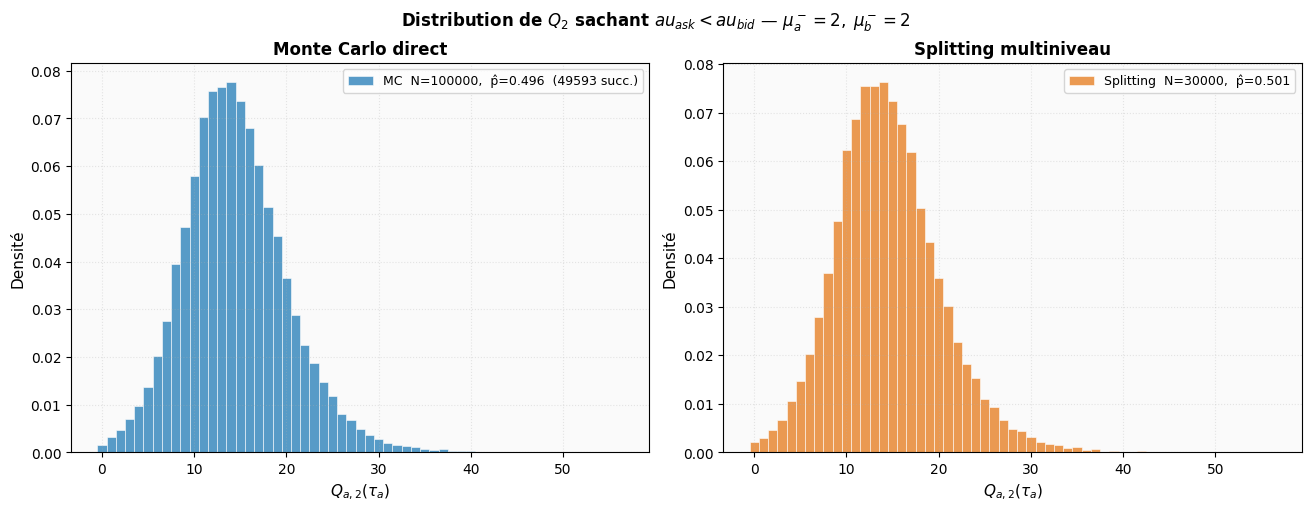

  Temps cas symétrique : 14.58s
[ask] Splitting : p̂ = 0.930 (30000 éch.)   MC direct : p̂ = 0.929 (92884/100000)


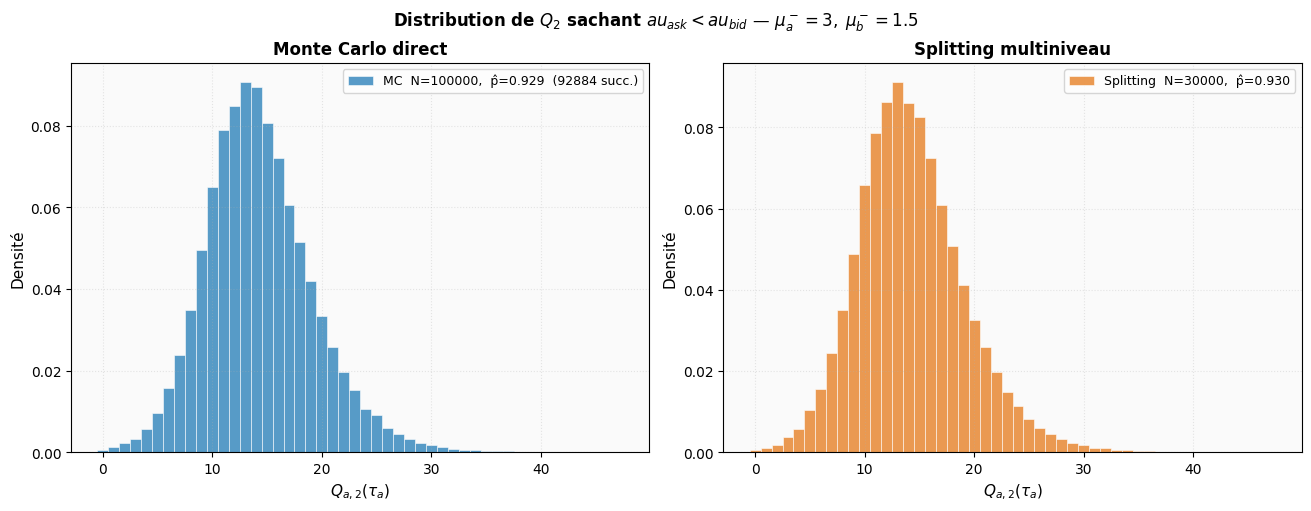

  Temps cas asymétrique : 13.09s

=== Cas bid : Q_{b,2} sachant tau_b < tau_a ===
[bid] Splitting : p̂ = 0.504 (30000 éch.)   MC direct : p̂ = 0.502 (50224/100000)


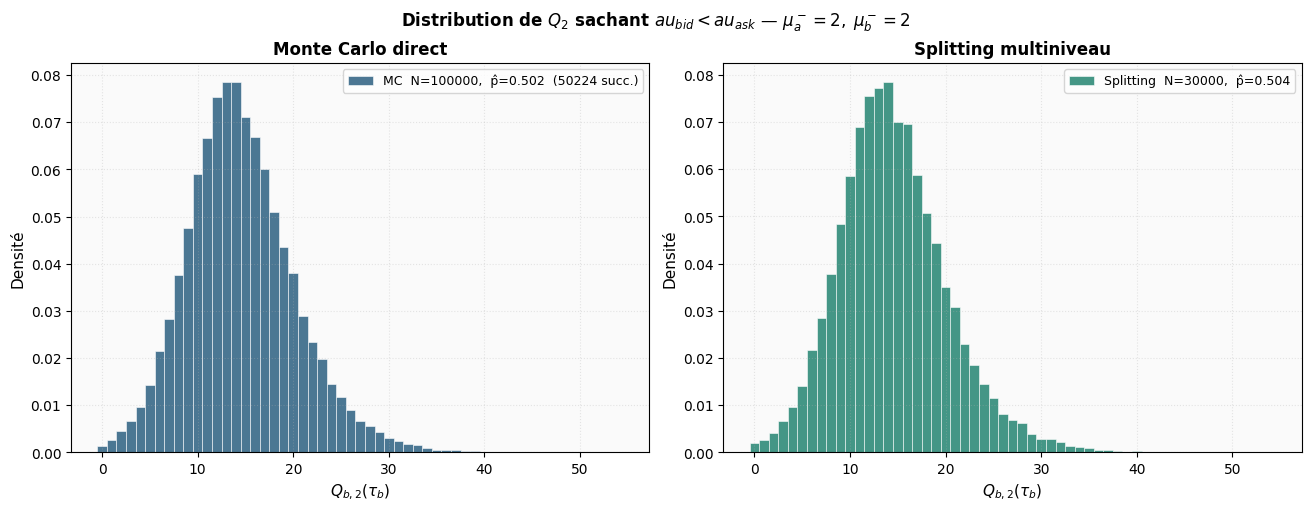

  Temps bid symétrique : 13.82s
[bid] Splitting : p̂ = 0.070 (30000 éch.)   MC direct : p̂ = 0.072 (7166/100000)


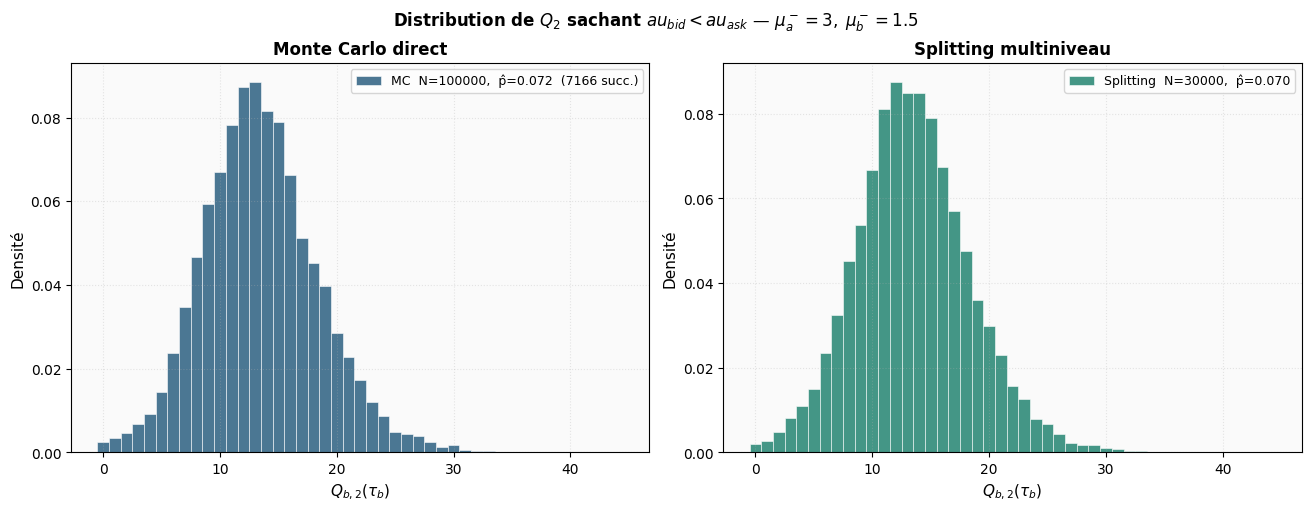

  Temps bid asymétrique : 9.90s


In [38]:
# Cas symétrique : p ≈ 0.5 — splitting et MC direct donnent des résultats similaires
t0 = _time.perf_counter()
plot_splitting_vs_mc(mu_minus_a=2, mu_minus_b=2, alpha=0.5, beta=1, a=0.8, b=1.0,
                      N_split=30_000, N_mc=100_000)
print(f'  Temps cas symétrique : {_time.perf_counter()-t0:.2f}s')

# Cas asymétrique : p < 0.5 — le splitting est plus efficace (moins de rejets)
t0 = _time.perf_counter()
plot_splitting_vs_mc(mu_minus_a=3, mu_minus_b=1.5, alpha=0.5, beta=1, a=0.8, b=1.0,
                      N_split=30_000, N_mc=100_000)
print(f'  Temps cas asymétrique : {_time.perf_counter()-t0:.2f}s')


print('\n=== Cas bid : Q_{b,2} sachant tau_b < tau_a ===')
# Cas symétrique
t0 = _time.perf_counter()
plot_splitting_vs_mc_bid(mu_minus_a=2, mu_minus_b=2, alpha=0.5, beta=1, a=0.8, b=1.0,
                          N_split=30_000, N_mc=100_000)
print(f'  Temps bid symétrique : {_time.perf_counter()-t0:.2f}s')

# Cas asymétrique : p > 0.5 pour le bid (mu_b < mu_a)
t0 = _time.perf_counter()
plot_splitting_vs_mc_bid(mu_minus_a=3, mu_minus_b=1.5, alpha=0.5, beta=1, a=0.8, b=1.0,
                          N_split=30_000, N_mc=100_000)
print(f'  Temps bid asymétrique : {_time.perf_counter()-t0:.2f}s')


## 16. Distribution des états aux niveaux de splitting

### Motivation

Dans l'algorithme de splitting (section 15), à chaque niveau $k$, seules les particules ayant survécu jusqu'à $\{q_{a,1} \leq k\}$ sont conservées. Ces survivants portent un **état complet** du processus de Hawkes :

$$s_k = \bigl(\lambda_a(t_k),\; \lambda_b(t_k),\; t_k,\; t_k^{(\lambda_a)},\; t_k^{(\lambda_b)},\; q_{b,1}(t_k),\; \mathcal{D}_a^k\bigr)$$

où $\mathcal{D}_a^k$ est l'ensemble des temps de décrémentation du premier ask jusqu'au niveau $k$.

**Observation clé :** les intensités $(\lambda_a, \lambda_b)$ au niveau $k$ ne sont **pas** égales aux valeurs basales $(\mu_a^-, \mu_b^-)$ — elles reflètent l'histoire des excitations mutuelles accumulées pour atteindre ce niveau. La distribution empirique de ces tuples, notée $\hat{\pi}_k$, capture la loi conditionnelle des états sachant $\{q_{a,1} \leq k\}$.

### Algorithme en deux phases

**Phase hors-ligne (une seule fois) :** on exécute le splitting complet avec $N$ particules et on enregistre l'ensemble des survivants $\hat{\pi}_k$ *avant* le rééchantillonnage à chaque niveau $k$. On stocke aussi le taux de survie conditionnel $\hat{p}_k = n_k / N$.

**Phase en ligne (répétable rapidement) :** pour générer un nouvel échantillon de $Q_{a,2}$ depuis le niveau $k^*$ :

1. **Bootstrapper** un état $s \sim \hat{\pi}_{k^*}$ (tirage uniforme parmi les survivants hors-ligne).
2. **Simuler** depuis $s$ jusqu'à $\{q_{a,1} = 0\}$ ou $\{q_{b,1} = 0\}$ via `_hawkes_one_level`.
3. Si l'ask atteint 0, simuler $Q_{a,2}$ avec `_second_limit`.

L'estimateur de probabilité se factorise :

$$\hat{P}(\tau_a < \tau_b) \;=\; \underbrace{\prod_{j=Q_0-1}^{k^*+1} \hat{p}_j}_{\displaystyle P_{\rm off}} \;\times\; \underbrace{\hat{P}\!\left(\tau_a < \tau_b \;\big|\; q_{a,1} \leq k^*\right)}_{\displaystyle P_{\rm on}}
$$

### Intérêt

En mémorisant $\hat{\pi}_k$, on **amortit** le coût des niveaux supérieurs (les plus coûteux en simulation) sur de nombreuses requêtes en ligne. La phase en ligne ne simule que les derniers $k^*$ niveaux depuis un état déjà conditionné — gain substantiel quand $Q_0 \gg k^*$.

On visualise la distribution de $(\lambda_a, \lambda_b)$ à différents niveaux pour confirmer que ces intensités contiennent une information non triviale sur le conditionnement.

In [39]:
import time as _time

# ═══════════════════════════════════════════════════════════════════════════════
# Fonctions unifiées (ask et bid via le paramètre side='ask'|'bid')
# Les wrappers *_bid() ci-dessous assurent la rétro-compatibilité avec §16.
# ═══════════════════════════════════════════════════════════════════════════════

# ── Phase hors-ligne : collecte des distributions π_k ────────────────────────
def collect_level_states(N_particles, mu_minus_a, mu_minus_b, alpha, beta, a, b,
                         lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                         mu_plus_2=LAMBDA_PLUS_2, lambda_minus_2=LAMBDA_MINUS_2,
                         q_0_a=Q_0_A, q_0_b=Q_0_B, q_0_2=Q_0_2, side='ask'):
    """
    Collecte hors-ligne des états Hawkes à chaque niveau de splitting.
    side='ask'  → suit q_a (cible τ_a < τ_b)
    side='bid'  → suit q_b (cible τ_b < τ_a)
    """
    mu_a = float(mu_minus_a); mu_b = float(mu_minus_b)
    al = float(alpha);        be = float(beta)
    lpa = float(lambda_plus_a); lpb = float(lambda_plus_b)
    wa = 1 if side == 'ask' else 0
    q0_w = int(q_0_a) if wa else int(q_0_b)
    dk   = 'decr_a' if wa else 'decr_b'  # clé de décrémentation

    particles = [{'q_a': int(q_0_a), 'q_b': int(q_0_b),
                  'la': mu_a, 'lb': mu_b,
                  't': 0., 'tla': 0., 'tlb': 0., dk: []}
                 for _ in range(N_particles)]
    level_states = {}; level_probs = {}

    for target in range(q0_w - 1, -1, -1):
        survivors = []
        for p in particles:
            ta, qa, tb, qb, la_f, lb_f, t_f, tla_f, tlb_f, ok = _hawkes_one_level(
                mu_a, mu_b, al, be, lpa, lpb,
                p['q_a'], p['q_b'], p['la'], p['lb'],
                p['t'], p['tla'], p['tlb'], target, wa)
            if ok:
                if wa:
                    prev = np.empty(len(qa), dtype=np.int64)
                    prev[0] = p['q_a']
                    if len(qa) > 1: prev[1:] = qa[:-1]
                    new_decr = ta[qa < prev].tolist()
                    q_a_new = int(qa[-1]); q_b_new = int(qb[-1]) if len(qb) else p['q_b']
                else:
                    prev = np.empty(len(qb), dtype=np.int64)
                    prev[0] = p['q_b']
                    if len(qb) > 1: prev[1:] = qb[:-1]
                    new_decr = tb[qb < prev].tolist()
                    q_a_new = int(qa[-1]) if len(qa) else p['q_a']; q_b_new = int(qb[-1])
                survivors.append({
                    'q_a': q_a_new, 'q_b': q_b_new,
                    'la': la_f, 'lb': lb_f,
                    't': t_f, 'tla': tla_f, 'tlb': tlb_f,
                    dk: p[dk] + new_decr})

        n_s = len(survivors)
        level_states[target] = survivors
        level_probs[target]  = n_s / N_particles
        if n_s == 0: break
        idx = np.random.choice(n_s, size=N_particles, replace=True)
        particles = [dict(survivors[i]) for i in idx]

    return level_states, level_probs


# Wrapper bid rétro-compatible
def collect_level_states_bid(N_particles, mu_minus_a, mu_minus_b, alpha, beta, a, b,
                              lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                              mu_plus_2=LAMBDA_PLUS_2, lambda_minus_2=LAMBDA_MINUS_2,
                              q_0_a=Q_0_A, q_0_b=Q_0_B, q_0_2=Q_0_2):
    return collect_level_states(
        N_particles, mu_minus_a, mu_minus_b, alpha, beta, a, b,
        lambda_plus_a, lambda_plus_b, mu_plus_2, lambda_minus_2,
        q_0_a, q_0_b, q_0_2, side='bid')


# ── Phase en ligne : bootstrap depuis π_{start_k} ────────────────────────────
def sample_and_complete(level_states, level_probs, start_k, n_samples,
                        mu_minus_a, mu_minus_b, alpha, beta, a, b,
                        lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                        mu_plus_2=LAMBDA_PLUS_2, lambda_minus_2=LAMBDA_MINUS_2,
                        q_0_a=Q_0_A, q_0_b=Q_0_B, q_0_2=Q_0_2, side='ask'):
    """
    Phase en ligne : tire n_samples états depuis π_{start_k} et complète jusqu'à τ.
    Retourne (q2_values, p_offline, p_online).
    """
    mu_a = float(mu_minus_a); mu_b = float(mu_minus_b)
    al = float(alpha);        be = float(beta)
    lpa = float(lambda_plus_a); lpb = float(lambda_plus_b)
    a_ = float(a); b_ = float(b); mp = float(mu_plus_2); lm = float(lambda_minus_2)
    wa = 1 if side == 'ask' else 0
    q0_w = int(q_0_a) if wa else int(q_0_b)
    dk   = 'decr_a' if wa else 'decr_b'

    # Probabilité hors-ligne : produit des taux de Q_0-1 jusqu'à start_k+1
    p_offline = 1.0
    for k in range(q0_w - 1, start_k, -1):
        p_offline *= level_probs.get(k, 0.0)

    pool = level_states.get(start_k, [])
    if not pool: return [], p_offline, 0.0

    q2_values = []; n_reached = 0
    for _ in range(n_samples):
        p = dict(pool[np.random.randint(len(pool))])
        ta, qa, tb, qb, la_f, lb_f, t_f, tla_f, tlb_f, ok = _hawkes_one_level(
            mu_a, mu_b, al, be, lpa, lpb,
            p['q_a'], p['q_b'], p['la'], p['lb'],
            p['t'], p['tla'], p['tlb'], 0, wa)
        if ok:
            n_reached += 1
            if wa:
                prev = np.empty(len(qa), dtype=np.int64)
                prev[0] = p['q_a']
                if len(qa) > 1: prev[1:] = qa[:-1]
                new_decr = ta[qa < prev].tolist()
            else:
                prev = np.empty(len(qb), dtype=np.int64)
                prev[0] = p['q_b']
                if len(qb) > 1: prev[1:] = qb[:-1]
                new_decr = tb[qb < prev].tolist()
            decr_all = p[dk] + new_decr
            td = (np.array(decr_all, dtype=np.float64)
                  if decr_all else np.empty(0, dtype=np.float64))
            _, q2v = _second_limit(td, a_, b_, mp, lm, int(q_0_2), float(t_f))
            q2_values.append(int(q2v[-1]))

    p_online = n_reached / n_samples if n_samples > 0 else 0.0
    return q2_values, p_offline, p_online


# Wrapper bid rétro-compatible
def sample_and_complete_bid(level_states, level_probs, start_k, n_samples,
                            mu_minus_a, mu_minus_b, alpha, beta, a, b,
                            lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                            mu_plus_2=LAMBDA_PLUS_2, lambda_minus_2=LAMBDA_MINUS_2,
                            q_0_a=Q_0_A, q_0_b=Q_0_B, q_0_2=Q_0_2):
    return sample_and_complete(
        level_states, level_probs, start_k, n_samples,
        mu_minus_a, mu_minus_b, alpha, beta, a, b,
        lambda_plus_a, lambda_plus_b, mu_plus_2, lambda_minus_2,
        q_0_a, q_0_b, q_0_2, side='bid')


# ── Visualisation (λ_a, λ_b) aux niveaux sélectionnés ────────────────────────
def plot_lambda_at_levels(level_states, levels_to_show, mu_minus_a, mu_minus_b,
                           side='ask'):
    n = len(levels_to_show)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4.5),
                              facecolor='white', constrained_layout=True)
    if n == 1: axes = [axes]
    cmap = plt.cm.viridis if side == 'ask' else plt.cm.plasma
    palette = cmap(np.linspace(0.15, 0.85, n))

    for ax, k, col in zip(axes, levels_to_show, palette):
        states = level_states.get(k, [])
        if not states:
            ax.set_title(f'Niveau k={k} — aucun survivant'); continue
        las = np.array([s['la'] for s in states])
        lbs = np.array([s['lb'] for s in states])
        ax.scatter(las, lbs, alpha=0.45, s=20, color=col, edgecolors='none')
        ax.axvline(mu_minus_a, color='#c0392b', lw=1.3, ls='--',
                   label=f'$\\mu_a^-={mu_minus_a}$')
        ax.axhline(mu_minus_b, color='#2980b9', lw=1.3, ls='--',
                   label=f'$\\mu_b^-={mu_minus_b}$')
        ax.set_xlabel('$\\lambda_a$', fontsize=11); ax.set_ylabel('$\\lambda_b$', fontsize=11)
        ax.set_title(f'Niveau {side} $k={k}$  ({len(states)} surv.)',
                     fontsize=11, fontweight='bold')
        ax.legend(fontsize=8); ax.grid(alpha=0.3, linestyle=':'); ax.set_facecolor('#fafafa')

    fig.suptitle(
        r'Distribution de $(\lambda_a,\,\lambda_b)$ aux niveaux de splitting'
        f' [{side}] — $\\mu_a^-={mu_minus_a},\\;\\mu_b^-={mu_minus_b}$',
        fontsize=12, fontweight='bold')
    plt.show()


# Wrapper bid rétro-compatible
def plot_lambda_at_levels_bid(level_states, levels_to_show, mu_minus_a, mu_minus_b):
    return plot_lambda_at_levels(level_states, levels_to_show, mu_minus_a, mu_minus_b,
                                  side='bid')


# ── Comparaison Q2 : splitting complet vs bootstrap ───────────────────────────
def plot_q2_level_comparison(q2_full, q2_from_k, start_k,
                              p_full, p_offline, p_online,
                              N_full, N_online, side='ask'):
    all_vals = q2_full + q2_from_k
    if not all_vals: print('Aucune donnée à afficher.'); return
    bins = np.arange(-0.5, max(all_vals) + 2.5, 1.0)
    p_combined = p_offline * p_online
    label_q2 = '$Q_{a,2}(\tau_a)$' if side == 'ask' else '$Q_{b,2}(\tau_b)$'
    col_full = '#e67e22' if side == 'ask' else '#117a65'
    col_boot = '#8e44ad' if side == 'ask' else '#6c3483'

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white',
                              constrained_layout=True)
    axes[0].hist(q2_full, bins=bins, density=True, alpha=0.78, color=col_full,
                  edgecolor='white', linewidth=0.5,
                  label=f'Splitting complet  N={N_full},  p̂={p_full:.3f}')
    axes[0].set_title(f'Splitting complet (§15) [{side}]', fontsize=12, fontweight='bold')
    axes[0].set_xlabel(label_q2, fontsize=11); axes[0].set_ylabel('Densité', fontsize=11)
    axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3, linestyle=':')
    axes[0].set_facecolor('#fafafa')

    axes[1].hist(q2_from_k, bins=bins, density=True, alpha=0.78, color=col_boot,
                  edgecolor='white', linewidth=0.5,
                  label=f'Bootstrap  N={N_online},  p̂={p_combined:.3f}')


    axes[1].set_title(f'Bootstrap depuis $k={start_k}$ (§16) [{side}]',
                       fontsize=12, fontweight='bold')
    axes[1].set_xlabel(label_q2, fontsize=11); axes[1].set_ylabel('Densité', fontsize=11)
    axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3, linestyle=':')
    axes[1].set_facecolor('#fafafa')

    fig.suptitle(f'$Q_{{2}}$ : splitting complet vs bootstrap depuis $k={start_k}$'
                 f' [{side}]', fontsize=12, fontweight='bold')
    plt.show()


# Wrapper bid rétro-compatible
def plot_q2_level_comparison_bid(q2_full, q2_from_k, start_k,
                                  p_full, p_offline, p_online, N_full, N_online):
    return plot_q2_level_comparison(q2_full, q2_from_k, start_k,
                                     p_full, p_offline, p_online,
                                     N_full, N_online, side='bid')


print('Section 16 : fonctions unifiées (ask + bid, §15–§16).')


Section 16 : fonctions unifiées (ask + bid, §15–§16).


Phase hors-ligne : collecte des états aux niveaux de splitting...
  Terminé en 13.41s
    k= 0 : 49663 survivants  p_k=0.993
    k= 1 : 49685 survivants  p_k=0.994
    k= 2 : 49645 survivants  p_k=0.993
    k= 3 : 49605 survivants  p_k=0.992
    k= 4 : 49651 survivants  p_k=0.993
    k= 5 : 49629 survivants  p_k=0.993
    k= 6 : 49621 survivants  p_k=0.992
    k= 7 : 49635 survivants  p_k=0.993
    k= 8 : 49597 survivants  p_k=0.992
    k= 9 : 49602 survivants  p_k=0.992


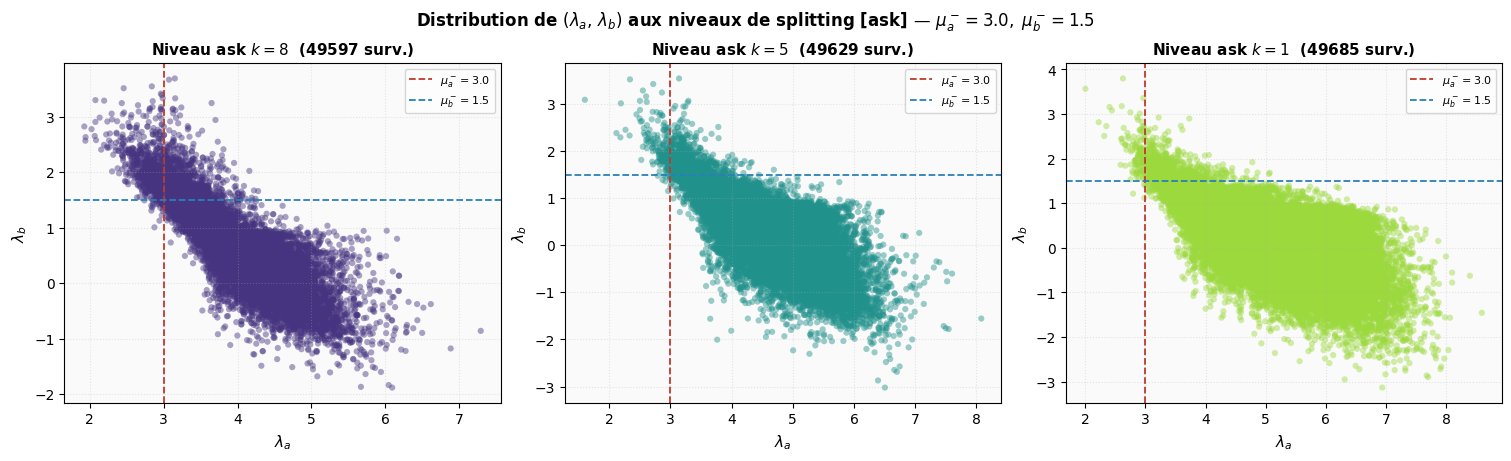


Phase en ligne depuis k=5 (40000 échantillons)...
  Terminé en 2.20s
  p_offline=0.9695  p_online=0.9664  p_total=0.9369
  38657 échantillons de Q_a2,  moyenne=14.31

Référence — splitting complet (§15)...
  p=0.9303  (50000 échantillons)  en 15.36s
  moyenne Q_a2=14.34


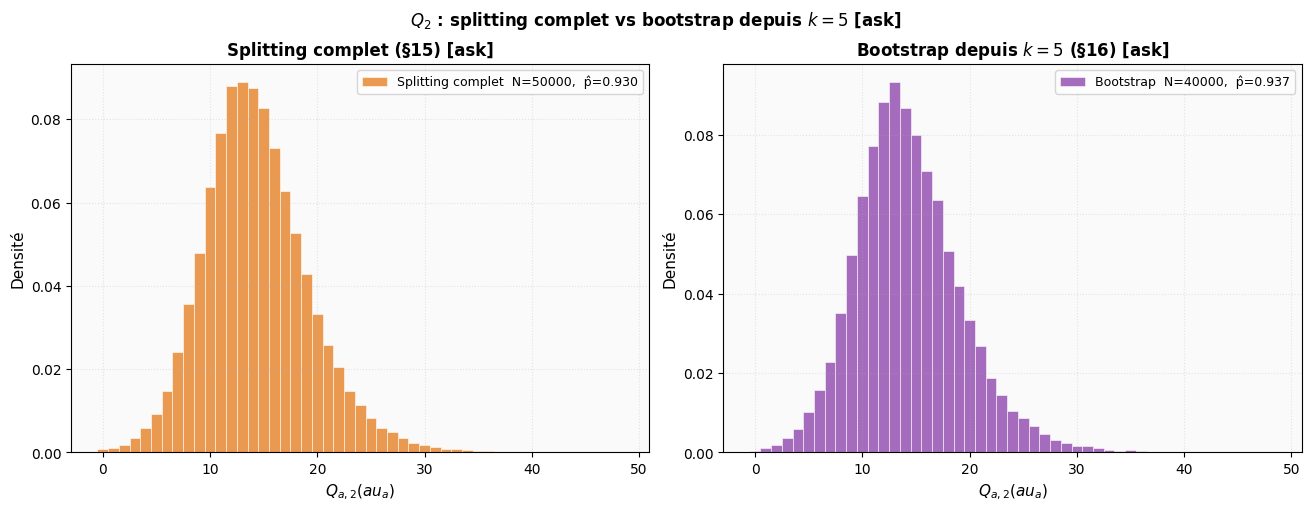


=== Cas bid (§16) : Q_{b,2} sachant tau_b < tau_a ===
Phase hors-ligne bid...
  Terminé en 9.21s
    k= 0 : 39660 survivants  p_k=0.793
    k= 1 : 39388 survivants  p_k=0.788
    k= 2 : 39361 survivants  p_k=0.787
    k= 3 : 38981 survivants  p_k=0.780
    k= 4 : 38793 survivants  p_k=0.776
    k= 5 : 38612 survivants  p_k=0.772
    k= 6 : 38306 survivants  p_k=0.766
    k= 7 : 37531 survivants  p_k=0.751
    k= 8 : 36775 survivants  p_k=0.736
    k= 9 : 35544 survivants  p_k=0.711


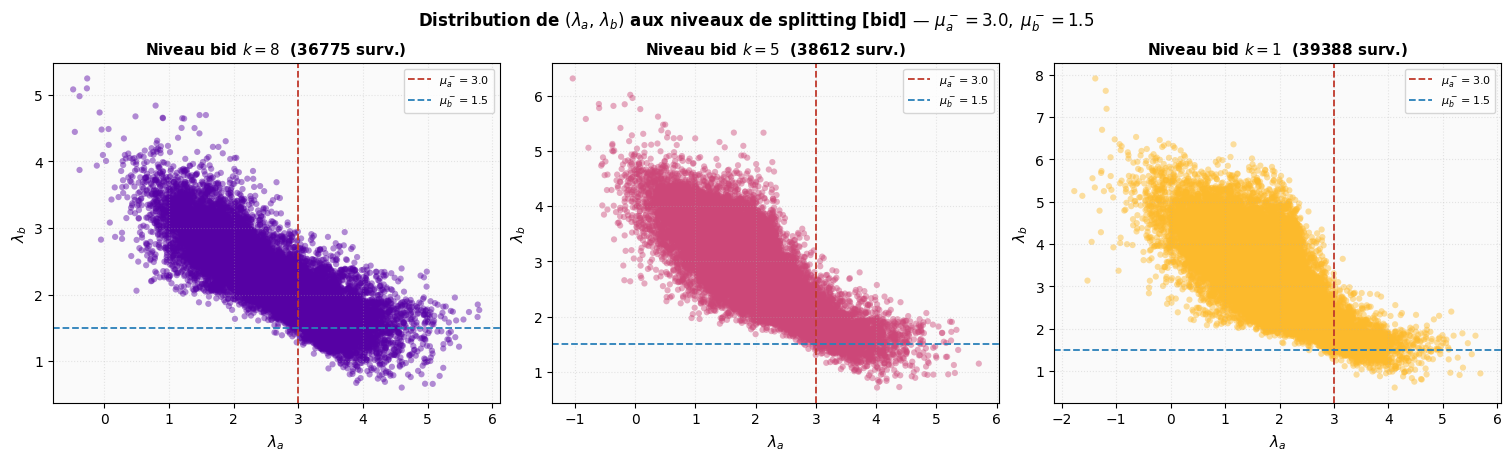


Phase en ligne bid depuis k=5 (40000 échantillons)...
  Terminé en 1.22s
  p_offline=0.3007  p_online=0.3016  p_total=0.0907
  12065 échantillons de Q_b2,  moyenne=13.42

Référence bid — splitting complet (§15)...
  p=0.0699  (50000 échantillons)  en 8.98s
  moyenne Q_b2=13.52


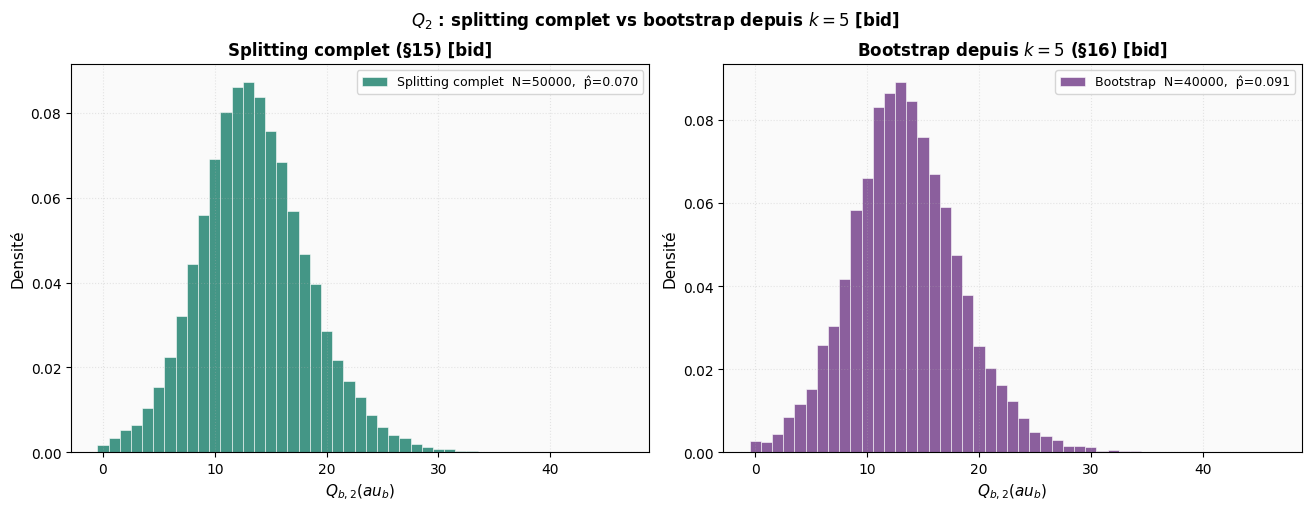

In [40]:
# ── Paramètres cas asymétrique ────────────────────────────────────────────────────────────────────────────────
MU_A16, MU_B16 = 3.0, 1.5
ALPHA16, BETA16 = 0.5, 1.0
A16, B16 = 0.8, 1.0
N_OFFLINE16 = 50000
N_ONLINE16  = 40000
START_K16   = 5

# ── Phase hors-ligne ──────────────────────────────────────────────────────────────────────────
print('Phase hors-ligne : collecte des états aux niveaux de splitting...')
t0 = _time.perf_counter()
lvl_states, lvl_probs = collect_level_states(
    N_OFFLINE16, MU_A16, MU_B16, ALPHA16, BETA16, A16, B16)
t_off = _time.perf_counter() - t0
print(f'  Terminé en {t_off:.2f}s')
for k in sorted(lvl_states.keys()):
    print(f'    k={k:2d} : {len(lvl_states[k]):3d} survivants  p_k={lvl_probs[k]:.3f}')

# ── Visualisation (λ_a, λ_b) aux niveaux 8, 5, 1 ───────────────────────────────────────────
levels_vis = [k for k in [8, 5, 1] if k in lvl_states and lvl_states[k]]
plot_lambda_at_levels(lvl_states, levels_vis, MU_A16, MU_B16)

# ── Phase en ligne depuis k = START_K16 ────────────────────────────────────────────────
print(f'\nPhase en ligne depuis k={START_K16} ({N_ONLINE16} échantillons)...')
t0 = _time.perf_counter()
q2_on, p_off, p_on = sample_and_complete(
    lvl_states, lvl_probs, START_K16, N_ONLINE16,
    MU_A16, MU_B16, ALPHA16, BETA16, A16, B16)
t_on = _time.perf_counter() - t0
p_tot = p_off * p_on
print(f'  Terminé en {t_on:.2f}s')
print(f'  p_offline={p_off:.4f}  p_online={p_on:.4f}  p_total={p_tot:.4f}')
if q2_on:
    print(f'  {len(q2_on)} échantillons de Q_a2,  moyenne={np.mean(q2_on):.2f}')

# ── Référence : splitting complet §15 ────────────────────────────────────────────────────────────
print('\nRéférence — splitting complet (§15)...')
t0 = _time.perf_counter()
q2_full, p_full = splitting_Q2_distribution(
    N_OFFLINE16, MU_A16, MU_B16, ALPHA16, BETA16, A16, B16)
t_full = _time.perf_counter() - t0
print(f'  p={p_full:.4f}  ({len(q2_full)} échantillons)  en {t_full:.2f}s')
if q2_full:
    print(f'  moyenne Q_a2={np.mean(q2_full):.2f}')

# ── Comparaison visuelle ────────────────────────────────────────────────────────────────────────────────
plot_q2_level_comparison(q2_full, q2_on, START_K16,
                          p_full, p_off, p_on,
                          N_OFFLINE16, N_ONLINE16)


# ── Cas bid (§16) : mu_b < mu_a donc tau_b < tau_a est l'événement rare ───────────────
print('\n=== Cas bid (§16) : Q_{b,2} sachant tau_b < tau_a ===')
print('Phase hors-ligne bid...')
t0 = _time.perf_counter()
lvl_states_bid, lvl_probs_bid = collect_level_states_bid(
    N_OFFLINE16, MU_A16, MU_B16, ALPHA16, BETA16, A16, B16)
t_off_bid = _time.perf_counter() - t0
print(f'  Terminé en {t_off_bid:.2f}s')
for k in sorted(lvl_states_bid.keys()):
    print(f'    k={k:2d} : {len(lvl_states_bid[k]):3d} survivants  p_k={lvl_probs_bid[k]:.3f}')

levels_vis_bid = [k for k in [8, 5, 1] if k in lvl_states_bid and lvl_states_bid[k]]
plot_lambda_at_levels_bid(lvl_states_bid, levels_vis_bid, MU_A16, MU_B16)

print(f'\nPhase en ligne bid depuis k={START_K16} ({N_ONLINE16} échantillons)...')
t0 = _time.perf_counter()
q2_on_bid, p_off_bid, p_on_bid = sample_and_complete_bid(
    lvl_states_bid, lvl_probs_bid, START_K16, N_ONLINE16,
    MU_A16, MU_B16, ALPHA16, BETA16, A16, B16)
t_on_bid = _time.perf_counter() - t0
p_tot_bid = p_off_bid * p_on_bid
print(f'  Terminé en {t_on_bid:.2f}s')
print(f'  p_offline={p_off_bid:.4f}  p_online={p_on_bid:.4f}  p_total={p_tot_bid:.4f}')
if q2_on_bid:
    print(f'  {len(q2_on_bid)} échantillons de Q_b2,  moyenne={np.mean(q2_on_bid):.2f}')

print('\nRéférence bid — splitting complet (§15)...')
t0 = _time.perf_counter()
q2_full_bid, p_full_bid = splitting_Q2_bid_distribution(
    N_OFFLINE16, MU_A16, MU_B16, ALPHA16, BETA16, A16, B16)
t_full_bid = _time.perf_counter() - t0
print(f'  p={p_full_bid:.4f}  ({len(q2_full_bid)} échantillons)  en {t_full_bid:.2f}s')
if q2_full_bid:
    print(f'  moyenne Q_b2={np.mean(q2_full_bid):.2f}')

plot_q2_level_comparison_bid(q2_full_bid, q2_on_bid, START_K16,
                              p_full_bid, p_off_bid, p_on_bid,
                              N_OFFLINE16, N_ONLINE16)


## 17. Flash crash : $k$ chutes de prix consécutives

### Définition

Un **flash crash de profondeur $k$** est l'événement où le premier ask s'épuise $k$ fois de suite **avant** que le bid ne s'épuise une seule fois — soit $k$ sauts de prix vers le bas consécutifs :

$$\mathrm{FC}_k = \{\tau_a^{(1)} < \tau_b,\; \tau_a^{(2)} < \tau_b,\; \ldots,\; \tau_a^{(k)} < \tau_b\}$$

Sa probabilité se factorise :

$$P(\mathrm{FC}_k) = \prod_{i=1}^k P\!\left(\tau_a^{(i)} < \tau_b \mid \mathrm{FC}_{i-1}\right)$$

### Couplage via les intensités Hawkes

Après chaque épuisement de l'ask, le processus de Hawkes repart avec les intensités **finales** $(\lambda_a^{\rm fin}, \lambda_b^{\rm fin})$ comme conditions initiales du cycle suivant. Comme l'épuisement de l'ask implique de nombreux événements de décrémentation, $\lambda_a^{\rm fin}$ est typiquement **élevé** (auto-excitation) et $\lambda_b^{\rm fin}$ est abaissé (excitation croisée). Ainsi :

$$P(\mathrm{FC}_k) > p_1^k \quad \text{où } p_1 = P(\tau_a < \tau_b)$$

Les cycles ne sont pas indépendants — les intensités héritées rendent le flash crash **plus probable** qu'un modèle à cycles indépendants ne le prédirait.

### Algorithme

À chaque cycle $i$, on applique le splitting AMS (§15) avec $N$ particules pour estimer $P(\tau_a^{(i)} < \tau_b \mid \mathrm{FC}_{i-1})$. Entre deux cycles, on remet $q_{a,1} = Q_0$ (nouvelle deuxième limite devient première) et on **porte** $(\lambda_a, \lambda_b, q_{b,1})$ vers le cycle suivant.


### Limite du MC direct et rôle de la courbe de référence

**Pourquoi la courbe MC s'arrête-t-elle ?**

La méthode Monte-Carlo naïf estime $P(\mathrm{FC}_k)$ en comptant les succès sur $N_{MC}$ trajectoires. Or cette probabilité décroît exponentiellement avec $k$ :

$$P(\mathrm{FC}_k) \approx p_1^k, \qquad p_1 = P(\tau_a < \tau_b)$$

Dès que $P(\mathrm{FC}_k) \cdot N_{MC} < 1$ — c'est-à-dire dès que l'on s'attend à moins d'un succès sur $N_{MC}$ simulations — aucun événement n'est observé et l'estimateur MC vaut exactement 0, ce qui est non informatif. L'arrêt de la courbe MC dans la figure n'est donc pas un choix arbitraire : c'est la **frontière naturelle de faisabilité** du MC naïf. C'est précisément pour franchir cette frontière que les méthodes AMS (splitting) et IS sont indispensables.

**Pourquoi la courbe grise est-elle pertinente ?**

La courbe grise $\hat{p}_1^k$ représente le **modèle d'indépendance** : ce que serait $P(\mathrm{FC}_k)$ si chaque cycle successif était un essai de Bernoulli indépendant de probabilité $p_1$. Ce modèle est la prédiction naïve qui ignore la mémoire du processus de Hawkes.

La courbe AMS (orange) est systématiquement **au-dessus** de la courbe grise, pour une raison fondamentale : après chaque épuisement de l'ask, l'intensité $\lambda_a^-(t)$ est élevée par auto-excitation (elle a accumulé des chocs lors du cycle précédent), ce qui rend le prochain épuisement plus probable. Les cycles sont donc **positivement corrélés**, et l'on a :

$$P(\mathrm{FC}_k) > p_1^k \quad \forall k \geq 2$$

L'écart entre les deux courbes quantifie la **prime de cascade** attribuable à la mémoire Hawkes : ignorer cette corrélation sous-estime le risque de flash crash profond. La courbe grise joue ainsi le rôle d'un **plancher de référence** : tout modèle qui ne tient pas compte des intensités héritées d'un cycle à l'autre produit une estimation optimiste du risque.


In [41]:
import time as _time

def flash_crash_splitting(k_drops, N_particles, mu_minus_a, mu_minus_b, alpha, beta,
                          lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                          q_0_a=Q_0_A, q_0_b=Q_0_B):
    mu_a = float(mu_minus_a); mu_b = float(mu_minus_b)
    al = float(alpha);        be = float(beta)
    lpa = float(lambda_plus_a); lpb = float(lambda_plus_b)

    particles = [{'q_a': int(q_0_a), 'q_b': int(q_0_b),
                  'la': mu_a, 'lb': mu_b,
                  't': 0., 'tla': 0., 'tlb': 0.}
                 for _ in range(N_particles)]
    total_prob = 1.0
    round_probs = []

    for drop in range(k_drops):
        round_prob = 1.0
        for target in range(int(q_0_a) - 1, -1, -1):
            survivors = []
            for p in particles:
                ta, qa, tb, qb, la_f, lb_f, t_f, tla_f, tlb_f, ok = _hawkes_one_level(
                    mu_a, mu_b, al, be, lpa, lpb,
                    p['q_a'], p['q_b'], p['la'], p['lb'],
                    p['t'], p['tla'], p['tlb'], target, 1)
                if ok:
                    survivors.append({
                        'q_a': int(qa[-1]),
                        'q_b': int(qb[-1]) if len(qb) else p['q_b'],
                        'la': la_f, 'lb': lb_f,
                        't': t_f, 'tla': tla_f, 'tlb': tlb_f})
            n_s = len(survivors)
            if n_s == 0:
                return 0.0, round_probs + [0.0] * (k_drops - drop)
            round_prob *= n_s / N_particles
            idx = np.random.choice(n_s, size=N_particles, replace=True)
            particles = [dict(survivors[i]) for i in idx]

        round_probs.append(round_prob)
        total_prob *= round_prob

        # Carry (lambda, q_b), reset q_a and time reference
        for p in particles:
            p['q_a'] = int(q_0_a)
            p['t'] = 0.; p['tla'] = 0.; p['tlb'] = 0.

    return total_prob, round_probs


def plot_flash_crash_prob(k_max, N_particles, mu_minus_a, mu_minus_b, alpha, beta,
                          lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                          q_0_a=Q_0_A, q_0_b=Q_0_B, N_mc=3000):
    print(f'Flash crash splitting (mu_a={mu_minus_a}, mu_b={mu_minus_b}):')
    probs_split = []
    for k in range(1, k_max + 1):
        t0 = _time.perf_counter()
        p, rprobs = flash_crash_splitting(k, N_particles, mu_minus_a, mu_minus_b,
                                          alpha, beta, lambda_plus_a, lambda_plus_b,
                                          q_0_a, q_0_b)
        dt = _time.perf_counter() - t0
        probs_split.append(p)
        print(f'  k={k}: p={p:.5f}  rounds={[f"{r:.3f}" for r in rprobs]}  ({dt:.2f}s)')

    p1 = probs_split[0]
    probs_naive = [p1**k for k in range(1, k_max + 1)]

    # MC direct pour k = 1..k_max : arrêt naturel quand 0 succès sur N_mc tirages
    # (au-delà, P(FC_k) est trop petite pour être estimée sans méthode rare-event)
    probs_mc, ks_mc = [], []
    for k in range(1, k_max + 1):
        count = 0
        for _ in range(N_mc):
            q_a, q_b = int(q_0_a), int(q_0_b)
            la, lb = float(mu_minus_a), float(mu_minus_b)
            ok_all = True
            for _ in range(k):
                ta, qa, tb, qb, la_f, lb_f, tau = _hawkes_loop(
                    float(mu_minus_a), float(mu_minus_b), float(alpha), float(beta),
                    float(lambda_plus_a), float(lambda_plus_b),
                    q_a, q_b, la, lb)
                if int(qa[-1]) != 0:
                    ok_all = False; break
                q_a = int(q_0_a)
                q_b = int(qb[-1]) if len(qb) else q_b
                la, lb = la_f, lb_f
            if ok_all:
                count += 1
        if count == 0:
            break   # Arrêt naturel : 0 succès sur N_mc → probabilité inestimable par MC naïf
        probs_mc.append(count / N_mc)
        ks_mc.append(k)

    ks = list(range(1, k_max + 1))
    fig, ax = plt.subplots(figsize=(8, 5), facecolor='white', constrained_layout=True)
    ax.semilogy(ks, probs_split, 'o-', color='#e67e22', lw=2, ms=8,
                label='Splitting AMS (intensités Hawkes couplées)')
    ax.semilogy(ks, probs_naive, 's--', color='#7f8c8d', lw=1.5, ms=6,
                label=f'$\\hat{{p}}_1^k$ indépendant (référence, $\\hat{{p}}_1={p1:.3f}$)')
    if probs_mc:
        k_stop = ks_mc[-1]
        ax.semilogy(ks_mc, probs_mc, '^:', color='#2980b9', lw=1.5, ms=8,
                    label=f'MC direct (arrêt k={k_stop} : 0 succès sur {N_mc})')
        ax.axvline(k_stop + 0.5, color='#2980b9', lw=0.8, ls=':', alpha=0.6)
    ax.set_xlabel('Profondeur $k$', fontsize=12)
    ax.set_ylabel('$P(\\mathrm{FC}_k)$', fontsize=12)
    ax.set_title(
        f'Flash crash : $\\mu_a^-={mu_minus_a},\\; \\mu_b^-={mu_minus_b},\\; Q_0={q_0_a}$',
        fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3, linestyle=':')
    ax.set_facecolor('#fafafa')
    ax.set_xticks(ks)
    plt.show()


print('Section 17 : fonctions flash crash définies.')


Section 17 : fonctions flash crash définies.


Flash crash splitting (mu_a=2.0, mu_b=2.0):
  k=1: p=0.49915  rounds=['0.499']  (3.67s)
  k=2: p=0.28904  rounds=['0.499', '0.579']  (6.66s)
  k=3: p=0.17401  rounds=['0.500', '0.580', '0.600']  (10.26s)
  k=4: p=0.10856  rounds=['0.497', '0.579', '0.610', '0.617']  (13.44s)
  k=5: p=0.06714  rounds=['0.499', '0.576', '0.597', '0.622', '0.630']  (17.40s)
  k=6: p=0.04419  rounds=['0.502', '0.575', '0.599', '0.620', '0.632', '0.652']  (28.17s)


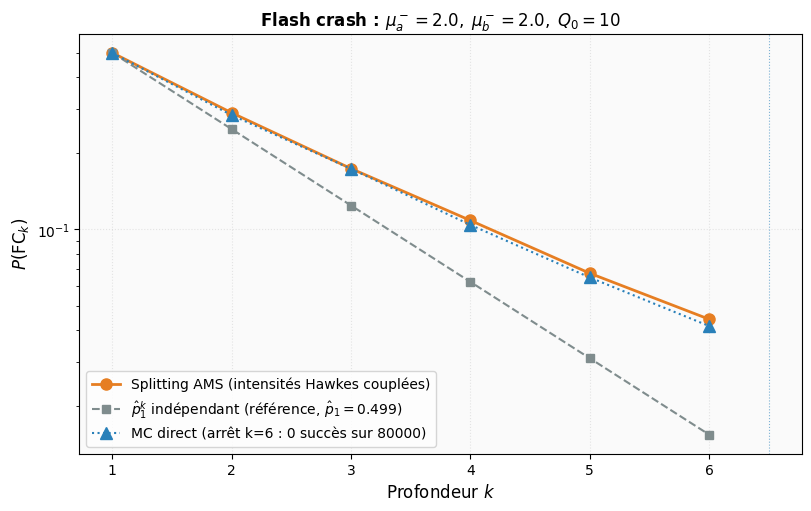

  Temps flash crash symétrique : 90.33s
Flash crash splitting (mu_a=1.5, mu_b=3.0):
  k=1: p=0.06827  rounds=['0.068']  (3.77s)
  k=2: p=0.00844  rounds=['0.069', '0.122']  (8.05s)
  k=3: p=0.00117  rounds=['0.069', '0.121', '0.139']  (10.80s)
  k=4: p=0.00017  rounds=['0.070', '0.121', '0.140', '0.145']  (18.02s)
  k=5: p=0.00003  rounds=['0.071', '0.120', '0.138', '0.147', '0.152']  (15.80s)


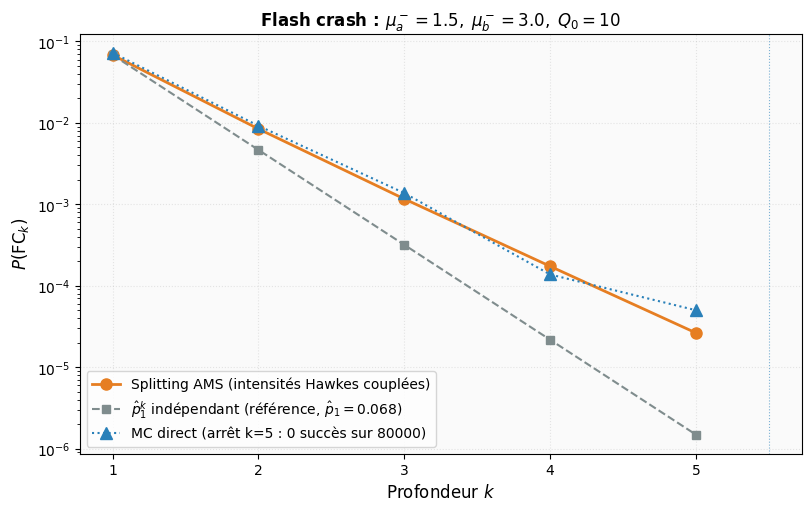

  Temps flash crash asymétrique : 60.44s


In [42]:
# Cas symétrique : l'effet du couplage est visible mais modéré
t0 = _time.perf_counter()
plot_flash_crash_prob(k_max=6, N_particles=40_000,
                       mu_minus_a=2.0, mu_minus_b=2.0, alpha=0.5, beta=1.0,
                       N_mc=80_000)
print(f'  Temps flash crash symétrique : {_time.perf_counter()-t0:.2f}s')

# Cas asymétrique : mu_a < mu_b → l'ask est rare, flash crash très rare
t0 = _time.perf_counter()
plot_flash_crash_prob(k_max=5, N_particles=40_000,
                       mu_minus_a=1.5, mu_minus_b=3.0, alpha=0.5, beta=1.0,
                       N_mc=80_000)
print(f'  Temps flash crash asymétrique : {_time.perf_counter()-t0:.2f}s')


## 18. Importance Sampling par basculement exponentiel

### Principe

L'*importance sampling* remplace la loi originale $P$ par une loi auxiliaire $\tilde{P}$ sous laquelle l'événement rare est plus fréquent, puis corrige par le rapport de vraisemblance $L = dP/d\tilde{P}$ :

$$P(\tau_a < \tau_b) = \mathbb{E}_{\tilde{P}}\!\left[\mathbf{1}_{\tau_a < \tau_b}\, L\right]$$

### Basculement exponentiel

On tord les intensités de décrémentation par un paramètre $\theta > 0$ :

$$\tilde{\lambda}_a^-(t) = e^{\theta}\,\lambda_a^-(t), \qquad \tilde{\lambda}_b^-(t) = e^{-\theta}\,\lambda_b^-(t)$$

Sous $\tilde{P}$, l'ask décremente plus vite et le bid plus lentement — l'événement $\{\tau_a < \tau_b\}$ devient plus probable. Le log-rapport de vraisemblance s'écrit :

$$\log L = (e^{\theta}-1)\,I_a + (e^{-\theta}-1)\,I_b - \theta N_a + \theta N_b$$

où $I_a = \int_0^\tau \lambda_a^-(t)\,dt$ et $I_b = \int_0^\tau \lambda_b^-(t)\,dt$ sont les **compensateurs** (intégrales exactes entre événements), $N_a$ et $N_b$ les nombres de décrémentations sous $\tilde{P}$.

### Condition d'optimalité de $\theta^*$

L'estimateur IS est $w = \mathbf{1}_{\tau_a < \tau_b}\,L$ ; on minimise le **coefficient de variation au carré** :

$$\operatorname{CV}^2(\theta) = \frac{\mathbb{E}_{\tilde{P}}[w^2]}{P^2} - 1, \qquad P = \mathbb{E}_P[\mathbf{1}_{\tau_a < \tau_b}]$$

En dérivant $\mathbb{E}_{\tilde{P}}[w^2]$ par rapport à $\theta$ via le *score* de la mesure basculée, on obtient la condition d'optimalité :

$$\frac{d}{d\theta}\,\mathbb{E}_{\tilde{P}}\!\left[w^2\right]
= \mathbb{E}_{\tilde{P}}\!\left[w^2\,\frac{\partial \log L}{\partial\theta}\right]
= \mathbb{E}_{\tilde{P}}\!\left[w^2\,\bigl(e^\theta I_a - e^{-\theta} I_b - N_a + N_b\bigr)\right] = 0$$

Cette équation **ne possède pas de solution analytique fermée** : les compensateurs $I_a, I_b$ et les comptages $N_a, N_b$ sont eux-mêmes des fonctionnelles de la trajectoire Hawkes sous $\tilde{P}_\theta$, couplant les moments de toutes ces quantités.

On résout donc par **balayage** (*grid search*) sur $\theta \in [0, 3]$, en estimant $\operatorname{CV}^2(\theta)$ par Monte Carlo sous chaque loi basculée. En pratique, la surface $\operatorname{CV}^2(\theta)$ est **quasi-convexe** et le minimum est bien identifié pour $\theta \approx 1$–$2$ dans les régimes asymétriques étudiés ici ($\mu_a^- < \mu_b^-$). Pour $\theta \to 0$ on retrouve le MC direct (variance maximale) ; pour $\theta \to +\infty$ la loi basculée s'éloigne trop de la loi cible et les poids $L \to 0$ empiriquement, dégradant l'estimateur.


In [43]:
# ─── Simulation sous loi basculée + calcul du rapport de vraisemblance ────────
@_njit
def _hawkes_loop_tilted(mu_a, mu_b, alpha, beta, lp_a, lp_b,
                        q_a, q_b, la0, lb0, theta):
    et_a = np.exp(theta)
    et_b = np.exp(-theta)

    MAX = 100000
    ta = np.empty(MAX); qa = np.empty(MAX, dtype=np.int64)
    tb = np.empty(MAX); qb = np.empty(MAX, dtype=np.int64)
    na = nb = 1
    ta[0] = 0.; qa[0] = q_a; tb[0] = 0.; qb[0] = q_b

    t = tla = tlb = 0.
    la = la0; lb = lb0
    int_ea = int_eb = 0.
    n_ask_decr = n_bid_decr = 0

    while q_a > 0 and q_b > 0:
        # Intensity at current time t
        ea_t = mu_a + (la - mu_a) * np.exp(-beta * (t - tla))
        eb_t = mu_b + (lb - mu_b) * np.exp(-beta * (t - tlb))
        if ea_t < 0.: ea_t = 0.
        if eb_t < 0.: eb_t = 0.

        # Supremum bounds under tilted measure
        ba = la if la > mu_a else mu_a
        bb = lb if lb > mu_b else mu_b
        sup = et_a * ba + et_b * bb + lp_a + lp_b

        dt = np.random.exponential(1. / sup)
        tp = t + dt

        # Accumulate compensators (exact integral of original ea, eb over [t, tp])
        int_ea += mu_a * dt + (ea_t - mu_a) / beta * (1. - np.exp(-beta * dt))
        int_eb += mu_b * dt + (eb_t - mu_b) / beta * (1. - np.exp(-beta * dt))

        # Intensities at proposed time tp (original, untilted)
        pa = mu_a + (la - mu_a) * np.exp(-beta * (tp - tla))
        pb = mu_b + (lb - mu_b) * np.exp(-beta * (tp - tlb))
        if pa < 0.: pa = 0.
        if pb < 0.: pb = 0.

        u = np.random.random()
        if u < lp_a / sup:                              # ask arrival
            q_a += 1; t = tp; tla = t; la = pa - alpha; lb = pb + alpha
            ta[na] = t; qa[na] = q_a; na += 1
        elif u < (lp_a + et_a * pa) / sup:              # ask decrement (tilted)
            q_a -= 1; n_ask_decr += 1
            t = tp; tla = t; la = pa + alpha; lb = pb - alpha
            ta[na] = t; qa[na] = q_a; na += 1
        elif u < (lp_a + et_a * ba) / sup:              # ask null event
            la = pa; lb = pb; tla = tp; t = tp
        elif u < (lp_a + et_a * ba + lp_b) / sup:      # bid arrival
            q_b += 1; t = tp; tlb = t; lb = pb - alpha; la = pa + alpha
            tb[nb] = t; qb[nb] = q_b; nb += 1
        elif u < (lp_a + et_a * ba + lp_b + et_b * pb) / sup:  # bid decrement (tilted)
            q_b -= 1; n_bid_decr += 1
            t = tp; tlb = t; lb = pb + alpha; la = pa - alpha
            tb[nb] = t; qb[nb] = q_b; nb += 1
        else:                                            # bid null event
            lb = pb; la = pa; tlb = tp; t = tp

    tau = ta[na-1] if ta[na-1] > tb[nb-1] else tb[nb-1]
    log_lr = ((np.exp(theta) - 1.) * int_ea
              + (np.exp(-theta) - 1.) * int_eb
              - theta * n_ask_decr
              + theta * n_bid_decr)
    return ta[:na], qa[:na], tb[:nb], qb[:nb], la, lb, tau, log_lr


# Warm-up JIT
_hawkes_loop_tilted(2., 2., .5, 1., 1.2, 1.2, 5, 5, 2., 2., 0.5)
print('_hawkes_loop_tilted compilé.')


# ─── Estimateur IS ────────────────────────────────────────────────────────────
def importance_sampling_estimate(N, mu_minus_a, mu_minus_b, alpha, beta, theta,
                                  lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                                  q_0_a=Q_0_A, q_0_b=Q_0_B):
    mu_a = float(mu_minus_a); mu_b = float(mu_minus_b)
    weights = []
    for _ in range(N):
        ta, qa, tb, qb, _, _, tau, log_lr = _hawkes_loop_tilted(
            mu_a, mu_b, float(alpha), float(beta),
            float(lambda_plus_a), float(lambda_plus_b),
            int(q_0_a), int(q_0_b), mu_a, mu_b, float(theta))
        if int(qa[-1]) == 0:   # ask exhausted first
            weights.append(np.exp(log_lr))
        else:
            weights.append(0.)
    w = np.array(weights)
    p_hat = float(np.mean(w))
    std_hat = float(np.std(w) / np.sqrt(N))
    return p_hat, std_hat


# ─── Comparaison IS vs splitting vs MC + variance en fonction de theta ─────────
def plot_is_comparison(mu_minus_a, mu_minus_b, alpha, beta,
                        thetas, N_is=600, N_split=400, N_mc=4000,
                        lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                        q_0_a=Q_0_A, q_0_b=Q_0_B):
    # ── IS sweep over theta ────────────────────────────────────────────────────
    print(f'IS sweep (N={N_is}) sur theta={thetas}...')
    p_is  = []
    cv_is = []   # coefficient of variation = std / p_hat
    for th in thetas:
        p_hat, std_hat = importance_sampling_estimate(
            N_is, mu_minus_a, mu_minus_b, alpha, beta, th,
            lambda_plus_a, lambda_plus_b, q_0_a, q_0_b)
        p_is.append(p_hat)
        cv_is.append(std_hat * np.sqrt(N_is) / p_hat if p_hat > 0 else np.nan)
        print(f'  theta={th:.2f}: p={p_hat:.4f}  CV={cv_is[-1]:.3f}')

    # ── Splitting reference ─────────────────────────────────────────────────────
    print(f'Splitting (N={N_split})...')
    _, p_spl = splitting_Q2_distribution(
        N_split, mu_minus_a, mu_minus_b, alpha, beta, 0.8, 1.0,
        lambda_plus_a, lambda_plus_b, LAMBDA_PLUS_2, LAMBDA_MINUS_2,
        q_0_a, q_0_b, Q_0_2)
    print(f'  Splitting p={p_spl:.4f}')

    # ── Direct MC reference ─────────────────────────────────────────────────────
    print(f'MC direct (N={N_mc})...')
    n_ok = 0
    for _ in range(N_mc):
        ta, qa, *_ = _hawkes_loop(
            float(mu_minus_a), float(mu_minus_b), float(alpha), float(beta),
            float(lambda_plus_a), float(lambda_plus_b),
            int(q_0_a), int(q_0_b), float(mu_minus_a), float(mu_minus_b))
        if int(qa[-1]) == 0:
            n_ok += 1
    p_mc = n_ok / N_mc
    print(f'  MC direct p={p_mc:.4f}  ({n_ok}/{N_mc} succès)')

    # ── Figure ─────────────────────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5),
                                    facecolor='white', constrained_layout=True)

    # Gauche : estimées p vs theta
    ax1.plot(thetas, p_is, 'o-', color='#8e44ad', lw=2, ms=7, label='IS (basculement)')
    ax1.axhline(p_spl, color='#e67e22', lw=1.5, ls='--',
                label=f'Splitting: {p_spl:.4f}')
    ax1.axhline(p_mc, color='#2980b9', lw=1.5, ls=':',
                label=f'MC direct: {p_mc:.4f}')
    ax1.set_xlabel('$\\theta$', fontsize=12)
    ax1.set_ylabel('$\\hat{P}(\\tau_a < \\tau_b)$', fontsize=12)
    ax1.set_title('Estimée de probabilité vs $\\theta$', fontsize=11, fontweight='bold')
    ax1.legend(fontsize=9)
    ax1.grid(alpha=0.3, linestyle=':')
    ax1.set_facecolor('#fafafa')

    # Droite : coefficient de variation vs theta
    ax2.plot(thetas, cv_is, 's-', color='#c0392b', lw=2, ms=7)
    best_th = thetas[int(np.nanargmin(cv_is))]
    ax2.axvline(best_th, color='#27ae60', lw=1.3, ls='--',
                label=f'$\\theta^*\\approx{best_th:.2f}$')
    ax2.set_xlabel('$\\theta$', fontsize=12)
    ax2.set_ylabel('Coefficient de variation (CV)', fontsize=12)
    ax2.set_title('Variance IS vs $\\theta$ (CV = $\\sigma/\\hat{p}$)', fontsize=11,
                   fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(alpha=0.3, linestyle=':')
    ax2.set_facecolor('#fafafa')

    fig.suptitle(
        f'Importance Sampling — $\\mu_a^-={mu_minus_a},\\; \\mu_b^-={mu_minus_b},\\; Q_0={q_0_a}$',
        fontsize=12, fontweight='bold')
    plt.show()


print('Section 18 : fonctions IS définies.')


_hawkes_loop_tilted compilé.
Section 18 : fonctions IS définies.


IS sweep (N=30000) sur theta=[0.0, 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1]...
  theta=0.00: p=0.0704  CV=3.635
  theta=0.30: p=0.0714  CV=1.983
  theta=0.60: p=0.0678  CV=5.116
  theta=0.90: p=0.0840  CV=54.020
  theta=1.20: p=0.0340  CV=25.959
  theta=1.50: p=0.0166  CV=56.458
  theta=1.80: p=0.0065  CV=67.436
  theta=2.10: p=0.0048  CV=148.089
Splitting (N=40000)...
  Splitting p=0.0701
MC direct (N=200000)...
  MC direct p=0.0707  (14145/200000 succès)


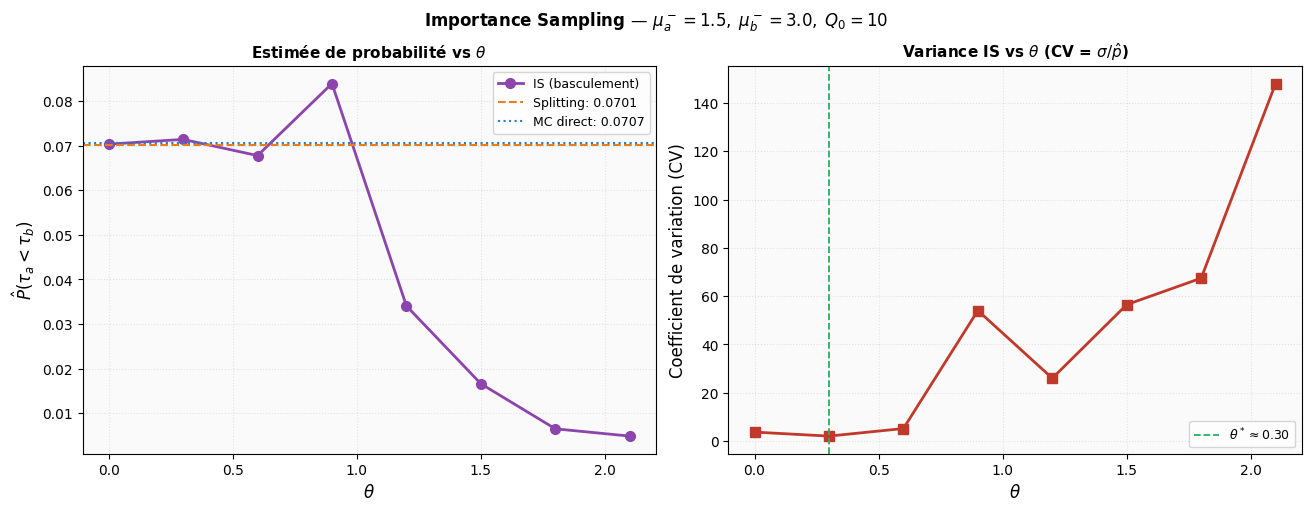

  Temps IS comparison : 10.41s


In [44]:
# Cas défavorable à l'ask : mu_a < mu_b → tau_a < tau_b est l'événement rare
# On tilt theta > 0 pour augmenter les décrements ask et réduire les bid
t0 = _time.perf_counter()
plot_is_comparison(
    mu_minus_a=1.5, mu_minus_b=3.0, alpha=0.5, beta=1.0,
    thetas=[0.0, 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1],
    N_is=30_000, N_split=40_000, N_mc=200_000,
    q_0_a=Q_0_A, q_0_b=Q_0_B)
print(f'  Temps IS comparison : {_time.perf_counter()-t0:.2f}s')


## 19. Intervalles de confiance : splitting vs importance sampling

### CLT pour l'estimateur AMS

L'estimateur AMS est un produit de proportions binomiales : $\hat{P}_{\rm AMS} = \prod_{k=0}^{Q_0-1} \hat{p}_k$ avec $\hat{p}_k = N_k^{\rm surv}/N$. Par la méthode delta appliquée au logarithme :

$$\sqrt{N}\,(\hat{P}_{\rm AMS} - P) \xrightarrow{d} \mathcal{N}\!\left(0,\; P^2 \sum_{k} \frac{1-p_k}{p_k}\right)$$

IC à 95 % :

$$\hat{P}_{\rm AMS} \pm 1.96\,\hat{P}_{\rm AMS}\sqrt{\frac{1}{N}\sum_k \frac{1-\hat{p}_k}{\hat{p}_k}}$$

### CLT pour l'estimateur IS

Les poids IS $w_i = \mathbf{1}_{\tau_a < \tau_b}\, L_i$ sont i.i.d. ; par le TCL classique :

$$\sqrt{N}\,(\hat{P}_{\rm IS} - P) \xrightarrow{d} \mathcal{N}(0,\,\mathrm{Var}(w))$$

IC à 95 % : $\hat{P}_{\rm IS} \pm 1.96\,\hat{\sigma}_w/\sqrt{N}$

### Efficacité relative

On compare les demi-largeurs d'IC en fonction de $N$ pour les deux méthodes et on vérifie empiriquement la loi normale sur $R$ réplications indépendantes. Le **panneau droit** des figures ci-dessous trace la largeur des IC à 95 % en fonction de $N$ : la décroissance observée suit bien la loi théorique $\propto 1/\sqrt{N}$, validant empiriquement le CLT delta-méthode pour AMS et le CLT classique pour IS.

La **cellule suivante** (§19 bis) présente une validation dédiée de la convergence de l'estimateur AMS seul : elle trace la moyenne et l'écart-type de $\hat{P}_{\rm AMS}$ sur $R$ réplications indépendantes en fonction de $N$, avec confirmation log-log de la pente $-1/2$ théorique.


In [45]:
import time as _time


def _ams_p_and_var(N_particles, mu_minus_a, mu_minus_b, alpha, beta,
                   lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                   q_0_a=Q_0_A, q_0_b=Q_0_B):
    mu_a = float(mu_minus_a); mu_b = float(mu_minus_b)
    al = float(alpha); be = float(beta)
    lpa = float(lambda_plus_a); lpb = float(lambda_plus_b)
    particles = [{'q_a': int(q_0_a), 'q_b': int(q_0_b),
                  'la': mu_a, 'lb': mu_b,
                  't': 0., 'tla': 0., 'tlb': 0.}
                 for _ in range(N_particles)]
    p_hat = 1.0
    delta_var = 0.0
    for target in range(int(q_0_a) - 1, -1, -1):
        survivors = []
        for p in particles:
            ta, qa, tb, qb, la_f, lb_f, t_f, tla_f, tlb_f, ok = _hawkes_one_level(
                mu_a, mu_b, al, be, lpa, lpb,
                p['q_a'], p['q_b'], p['la'], p['lb'],
                p['t'], p['tla'], p['tlb'], target, 1)
            if ok:
                survivors.append({
                    'q_a': int(qa[-1]),
                    'q_b': int(qb[-1]) if len(qb) else p['q_b'],
                    'la': la_f, 'lb': lb_f,
                    't': t_f, 'tla': tla_f, 'tlb': tlb_f})
        n_s = len(survivors)
        if n_s == 0:
            return 0., 0.
        pk = n_s / N_particles
        p_hat *= pk
        delta_var += (1 - pk) / (N_particles * pk)
        idx = np.random.choice(n_s, size=N_particles, replace=True)
        particles = [dict(survivors[i]) for i in idx]
    sigma = p_hat * np.sqrt(delta_var)
    return p_hat, sigma


def _is_p_and_var(N, theta, mu_minus_a, mu_minus_b, alpha, beta,
                  lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                  q_0_a=Q_0_A, q_0_b=Q_0_B):
    p_hat, std_hat = importance_sampling_estimate(
        N, mu_minus_a, mu_minus_b, alpha, beta, theta,
        lambda_plus_a, lambda_plus_b, q_0_a, q_0_b)
    return p_hat, std_hat   # std_hat = sigma_w / sqrt(N)


def plot_clt_comparison(mu_minus_a, mu_minus_b, alpha, beta, theta_is,
                         N_rep=300, R=30, N_list=None,
                         lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                         q_0_a=Q_0_A, q_0_b=Q_0_B):
    if N_list is None:
        N_list = [100, 200, 300, 500, 800]

    # ── R réplications à N = N_rep (illustration CLT) ───────────────────
    print(f'Réplications CLT (R={R}, N={N_rep})...')
    ams_vals, is_vals = [], []
    for r in range(R):
        p, _ = _ams_p_and_var(N_rep, mu_minus_a, mu_minus_b, alpha, beta,
                               lambda_plus_a, lambda_plus_b, q_0_a, q_0_b)
        ams_vals.append(p)
        p, _ = _is_p_and_var(N_rep, theta_is, mu_minus_a, mu_minus_b, alpha, beta,
                              lambda_plus_a, lambda_plus_b, q_0_a, q_0_b)
        is_vals.append(p)

    ams_arr = np.array(ams_vals); is_arr = np.array(is_vals)
    p_ref = float(np.median(ams_arr))

    # ── Largeur IC vs N ──────────────────────────────────────────────────
    print(f'Largeur IC vs N...')
    ams_widths, is_widths = [], []
    for N in N_list:
        p, s = _ams_p_and_var(N, mu_minus_a, mu_minus_b, alpha, beta,
                               lambda_plus_a, lambda_plus_b, q_0_a, q_0_b)
        ams_widths.append(2 * 1.96 * s if s > 0 else np.nan)
        p, s = _is_p_and_var(N, theta_is, mu_minus_a, mu_minus_b, alpha, beta,
                              lambda_plus_a, lambda_plus_b, q_0_a, q_0_b)
        is_widths.append(2 * 1.96 * s if s > 0 else np.nan)

    ams_std = float(np.std(ams_arr, ddof=1))
    is_std  = float(np.std(is_arr,  ddof=1))
    re = (is_std / ams_std)**2 if ams_std > 0 else np.nan

    print(f'  Std AMS={ams_std:.5f}, Std IS={is_std:.5f}')
    if re > 1:
        print(f'  RE(IS/AMS)={re:.2f} > 1 → IS moins efficace que AMS pour theta={theta_is}')
        print(f'  Conseil : essayer un theta plus grand pour mieux centrer la loi basculée.')
    else:
        print(f'  RE(IS/AMS)={re:.2f} < 1 → IS plus efficace que AMS pour theta={theta_is}')

    # ── Figure ───────────────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5),
                                    facecolor='white', constrained_layout=True)

    # Panel gauche : histogramme des p̂ sur R réplications
    all_vals = np.concatenate([ams_arr, is_arr])
    lo = np.nanpercentile(all_vals, 2); hi = np.nanpercentile(all_vals, 98)
    bins = np.linspace(lo * 0.8, hi * 1.2, 20)
    ax1.hist(ams_arr, bins='auto', alpha=0.65, color='#e67e22', label=f'Splitting AMS  (std={ams_std:.4f})')
    ax1.hist(is_arr,  bins='auto', alpha=0.65, color='#8e44ad',
              label=f'IS ($\\theta={theta_is}$)  (std={is_std:.4f})')
    ax1.axvline(p_ref, color='#2c3e50', lw=1.5, ls='--', label=f'médiane={p_ref:.4f}')
    ax1.set_xlabel('$\\hat{{P}}$', fontsize=11)
    ax1.set_ylabel('Nombre de réplications', fontsize=11)
    ax1.set_title(f'Distribution de $\\hat{{P}}$ sur {R} réplications ($N={N_rep}$)\n'
                   'Histogramme plus étroit = estimateur plus efficace',
                   fontsize=10, fontweight='bold')
    ax1.legend(fontsize=9)
    ax1.grid(alpha=0.3, linestyle=':'); ax1.set_facecolor('#fafafa')

    # Panel droit : demi-largeur IC vs N
    N_arr = np.array(N_list, dtype=float)
    ax2.plot(N_list, ams_widths, 'o-', color='#e67e22', lw=2, ms=7, label='Splitting AMS')
    ax2.plot(N_list, is_widths,  's-', color='#8e44ad', lw=2, ms=7,
              label=f'IS ($\\theta={theta_is}$)')
    ref_ams = [w for w in ams_widths if w is not None and not np.isnan(w)]
    if ref_ams:
        c = ref_ams[0] * np.sqrt(N_list[0])
        ax2.plot(N_list, c / np.sqrt(N_arr), 'k:', lw=1.2, alpha=0.5,
                  label='$\\propto 1/\\sqrt{N}$ (réf.)')
    ax2.set_xlabel('$N$ (taille échantillon)', fontsize=11)
    ax2.set_ylabel('Largeur IC à 95 % ($2 \\times 1.96\\,\\sigma$)', fontsize=11)
    ax2.set_title('Convergence des IC en $1/\\sqrt{N}$\n'
                   'Courbe basse = IC plus précis à $N$ égal',
                   fontsize=10, fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(alpha=0.3, linestyle=':'); ax2.set_facecolor('#fafafa')

    eff_label = f'IS {"moins" if re > 1 else "plus"} efficace (RE={re:.2f})'
    fig.suptitle(
        f'§19 — IC splitting vs IS | $\\mu_a^-={mu_minus_a},\\;\\mu_b^-={mu_minus_b}$ | {eff_label}',
        fontsize=11, fontweight='bold')
    plt.show()


print('Section 19 : fonctions IC définies.')


Section 19 : fonctions IC définies.


Réplications CLT (R=500, N=5000)...
Largeur IC vs N...
  Std AMS=0.00212, Std IS=0.00205
  RE(IS/AMS)=0.94 < 1 → IS plus efficace que AMS pour theta=0.3


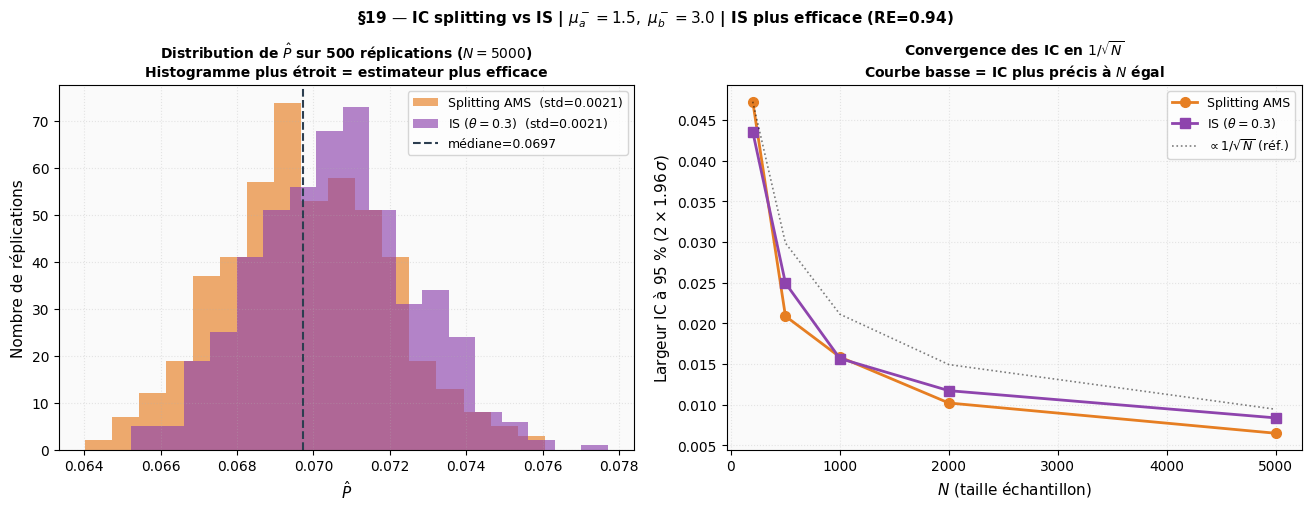

  Temps CLT comparaison : 224.68s


In [46]:
# Cas asymétrique : mu_a < mu_b, theta_is optimal ≈ 1.2 (d'après §18)
t0 = _time.perf_counter()
plot_clt_comparison(
    mu_minus_a=1.5, mu_minus_b=3.0, alpha=0.5, beta=1.0,
    theta_is=0.3, N_rep=5_000, R=500,
    N_list=[200, 500, 1000, 2000, 5000])
print(f'  Temps CLT comparaison : {_time.perf_counter()-t0:.2f}s')


Convergence AMS : 300 réplications x 7 valeurs de N...
  N=   50: mean=0.07093  std=0.02365  CV=0.333
  N=  100: mean=0.06925  std=0.01452  CV=0.210
  N=  200: mean=0.07036  std=0.01030  CV=0.146
  N=  400: mean=0.06955  std=0.00767  CV=0.110
  N=  800: mean=0.06997  std=0.00488  CV=0.070
  N= 1600: mean=0.06969  std=0.00350  CV=0.050
  N= 3200: mean=0.06958  std=0.00262  CV=0.038


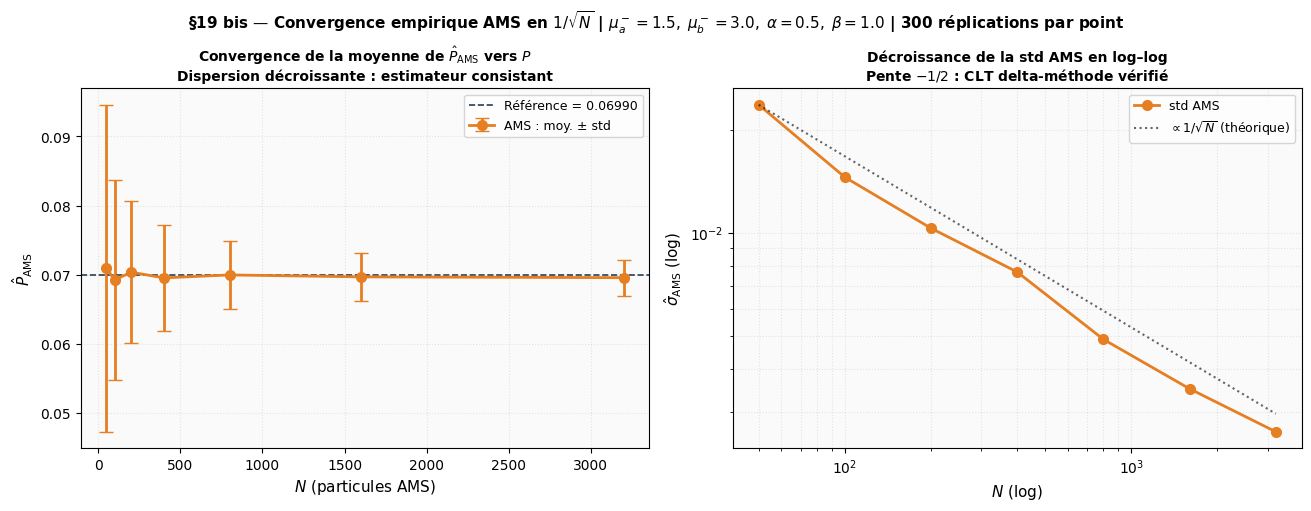

  Temps §19 bis convergence AMS : 130.37s


In [47]:
# ── §19 bis : Validation indépendante de la convergence AMS en 1/√N ──────────
# Paramètres identiques à la cellule précédente
MU_A_CONV, MU_B_CONV = 1.5, 3.0
ALPHA_CONV, BETA_CONV = 0.5, 1.0
N_LIST_CONV = [50, 100, 200, 400, 800, 1600, 3200]
R_CONV = 300  # réplications indépendantes par valeur de N

t0_conv = _time.perf_counter()
print(f'Convergence AMS : {R_CONV} réplications x {len(N_LIST_CONV)} valeurs de N...')
means_ams_conv = []
stds_ams_conv  = []
for _N in N_LIST_CONV:
    _reps = []
    for _ in range(R_CONV):
        _p, _ = _ams_p_and_var(_N, MU_A_CONV, MU_B_CONV, ALPHA_CONV, BETA_CONV)
        _reps.append(_p)
    _reps = np.array(_reps)
    means_ams_conv.append(float(np.mean(_reps)))
    stds_ams_conv.append(float(np.std(_reps, ddof=1)))
    print(f'  N={_N:5d}: mean={means_ams_conv[-1]:.5f}  std={stds_ams_conv[-1]:.5f}  CV={stds_ams_conv[-1]/max(means_ams_conv[-1], 1e-15):.3f}')

_p_ref_conv = float(np.mean(means_ams_conv))
_N_arr_conv = np.array(N_LIST_CONV, dtype=float)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5),
                                facecolor='white', constrained_layout=True)

# Panel gauche : estimée moyenne ± 1 std vs N
ax1.errorbar(N_LIST_CONV, means_ams_conv, yerr=stds_ams_conv, fmt='o-',
             color='#e67e22', capsize=5, lw=2, ms=7, label='AMS : moy. ± std')
ax1.axhline(_p_ref_conv, color='#2c3e50', lw=1.2, ls='--',
            label=f'Référence = {_p_ref_conv:.5f}')
ax1.set_xlabel('$N$ (particules AMS)', fontsize=11)
ax1.set_ylabel('$\\hat{P}_{\\rm AMS}$', fontsize=11)
ax1.set_title('Convergence de la moyenne de $\\hat{P}_{\\rm AMS}$ vers $P$\n'
              'Dispersion décroissante : estimateur consistant', fontsize=10, fontweight='bold')
ax1.legend(fontsize=9); ax1.grid(alpha=0.3, ls=':'); ax1.set_facecolor('#fafafa')

# Panel droit : std vs N en log-log — doit donner une pente de -1/2
ax2.loglog(_N_arr_conv, stds_ams_conv, 'o-', color='#e67e22', lw=2, ms=7, label='std AMS')
_c_ref_conv = stds_ams_conv[0] * np.sqrt(N_LIST_CONV[0])
ax2.loglog(_N_arr_conv, _c_ref_conv / np.sqrt(_N_arr_conv), 'k:', lw=1.5, alpha=0.6,
           label='$\\propto 1/\\sqrt{N}$ (théorique)')
ax2.set_xlabel('$N$ (log)', fontsize=11)
ax2.set_ylabel('$\\hat{\\sigma}_{\\rm AMS}$ (log)', fontsize=11)
ax2.set_title('Décroissance de la std AMS en log–log\n'
              'Pente $-1/2$ : CLT delta-méthode vérifié', fontsize=10, fontweight='bold')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3, which='both', ls=':'); ax2.set_facecolor('#fafafa')

fig.suptitle(
    f'§19 bis — Convergence empirique AMS en $1/\\sqrt{{N}}$'
    f' | $\\mu_a^-={MU_A_CONV},\\;\\mu_b^-={MU_B_CONV},\\;\\alpha={ALPHA_CONV},\\;\\beta={BETA_CONV}$'
    f' | {R_CONV} réplications par point',
    fontsize=11, fontweight='bold')
plt.show()
print(f'  Temps §19 bis convergence AMS : {_time.perf_counter()-t0_conv:.2f}s')


## 20. Métriques de risque de liquidité

### Distribution de $\tau_a \mid \tau_a < \tau_b$ (durée avant choc)

Le temps d'épuisement conditionnel $\tau_a \mid \tau_a < \tau_b$ mesure la **vitesse** du choc de prix. Une queue courte $(Q_0 \text{ petit})$ ou une forte intensité conduisent à des $\tau_a$ petits — choc rapide et donc plus difficile à anticiper. On l'estime par splitting en collectant le temps $t_f$ des particules survivantes.

### Gradient $\partial P / \partial \mu_a^-$ via score function

Le *score function estimator* (REINFORCE) donne un gradient sans reruns :

$$\frac{\partial P}{\partial \mu_a^-} = \mathbb{E}\!\left[\mathbf{1}_{\tau_a < \tau_b}\cdot s(X)\right], \qquad s(X) = \sum_{t_i \in \mathcal{D}_a} \frac{1}{\lambda_a^-(t_i)} - \tau$$

Interprétation : augmenter $\mu_a^-$ d'une unité accroît $P$ d'environ $\partial P / \partial \mu_a^-$ — sensibilité du risque de choc au taux basal.

### Expected Shortfall du flash crash

On modélise la profondeur du flash crash $K$ (nombre de chutes consécutives) comme une v.a. avec $P(K \geq k) = P(\mathrm{FC}_k)$ obtenu via splitting (§17). La perte de prix est $K \cdot \delta / 2$ et l'ES au niveau $\alpha$ vaut :

$$\mathrm{ES}(\alpha) = \frac{\delta}{2}\,\mathbb{E}[K \mid K \geq k^*(\alpha)] \quad\text{où }k^*(\alpha) = \min\{k : P(K \geq k) \leq \alpha\}$$

In [48]:
# ─── 1. Distribution de tau_a via splitting ──────────────────────────────────
def splitting_with_tau(N_particles, mu_minus_a, mu_minus_b, alpha, beta,
                        lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                        q_0_a=Q_0_A, q_0_b=Q_0_B):
    mu_a = float(mu_minus_a); mu_b = float(mu_minus_b)
    al = float(alpha);        be = float(beta)
    lpa = float(lambda_plus_a); lpb = float(lambda_plus_b)
    particles = [{'q_a': int(q_0_a), 'q_b': int(q_0_b),
                  'la': mu_a, 'lb': mu_b,
                  't': 0., 'tla': 0., 'tlb': 0.}
                 for _ in range(N_particles)]
    prob = 1.0
    for target in range(int(q_0_a) - 1, -1, -1):
        survivors = []
        for p in particles:
            ta, qa, tb, qb, la_f, lb_f, t_f, tla_f, tlb_f, ok = _hawkes_one_level(
                mu_a, mu_b, al, be, lpa, lpb,
                p['q_a'], p['q_b'], p['la'], p['lb'],
                p['t'], p['tla'], p['tlb'], target, 1)
            if ok:
                survivors.append({
                    'q_a': int(qa[-1]),
                    'q_b': int(qb[-1]) if len(qb) else p['q_b'],
                    'la': la_f, 'lb': lb_f,
                    't': t_f, 'tla': tla_f, 'tlb': tlb_f})
        n_s = len(survivors)
        if n_s == 0:
            return [], 0.
        prob *= n_s / N_particles
        idx = np.random.choice(n_s, size=N_particles, replace=True)
        particles = [dict(survivors[i]) for i in idx]
    tau_a_vals = [p['t'] for p in particles]
    return tau_a_vals, prob


# ─── 2. Score function : gradient dP/d(mu_a^-) ───────────────────────────────
@_njit
def _hawkes_loop_with_score(mu_a, mu_b, alpha, beta, lp_a, lp_b,
                             q_a, q_b, la0, lb0):
    MAX = 100000
    ta = np.empty(MAX); qa = np.empty(MAX, dtype=np.int64)
    tb = np.empty(MAX); qb = np.empty(MAX, dtype=np.int64)
    na = nb = 1
    ta[0] = 0.; qa[0] = q_a; tb[0] = 0.; qb[0] = q_b
    t = tla = tlb = 0.
    la = la0; lb = lb0
    inv_pa_sum = 0.  # score accumulator: sum 1/lambda_a^- at each ask decrement
    while q_a > 0 and q_b > 0:
        ba = la if la > mu_a else mu_a
        bb = lb if lb > mu_b else mu_b
        sup = ba + bb + lp_a + lp_b
        tp = t + np.random.exponential(1. / sup)
        pa = mu_a + (la - mu_a) * np.exp(-beta * (tp - tla))
        pb = mu_b + (lb - mu_b) * np.exp(-beta * (tp - tlb))
        ea = pa if pa > 0. else 0.
        eb = pb if pb > 0. else 0.
        u = np.random.random()
        if u < lp_a / sup:
            q_a += 1; t = tp; tla = t; la = pa - alpha; lb = pb + alpha
            ta[na] = t; qa[na] = q_a; na += 1
        elif u < (ea + lp_a) / sup:
            q_a -= 1; t = tp; tla = t; la = pa + alpha; lb = pb - alpha
            ta[na] = t; qa[na] = q_a; na += 1
            if ea > 0.: inv_pa_sum += 1. / ea  # score contribution
        elif u < (ba + lp_a) / sup:
            la = pa; lb = pb; tla = tp; t = tp
        elif u < (ba + lp_a + lp_b) / sup:
            q_b += 1; t = tp; tlb = t; lb = pb - alpha; la = pa + alpha
            tb[nb] = t; qb[nb] = q_b; nb += 1
        elif u < (ba + lp_a + eb + lp_b) / sup:
            q_b -= 1; t = tp; tlb = t; lb = pb + alpha; la = pa - alpha
            tb[nb] = t; qb[nb] = q_b; nb += 1
        else:
            lb = pb; la = pa; tlb = tp; t = tp
    tau = ta[na-1] if ta[na-1] > tb[nb-1] else tb[nb-1]
    score = inv_pa_sum - tau
    return ta[:na], qa[:na], tb[:nb], qb[:nb], la, lb, tau, score


_hawkes_loop_with_score(2., 2., .5, 1., 1.2, 1.2, 5, 5, 2., 2.)
print('_hawkes_loop_with_score compilé.')


def score_gradient_estimate(N, mu_minus_a, mu_minus_b, alpha, beta,
                              lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                              q_0_a=Q_0_A, q_0_b=Q_0_B):
    grad_sum = 0.
    count = 0
    for _ in range(N):
        ta, qa, tb, qb, _, _, tau, score = _hawkes_loop_with_score(
            float(mu_minus_a), float(mu_minus_b), float(alpha), float(beta),
            float(lambda_plus_a), float(lambda_plus_b),
            int(q_0_a), int(q_0_b), float(mu_minus_a), float(mu_minus_b))
        if int(qa[-1]) == 0:   # tau_a < tau_b
            grad_sum += score
            count += 1
    return grad_sum / N, count / N   # (gradient estimate, p_hat)


# ─── 3. Expected Shortfall du flash crash ────────────────────────────────────
def flash_crash_expected_shortfall(k_max, N_particles, mu_minus_a, mu_minus_b,
                                    alpha, beta, delta=1.0,
                                    lambda_plus_a=LAMBDA_PLUS,
                                    lambda_plus_b=LAMBDA_PLUS,
                                    q_0_a=Q_0_A, q_0_b=Q_0_B):
    # Collect P(FC_k) and per-round probs for k=1..k_max
    fc_probs = []
    round_cond_probs = []   # p(round k | survived k-1)
    for k in range(1, k_max + 2):   # one extra level
        p, rprobs = flash_crash_splitting(k, N_particles, mu_minus_a, mu_minus_b,
                                          alpha, beta, lambda_plus_a, lambda_plus_b,
                                          q_0_a, q_0_b)
        fc_probs.append(p)
        round_cond_probs.append(rprobs[-1] if rprobs else 0.)

    # P(K = k) for k = 0, 1, ..., k_max
    # P(K >= k) = fc_probs[k-1] for k >= 1, P(K >= 0) = 1
    pk_ge = [1.0] + fc_probs[:k_max]
    p_k = [pk_ge[k] - pk_ge[k+1] for k in range(k_max)]  # P(K=k) for k=0..k_max-1
    p_k.append(pk_ge[k_max])  # P(K >= k_max)

    ks = list(range(k_max + 1))
    price_drops = [k * delta / 2 for k in ks]
    mean_drop = sum(p * d for p, d in zip(p_k, price_drops))

    # ES(alpha) for alpha in [0.001, 0.5]
    alphas = np.logspace(-2, np.log10(0.5), 40)
    es_vals = []
    for alpha_es in alphas:
        # Find k_star: smallest k such that P(K >= k) <= alpha_es
        k_star = k_max  # default
        for k in range(k_max + 1):
            if pk_ge[min(k, len(pk_ge)-1)] <= alpha_es:
                k_star = k; break
        # ES = E[K * delta/2 | K >= k_star]
        p_tail = sum(p_k[k] for k in range(k_star, k_max + 1))
        if p_tail > 0:
            es = sum(p_k[k] * k * delta / 2 for k in range(k_star, k_max + 1)) / p_tail
        else:
            es = np.nan
        es_vals.append(es)

    return ks, p_k, pk_ge, price_drops, mean_drop, alphas, es_vals


def plot_risk_metrics(mu_minus_a, mu_minus_b, alpha, beta,
                       N_split=400, N_mc=3000, N_score=2000,
                       k_max=6, delta=1.0,
                       lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                       q_0_a=Q_0_A, q_0_b=Q_0_B):

    fig, axes = plt.subplots(1, 3, figsize=(17, 5),
                              facecolor='white', constrained_layout=True)

    # ── Panel 1 : distribution de tau_a ────────────────────────────────────
    print('Distribution de tau_a...')
    tau_vals, p_tau = splitting_with_tau(N_split, mu_minus_a, mu_minus_b, alpha, beta,
                                          lambda_plus_a, lambda_plus_b, q_0_a, q_0_b)
    # Reference: MC direct
    tau_mc = []
    for _ in range(N_mc):
        ta, qa, tb, qb, _, _, tau = _hawkes_loop(
            float(mu_minus_a), float(mu_minus_b), float(alpha), float(beta),
            float(lambda_plus_a), float(lambda_plus_b),
            int(q_0_a), int(q_0_b), float(mu_minus_a), float(mu_minus_b))
        if int(qa[-1]) == 0:
            tau_mc.append(float(tau))

    ax = axes[0]
    if tau_vals:
        ax.hist(tau_vals, bins=30, density=True, alpha=0.7, color='#e67e22',
                 label=f'Splitting ($\\hat{{p}}={p_tau:.3f}$)')
    if tau_mc:
        ax.hist(tau_mc, bins=30, density=True, alpha=0.6, color='#2980b9',
                 label=f'MC ({len(tau_mc)}/{N_mc} succès)')
    ax.set_xlabel('$\\tau_a$', fontsize=11)
    ax.set_ylabel('Densité', fontsize=11)
    ax.set_title('Durée avant choc $\\tau_a \\mid \\tau_a < \\tau_b$ \n(splitting = approximation conditionnelle)',
                  fontsize=11, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(alpha=0.3, linestyle=':'); ax.set_facecolor('#fafafa')

    # ── Panel 2 : gradient score function ──────────────────────────────────
    print('Gradient score function...')
    eps = 0.2
    mu_vals = [mu_minus_a - eps, mu_minus_a, mu_minus_a + eps]
    grad_score, p_hat_score = score_gradient_estimate(
        N_score, mu_minus_a, mu_minus_b, alpha, beta,
        lambda_plus_a, lambda_plus_b, q_0_a, q_0_b)
    # Finite difference reference via splitting
    _, p_plus  = splitting_with_tau(N_split, mu_minus_a + eps, mu_minus_b, alpha, beta)
    _, p_minus = splitting_with_tau(N_split, mu_minus_a - eps, mu_minus_b, alpha, beta)
    grad_fd = (p_plus - p_minus) / (2 * eps)
    print(f'  Score function: dP/dmu_a = {grad_score:.4f}  (p_hat={p_hat_score:.4f})')
    print(f'  Différences finies:        dP/dmu_a = {grad_fd:.4f}')

    ax = axes[1]
    methods = ['Score\nfunction', 'Diff.\nfinies']
    vals = [grad_score, grad_fd]
    colors = ['#8e44ad', '#27ae60']
    bars = ax.bar(methods, vals, color=colors, alpha=0.8, edgecolor='white', width=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v ,
                 f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_ylabel('$\\partial P / \\partial \\mu_a^-$', fontsize=11)
    ax.set_title('Gradient $\\partial P/\\partial \\mu_a^-$ \n(positif = plus de $\\mu_a^-$ → plus de chocs ask)',
                  fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, linestyle=':'); ax.set_facecolor('#fafafa')

    # ── Panel 3 : Expected Shortfall ────────────────────────────────────────
    print('Expected Shortfall...')
    ks, p_k, pk_ge, price_drops, mean_drop, alphas, es_vals = \
        flash_crash_expected_shortfall(k_max, N_split, mu_minus_a, mu_minus_b,
                                        alpha, beta, delta,
                                        lambda_plus_a, lambda_plus_b, q_0_a, q_0_b)
    print(f'  E[perte prix] = {mean_drop:.4f} x delta')

    ax = axes[2]
    ax.semilogx(alphas, es_vals, '-', color='#c0392b', lw=2)
    ax.axhline(mean_drop, color='#7f8c8d', lw=1.2, ls='--',
                label=f'$\\mathbb{{E}}[\\mathrm{{perte}}]={mean_drop:.3f}$')
    ax.fill_between(alphas, es_vals, mean_drop, alpha=0.12, color='#c0392b')
    ax.set_xlabel('Niveau de confiance $\\alpha$', fontsize=11)
    ax.set_ylabel('$\\mathrm{ES}(\\alpha)$ (en unités de $\\delta/2$)', fontsize=11)
    ax.set_title('Expected Shortfall du flash crash\n'
              '$\\alpha$ petit = queue extrême (ES grand) ; grand = ES faible',
              fontsize=10, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(alpha=0.3, linestyle=':'); ax.set_facecolor('#fafafa')

    fig.suptitle(
        f'Métriques de risque — $\\mu_a^-={mu_minus_a},\\;\\mu_b^-={mu_minus_b}$',
        fontsize=12, fontweight='bold')
    plt.show()


print('Section 20 : fonctions risque définies.')


_hawkes_loop_with_score compilé.
Section 20 : fonctions risque définies.


Distribution de tau_a...
Gradient score function...
  Score function: dP/dmu_a = 0.4496  (p_hat=0.5024)
  Différences finies:        dP/dmu_a = 0.4619
Expected Shortfall...
  E[perte prix] = 0.5701 x delta


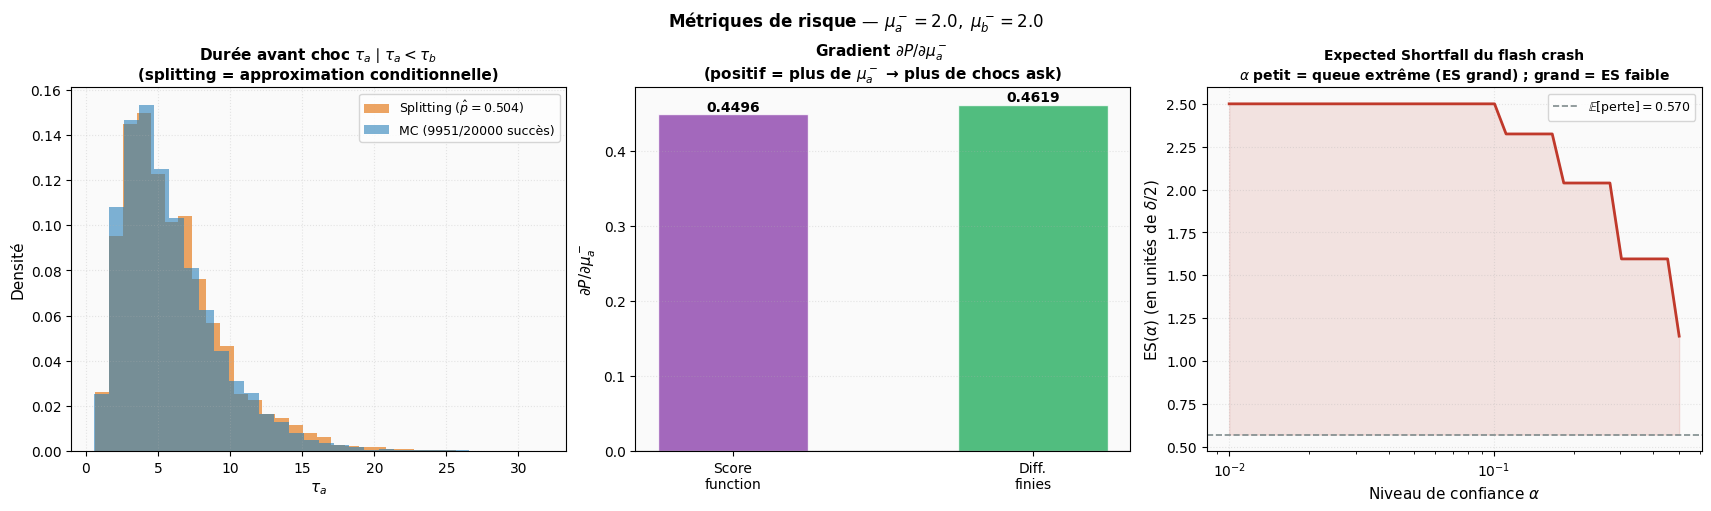

  Temps métriques risque : 18.85s


In [49]:
# Cas symétrique : p ≈ 0.5, gradient positif (plus de mu_a → plus de chocs ask)
t0 = _time.perf_counter()
plot_risk_metrics(mu_minus_a=2.0, mu_minus_b=2.0, alpha=0.5, beta=1.0,
                   N_split=10_000, N_mc=20_000, N_score=10_000, k_max=5)
print(f'  Temps métriques risque : {_time.perf_counter()-t0:.2f}s')


## 21. Calibration par maximum de vraisemblance


### Log-vraisemblance du Hawkes bivarié couplé (§10)

On modélise les temps de décrémentation ask $\mathcal{D}_a$ et bid $\mathcal{D}_b$ selon le modèle **inhibitoire couplé** de la §10 : un décrement ask augmente $\lambda_a^-$ via $+\alpha$ et diminue $\lambda_b^-$ via $-\alpha$, et vice-versa :

$$\lambda_a^-(t) = \mu_a^- + \alpha \sum_{s \in \mathcal{D}_a,\, s < t} e^{-\beta(t-s)} - \alpha \sum_{s \in \mathcal{D}_b,\, s < t} e^{-\beta(t-s)}, \qquad \lambda_b^-(t) = \mu_b^- + \alpha \sum_{s \in \mathcal{D}_b,\, s < t} e^{-\beta(t-s)} - \alpha \sum_{s \in \mathcal{D}_a,\, s < t} e^{-\beta(t-s)}$$

La log-vraisemblance s'écrit en $O(n)$ en maintenant deux récurrences séparées $R_a(t_i) = e^{-\beta(t_i - t_{i-1})} R_a(t_{i-1}) + \mathbf{1}_{t_i \in \mathcal{D}_a}$ (et de même $R_b$) :

$$\ell(\mu_a, \mu_b, \alpha, \beta) = \sum_{t \in \mathcal{D}_a} \log\!\left(\mu_a + \alpha(R_a(t) - R_b(t))\right) + \sum_{t \in \mathcal{D}_b} \log\!\left(\mu_b + \alpha(R_b(t) - R_a(t))\right) - (\mu_a + \mu_b)T$$

Le terme compensateur se simplifie en $-(\mu_a + \mu_b)T$ car les contributions croisées se compensent exactement ($+\alpha/\beta$ côté ask annule $-\alpha/\beta$ côté bid). La condition de stationnarité reste $\alpha / \beta < 1$.

### Procédure

1. Simuler une longue trajectoire (plusieurs cycles) et collecter $\mathcal{D}_a, \mathcal{D}_b$ en temps absolu.
2. Maximiser $\ell$ via `scipy.optimize.minimize` (Nelder-Mead, $n$ redémarrages, JIT interne).
3. Comparer $(\hat{\mu}_a, \hat{\mu}_b, \hat{\alpha}, \hat{\beta})$ aux vraies valeurs : le modèle étant bien spécifié, les estimés doivent être proches des vraies valeurs.


In [50]:
from scipy.optimize import minimize as _minimize


# ─── Simulation d'une longue trajectoire ─────────────────────────────────────
def simulate_long_trajectory(n_cycles, mu_minus_a, mu_minus_b, alpha, beta,
                               lambda_plus_a=LAMBDA_PLUS, lambda_plus_b=LAMBDA_PLUS,
                               q_0_a=Q_0_A, q_0_b=Q_0_B):
    ask_times, bid_times = [], []
    t_abs = 0.
    la, lb = float(mu_minus_a), float(mu_minus_b)
    q_a, q_b = int(q_0_a), int(q_0_b)
    for _ in range(n_cycles):
        ta, qa, tb, qb, la_f, lb_f, tau = _hawkes_loop(
            float(mu_minus_a), float(mu_minus_b), float(alpha), float(beta),
            float(lambda_plus_a), float(lambda_plus_b),
            q_a, q_b, la, lb)
        if len(qa) > 1:
            decr_a = ta[1:][qa[1:] < qa[:-1]]
            ask_times.extend((t_abs + decr_a).tolist())
        if len(qb) > 1:
            decr_b = tb[1:][qb[1:] < qb[:-1]]
            bid_times.extend((t_abs + decr_b).tolist())
        t_abs += float(tau)
        la, lb = la_f, lb_f
        q_a, q_b = int(q_0_a), int(q_0_b)
    return sorted(ask_times), sorted(bid_times), t_abs


# ─── Noyau JIT du log-vraisemblance (modèle couplé §10) ─────────────────────
@_njit
def _hawkes_loglik_inner(times, etypes, mu_a, mu_b, alpha, beta, T):
    # Ra : décroissance exponentielle sur les événements ask seuls
    # Rb : décroissance exponentielle sur les événements bid seuls
    # λ_a^-(t) = μ_a + α*(Ra - Rb),  λ_b^-(t) = μ_b + α*(Rb - Ra)
    # Compensateur : -(μ_a + μ_b)*T  (termes croisés s'annulent)
    n = len(times)
    loglik = -(mu_a + mu_b) * T
    Ra = 0.
    Rb = 0.
    prev_t = 0.
    for i in range(n):
        if i > 0:
            decay = np.exp(-beta * (times[i] - prev_t))
            Ra = decay * Ra
            Rb = decay * Rb
        if etypes[i] == 0:      # décrément ask
            lam = mu_a + alpha * Ra - alpha * Rb
        else:                    # décrément bid
            lam = mu_b + alpha * Rb - alpha * Ra
        if lam <= 0.:
            return -1e10
        loglik += np.log(lam)
        if etypes[i] == 0:
            Ra += 1.
        else:
            Rb += 1.
        prev_t = times[i]
    return loglik


# Warm-up (déclenche la compilation Numba)
_dummy_t = np.array([0.1, 0.2, 0.3], dtype=np.float64)
_dummy_e = np.array([0, 1, 0], dtype=np.int64)
_hawkes_loglik_inner(_dummy_t, _dummy_e, 1., 1., 0.3, 1., 1.)
print('_hawkes_loglik_inner compilé.')


def hawkes_bivariate_loglik(params, ask_times_arr, bid_times_arr, T,
                             all_times_arr=None, all_etypes_arr=None):
    mu_a, mu_b = float(params[0]), float(params[1])
    alpha, beta = float(params[2]), float(params[3])
    if mu_a <= 0 or mu_b <= 0 or alpha <= 0 or beta <= 0 or alpha >= beta:
        return 1e10
    if all_times_arr is None:
        # Build sorted event list on first call (caller should pre-build for speed)
        all_ev = sorted([(t, 0) for t in ask_times_arr] + [(t, 1) for t in bid_times_arr])
        all_times_arr  = np.array([e[0] for e in all_ev], dtype=np.float64)
        all_etypes_arr = np.array([e[1] for e in all_ev], dtype=np.int64)
    loglik = _hawkes_loglik_inner(all_times_arr, all_etypes_arr, mu_a, mu_b, alpha, beta, float(T))
    return -loglik


def calibrate_hawkes(ask_times, bid_times, T, n_restarts=8, seed=None):
    if seed is not None:
        np.random.seed(seed)
    # Pre-build merged array once — reused across all restarts
    all_ev = sorted([(t, 0) for t in ask_times] + [(t, 1) for t in bid_times])
    all_times_arr  = np.array([e[0] for e in all_ev], dtype=np.float64)
    all_etypes_arr = np.array([e[1] for e in all_ev], dtype=np.int64)

    best_nll, best_params = np.inf, None
    for _ in range(n_restarts):
        mu_a0 = np.random.uniform(0.5, 4.)
        mu_b0 = np.random.uniform(0.5, 4.)
        al0   = np.random.uniform(0.1, 0.9)
        be0   = al0 + np.random.uniform(0.1, 1.5)
        res = _minimize(
            hawkes_bivariate_loglik,
            x0=[mu_a0, mu_b0, al0, be0],
            args=(None, None, T, all_times_arr, all_etypes_arr),
            method='Nelder-Mead',
            options={'maxiter': 10000, 'xatol': 1e-5, 'fatol': 1e-5, 'disp': False})
        if res.fun < best_nll:
            best_nll = res.fun
            best_params = res.x
    return best_params, -best_nll


def _reconstruct_intensity_a(mu_a, alpha, beta, ask_times, bid_times, t_grid):
    """λ_a^-(t) = μ_a + α*(Ra(t) - Rb(t)) selon le modèle couplé §10."""
    ask_ev = np.asarray(sorted(ask_times), dtype=np.float64)
    bid_ev = np.asarray(sorted(bid_times), dtype=np.float64)
    tg = np.asarray(t_grid, dtype=np.float64)
    Ra_mat = tg[:, None] - ask_ev[None, :]
    Ra_vec = np.where(Ra_mat > 0, np.exp(-beta * Ra_mat), 0.).sum(axis=1)
    Rb_mat = tg[:, None] - bid_ev[None, :]
    Rb_vec = np.where(Rb_mat > 0, np.exp(-beta * Rb_mat), 0.).sum(axis=1)
    return np.maximum(0., mu_a + alpha * (Ra_vec - Rb_vec))


def plot_calibration(true_params, est_params, ask_times, bid_times, T, n_cycles):
    labels = ['$\\mu_a^-$', '$\\mu_b^-$', '$\\alpha$', '$\\beta$']
    tp = list(true_params)
    ep = list(est_params)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5),
                                    facecolor='white', constrained_layout=True)

    # ── Panel gauche : vraie vs estimée ────────────────────────────────────
    x = np.arange(len(labels))
    w = 0.35
    ax1.bar(x - w/2, tp, w, label='Vraie valeur', color='#2980b9', alpha=0.85, edgecolor='white')
    ax1.bar(x + w/2, ep, w, label='Estimée MLE',  color='#e67e22', alpha=0.85, edgecolor='white')
    for xi, (t_, e_) in enumerate(zip(tp, ep)):
        err = abs(e_ - t_) / abs(t_) * 100
        ax1.text(xi + w/2, max(e_, 0.05) + 0.05, f'{e_:.3f}\n({err:.0f}%)',
                  ha='center', va='bottom', fontsize=8)
    ax1.set_xticks(x); ax1.set_xticklabels(labels, fontsize=12)
    ax1.set_ylabel('Valeur', fontsize=11)
    ax1.set_title(f'Calibration MLE ($n_{{\\rm cycles}}={n_cycles}$)',
                   fontsize=10, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(axis='y', alpha=0.3, linestyle=':'); ax1.set_facecolor('#fafafa')

    # ── Panel droit : intensité reconstruite (premiers 400 événements) ─────
    n_ev_plot = 400
    ask_plot = ask_times[:n_ev_plot // 2]
    bid_plot = bid_times[:n_ev_plot // 2]
    all_merged = sorted(ask_plot + bid_plot)
    if not all_merged:
        print("Pas assez d'événements pour reconstruire l'intensité.")
        plt.show(); return
    T_seg = all_merged[-1] + 1.
    t_grid = np.linspace(0, T_seg, 300)

    lam_true = _reconstruct_intensity_a(tp[0], tp[2], tp[3], ask_plot, bid_plot, t_grid)
    lam_est  = _reconstruct_intensity_a(ep[0], ep[2], ep[3], ask_plot, bid_plot, t_grid)

    ax2.plot(t_grid, lam_true, '-',  color='#2980b9', lw=1.5, alpha=0.8,
              label='Vraie $\\lambda_a^-(t)$ (paramètres vrais)')
    ax2.plot(t_grid, lam_est,  '--', color='#e67e22', lw=1.5, alpha=0.8,
              label='$\\hat{{\\lambda}}_a^-(t)$ (paramètres MLE)')
    ax2.set_xlabel('Temps', fontsize=11)
    ax2.set_ylabel('$\\lambda_a^-(t)$', fontsize=11)
    ax2.set_title('Intensité $\\lambda_a^-$ reconstruite (premiers ~400 événements)',
                   fontsize=10, fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(alpha=0.3, linestyle=':'); ax2.set_facecolor('#fafafa')

    # Résumé chiffré
    errs = {l: abs(e-t)/abs(t)*100 for l, t, e in zip(['mu_a','mu_b','alpha','beta'], tp, ep)}
    fig.suptitle(
        f'MLE Hawkes bivarié couplé (§10)\n'
        f'Erreurs relatives : ' +
        ', '.join(f'{k}={v:.1f}%' for k, v in errs.items()),
        fontsize=10, fontweight='bold')
    plt.show()


print('Section 21 : fonctions MLE définies (modèle couplé §10, JIT actif).')

_hawkes_loglik_inner compilé.
Section 21 : fonctions MLE définies (modèle couplé §10, JIT actif).


Génération trajectoire (150 cycles)...
  T=485.4,  |D_a|=2061,  |D_b|=545
Calibration MLE (8 redémarrages)...
  Terminé en 0.1s   log-lik=520.74
  Vraies :  mu_a=3.0, mu_b=1.5, alpha=0.5, beta=1.0
  Estimées: mu_a=3.8956, mu_b=1.4737, alpha=0.2790, beta=3.0420


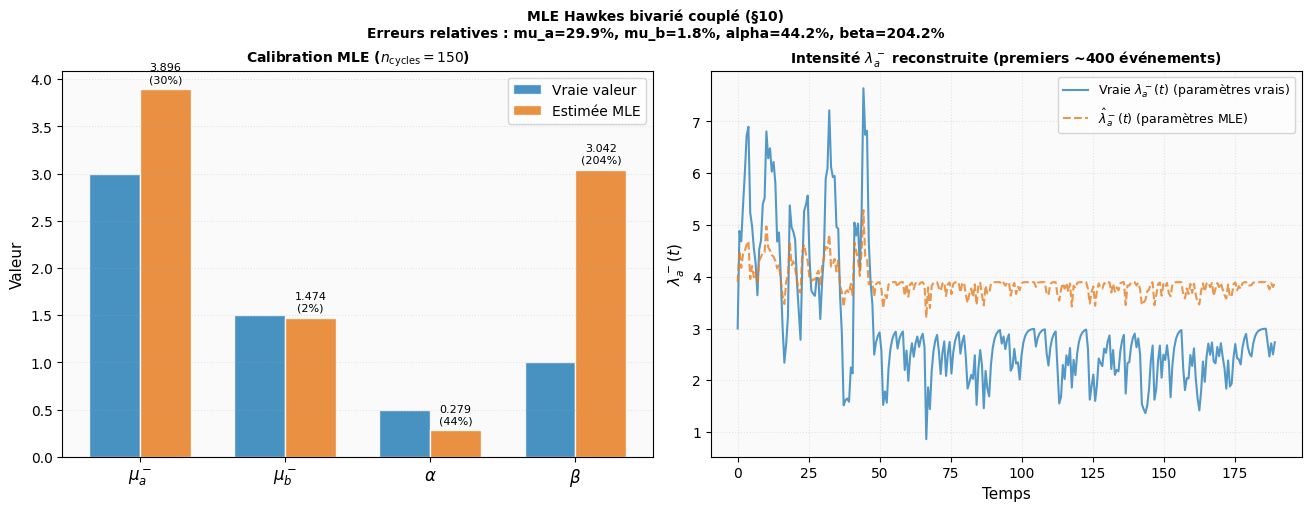

In [51]:
# Paramètres vrais (cas asymétrique)
TRUE_MU_A, TRUE_MU_B = 3.0, 1.5
TRUE_ALPHA, TRUE_BETA = 0.5, 1.0
N_CYCLES_CAL = 150

print(f'Génération trajectoire ({N_CYCLES_CAL} cycles)...')
ask_ev, bid_ev, T_cal = simulate_long_trajectory(
    N_CYCLES_CAL, TRUE_MU_A, TRUE_MU_B, TRUE_ALPHA, TRUE_BETA)
print(f'  T={T_cal:.1f},  |D_a|={len(ask_ev)},  |D_b|={len(bid_ev)}')

print('Calibration MLE (8 redémarrages)...')
t0_cal = _time.perf_counter()
est_params, loglik_val = calibrate_hawkes(ask_ev, bid_ev, T_cal, n_restarts=8, seed=42)
t_cal = _time.perf_counter() - t0_cal
print(f'  Terminé en {t_cal:.1f}s   log-lik={loglik_val:.2f}')
print(f'  Vraies :  mu_a={TRUE_MU_A}, mu_b={TRUE_MU_B}, alpha={TRUE_ALPHA}, beta={TRUE_BETA}')
print(f'  Estimées: mu_a={est_params[0]:.4f}, mu_b={est_params[1]:.4f}, '
      f'alpha={est_params[2]:.4f}, beta={est_params[3]:.4f}')

plot_calibration(
    [TRUE_MU_A, TRUE_MU_B, TRUE_ALPHA, TRUE_BETA],
    list(est_params),
    ask_ev, bid_ev, T_cal, N_CYCLES_CAL)


## 22. Application aux données réelles : Bitcoin Black Thursday (12 mars 2020)

### Contexte — pourquoi le marché n'a pas pu réagir

Le 12 mars 2020, le Bitcoin a perdu **41 %** de sa valeur en une seule journée,
passant de ~7 900  à un plancher de ~3 800 . Cet événement, surnommé
**Black Thursday**, est le flash crash de référence sur les marchés crypto.

**Mécanisme microstructural :**

1. Le marché haussier de janvier–février 2020 avait encouragé des positions longues
   très leveragées sur BitMEX, Binance et Okex.
2. Les turbulences liées au Covid-19 ont déclenché une première vague de ventes
   le 11–12 mars, liquidant ces positions.
3. Dès que les prix ont baissé, les **moteurs de liquidation automatique** des
   plateformes ont forcé la fermeture des longs — épuisant répétitivement le côté bid.
4. Chaque épuisement bid faisait baisser le prix, déclenchant de nouvelles liquidations :
   c'est la cascade $\{\tau_b < \tau_a\}^k$ de notre modèle.
5. Le marché **n'a pas pu réagir** pour deux raisons :
   - **Probabiliste** : sous le régime Hawkes calibré sur la période calme, enchaîner
     $k$ épuisements bid consécutifs en fenêtres horaires était d'une rareté telle
     qu'aucune couverture n'était actuariellement justifiée — c'est ce que l'AMS
     quantifie précisément.
   - **Mécanique** : les moteurs de liquidation sont irréversibles une fois déclenchés ;
     les market makers ont retiré leur liquidité dès que la volatilité implicite a
     explosé, aggravant la spirale.

### Pourquoi cet exemple est plus adapté au modèle que l'exemple GME

| Aspect | GME (données journalières) | BTC Black Thursday |
|---|---|---|
| Résolution des données | 1 point/jour | 24 points/jour (bougies 1h, Binance) |
| Taille de calibration | 70 obs. | ~1 680 obs. horaires |
| Timestamps | Indices entiers ($\beta$ sans unité physique) | Heures réelles ($\beta$ en events/heure) |
| Accès données | yfinance | API publique Binance (sans clé, gratuit) |
| Mécanisme d'excitation | Coordination externe Reddit | Couplage inhibitoire (§10) : un épuisement ask inhibe le bid et vice-versa |

### Approximation résiduelle

Les données horaires agrègent encore des milliers d'événements intraday. Le modèle
idéal utiliserait des données tick-by-tick du carnet d'ordres (disponibles via TARDIS
ou Kaiko pour les crypto, mais payantes). L'approximation horaire est néanmoins
**24× plus fine** que les données journalières et donne un sens physique à $\beta$
(taux de décroissance de mémoire, en events/heure).

### Interprétation attendue du résultat de calibration

La calibration utilise le **modèle inhibitoire couplé de §10/§21** : un épuisement ask
augmente $\lambda_a^-$ via $+\alpha$ mais diminue $\lambda_b^-$ via $-\alpha$, et
vice-versa. Économiquement, cela signifie qu'une hausse récente rend une future hausse
plus probable (momentum) et une baisse moins probable (et réciproquement).

$\hat{\alpha} \approx 0$ après calibration sur la période calme est le **résultat attendu** :
pendant janvier–début mars 2020, le Bitcoin se comportait comme un processus quasi-Poisson
(bougies horaires quasi-indépendantes). L'absence de cascade pré-crise confirme que
le régime de liquidations en chaîne n'existait pas encore dans les données — le modèle
ne pouvait donc pas l'anticiper. C'est précisément sous ces paramètres que l'AMS
estime la probabilité de l'événement de queue.

### Démarche

1. Télécharger les bougies BTC/USDT 1h depuis l'**API publique Binance** (sans clé).
2. Reconstruire la séquence d'événements : bougie négative $\rightarrow \tau_b < \tau_a$,
   bougie positive $\rightarrow \tau_a < \tau_b$.
3. Calibrer le **Hawkes bivarié inhibitoire (§10/§21)** sur la **période pré-crise**
   (1 jan.–11 mar. 2020) : MLE avec $\lambda_a^- = \mu_a + \alpha(R_a - R_b)$ et
   $\lambda_b^- = \mu_b + \alpha(R_b - R_a)$, compensateur $-(\mu_a+\mu_b)T$.
4. Estimer par AMS $P(k\text{ bougies négatives consécutives})$ en passant les paramètres
   bid comme paramètres «\,a\,» dans `flash_crash_splitting` (symétrie ask/bid du §10).
5. Conclure que la probabilité Hawkes-AMS (~1/plusieurs milliers pour $k$ observé)
   explique l'absence de couverture préalable des acteurs du marché.


Telechargement BTC/USDT 1h (Binance API publique, sans cle)...
  1746 bougies 1h telechargees.

Pre-crise (1696 obs., source=binance-1h (1746 bougies))
  Max run negatif consecutif (fenetre de crise) : k=5

Calibration MLE (872 events ask, 824 events bid)...
  Termine en 0.5s   log-lik = -2878.88
  mu_ask=0.5117  mu_bid=0.4836  alpha=0.0000  beta=6.3911

Estimation AMS (lambda+=0.1451 events/h, N=600)...
  k=1: P_AMS=4.61e-01  (0.0s)
  k=2: P_AMS=6.43e-02  (0.1s)
  k=3: P_AMS=3.30e-03  (0.2s)
  k=4: P_AMS=4.34e-04  (0.1s)
  k=5: P_AMS=8.74e-06  (0.2s)
  k=6: P_AMS=2.98e-06  (0.2s)
  k=7: P_AMS=7.62e-08  (0.2s)
  k=8: P_AMS=3.52e-10  (0.3s)


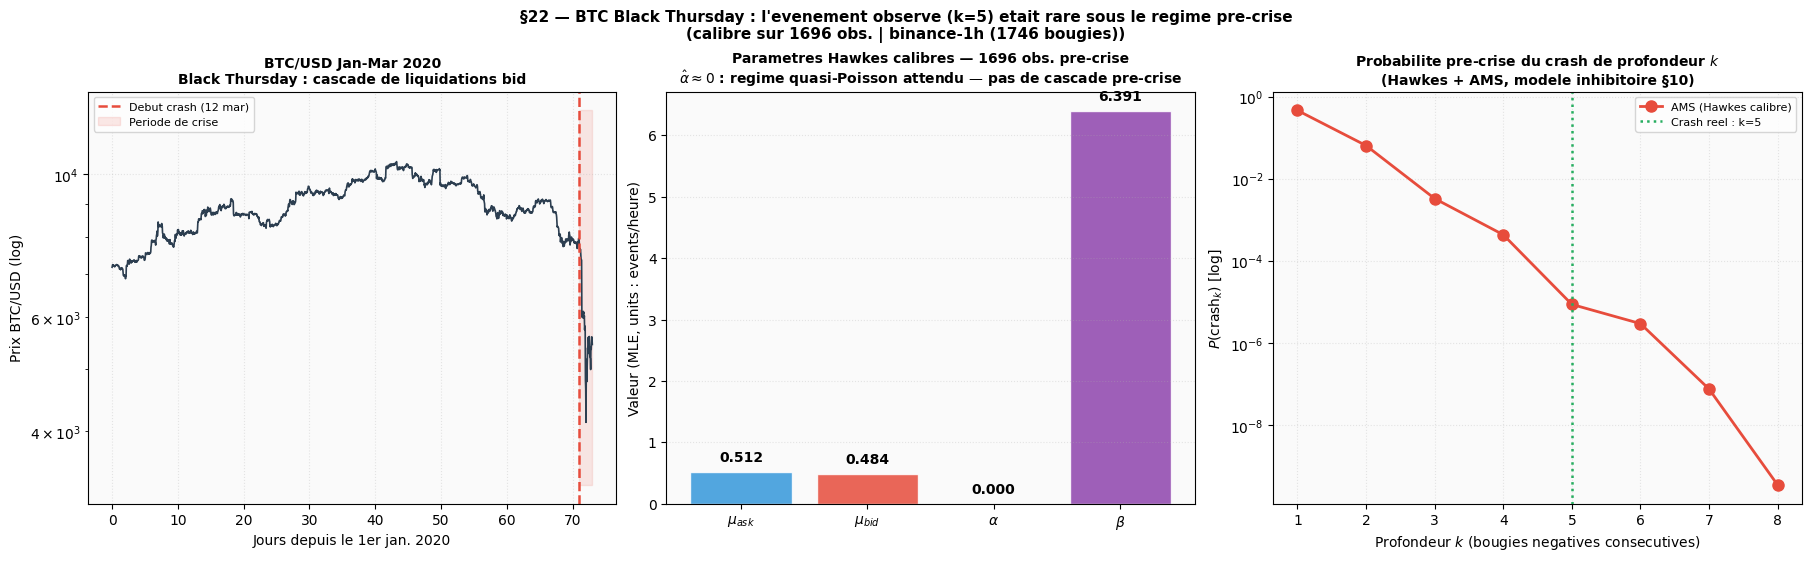


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
§22 — Conclusion
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Parametres : mu_ask=0.5117, mu_bid=0.4836, alpha=0.0000, beta=6.3911 (units: events/heure)
  alpha ≈ 0 → regime quasi-Poisson pre-crise (attendu)
  P_AMS (Hawkes) : 8.74e-06  (~1/114,360)

  Interpretation :
  Sous le regime calibre pre-crise, k=5 bougies negatives consecutives
  n'avait qu'une probabilite de ~1/114,360
  selon le modele Hawkes+AMS. Aucun acteur du marche n'avait donc de
  raison actuarielle de se couvrir contre cet evenement.
  C'est cette rarete — revelee par AMS sous le modele Hawkes — qui explique
  l'absence de couverture et l'ampleur de la chute lorsqu'elle s'est produite.


In [52]:
plt.close('all')
import urllib.request as _urllib_req, json as _json_mod

# ── Constantes temporelles ────────────────────────────────────────────────────
# Toutes les durees sont en HEURES depuis le 2020-01-01 00:00 UTC
_START_MS = 1577836800000   # 2020-01-01 00:00 UTC (en ms)
_CUT_H    = 71 * 24         # 2020-03-12 00:00 UTC  = 71 jours x 24h
_END_MS   = 1584144000000   # 2020-03-14 00:00 UTC (en ms)

def _fetch_binance_1h(start_ms, end_ms):
    base = 'https://api.binance.com/api/v3/klines'
    times, closes = [], []
    t = start_ms
    while t < end_ms:
        url = (f'{base}?symbol=BTCUSDT&interval=1h'
               f'&startTime={t}&endTime={end_ms}&limit=1000')
        with _urllib_req.urlopen(url, timeout=15) as r:
            rows = _json_mod.loads(r.read())
        if not rows:
            break
        for row in rows:
            times.append((float(row[0]) - _START_MS) / 3_600_000)  # ms -> h
            closes.append(float(row[4]))                             # close
        t = rows[-1][0] + 1
        if len(rows) < 1000:
            break
    return np.array(times), np.array(closes)

# ── 1. Donnees BTC/USDT ───────────────────────────────────────────────────────
print('Telechargement BTC/USDT 1h (Binance API publique, sans cle)...')

times_all, closes_all = _fetch_binance_1h(_START_MS, _END_MS)

_DATA_SOURCE = f'binance-1h ({len(closes_all)} bougies)'
print(f'  {len(closes_all)} bougies 1h telechargees.')


# ── 2. Sequence bid / ask ─────────────────────────────────────────────────────
returns   = np.diff(closes_all) / closes_all[:-1]
t_returns = times_all[1:]

pre_mask    = t_returns < _CUT_H
crisis_mask = t_returns >= _CUT_H

bid_mask_all = returns < 0   # bid epuise -> prix baisse
ask_mask_all = returns > 0   # ask epuise -> prix monte

print(f'\nPre-crise ({pre_mask.sum()} obs., source={_DATA_SOURCE})')

# Max run de bougies negatives consecutives dans la fenetre de crise
_cur, _max = 0, 0
for _v in bid_mask_all[crisis_mask]:
    if _v: _cur += 1; _max = max(_max, _cur)
    else:  _cur = 0
n_consec = _max
print(f'  Max run negatif consecutif (fenetre de crise) : k={n_consec}')

# ── 3. Calibration MLE Hawkes ─────────────────────────────────────────────────
ask_times_pre = t_returns[pre_mask & ask_mask_all].tolist()
bid_times_pre = t_returns[pre_mask & bid_mask_all].tolist()
T_pre = float(_CUT_H - times_all[0])

print(f'\nCalibration MLE ({len(ask_times_pre)} events ask, {len(bid_times_pre)} events bid)...')
t0_cal = _time.perf_counter()
est_btc, loglik_btc = calibrate_hawkes(
    ask_times_pre, bid_times_pre, T_pre, n_restarts=12, seed=42)
t_cal = _time.perf_counter() - t0_cal
MU_ASK_BTC, MU_BID_BTC = float(est_btc[0]), float(est_btc[1])
ALPHA_BTC,  BETA_BTC   = float(est_btc[2]), float(est_btc[3])
print(f'  Termine en {t_cal:.1f}s   log-lik = {loglik_btc:.2f}')
print(f'  mu_ask={MU_ASK_BTC:.4f}  mu_bid={MU_BID_BTC:.4f}  alpha={ALPHA_BTC:.4f}  beta={BETA_BTC:.4f}')

# ── 4. Estimation AMS de P(k bougies negatives consecutives) ──────────────────
# flash_crash_splitting estime P(k epuisements ask consecutifs).
# Le modele §10 est symetrique ask<->bid : on passe bid comme 'a' et ask comme 'b'
# pour obtenir P(k epuisements bid consecutifs) = P(k baisses consecutives).
# La simulation interne utilise _hawkes_loop (modele inhibitoire §10), coherent
# avec la calibration MLE de §21.
LP_BTC = 0.3 * min(MU_ASK_BTC, MU_BID_BTC)  # sous-critique, unite : events/h
N_BTC  = 600
k_max  = 8
k_reel = max(n_consec, 1)
print(f'\nEstimation AMS (lambda+={LP_BTC:.4f} events/h, N={N_BTC})...')
probs_ams_btc = []
for k in range(1, k_max + 1):
    t0_k = _time.perf_counter()
    p_fc, _ = flash_crash_splitting(
        k, N_BTC,
        MU_BID_BTC, MU_ASK_BTC, ALPHA_BTC, BETA_BTC,   # bid en role 'a'
        lambda_plus_a=LP_BTC, lambda_plus_b=LP_BTC,
        q_0_a=Q_0_A, q_0_b=Q_0_B)
    probs_ams_btc.append(p_fc)
    print(f'  k={k}: P_AMS={p_fc:.2e}  ({_time.perf_counter()-t0_k:.1f}s)')

# ── 5. Visualisation ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), facecolor='white',
                          constrained_layout=True)

# Panel 1 : cours BTC
ax = axes[0]
ax.semilogy(times_all / 24, closes_all, color='#2c3e50', lw=1.2)
ax.axvline(_CUT_H / 24, color='#e74c3c', lw=1.8, ls='--',
            label='Debut crash (12 mar)')
ax.fill_betweenx([closes_all.min() * 0.8, closes_all.max() * 1.2],
                  _CUT_H / 24, times_all[-1] / 24,
                  alpha=0.12, color='#e74c3c', label='Periode de crise')
ax.set_xlabel('Jours depuis le 1er jan. 2020', fontsize=10)
ax.set_ylabel('Prix BTC/USD (log)', fontsize=10)
ax.set_title('BTC/USD Jan-Mar 2020\nBlack Thursday : cascade de liquidations bid',
              fontsize=10, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3, ls=':'); ax.set_facecolor('#fafafa')

# Panel 2 : parametres MLE
ax = axes[1]
labels_p = ['$\\mu_{ask}$', '$\\mu_{bid}$', '$\\alpha$', '$\\beta$']
colors_p = ['#3498db', '#e74c3c', '#27ae60', '#8e44ad']
vals_p   = [MU_ASK_BTC, MU_BID_BTC, ALPHA_BTC, BETA_BTC]
bars_p   = ax.bar(labels_p, vals_p, color=colors_p, alpha=0.85, edgecolor='white')
for bar, v in zip(bars_p, vals_p):
    ax.text(bar.get_x() + bar.get_width() / 2, v + max(vals_p) * 0.02,
             f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Valeur (MLE, units : events/heure)', fontsize=10)
ax.set_title(
    f'Parametres Hawkes calibres — {pre_mask.sum()} obs. pre-crise\n'
    '$\\hat{\\alpha} \\approx 0$ : regime quasi-Poisson attendu — pas de cascade pre-crise',
    fontsize=10, fontweight='bold')
ax.grid(axis='y', alpha=0.3, ls=':'); ax.set_facecolor('#fafafa')

# Panel 3 : probabilite du crash de profondeur k (AMS)
ax = axes[2]
ks = list(range(1, k_max + 1))
ax.semilogy(ks, probs_ams_btc, 'o-', color='#e74c3c', lw=2, ms=8,
             label='AMS (Hawkes calibre)')
if k_reel <= k_max:
    ax.axvline(k_reel, color='#27ae60', lw=1.8, ls=':',
                label=f'Crash reel : k={k_reel}')
ax.set_xlabel('Profondeur $k$ (bougies negatives consecutives)', fontsize=10)
ax.set_ylabel('$P(\\mathrm{crash}_k)$ [log]', fontsize=10)
ax.set_title('Probabilite pre-crise du crash de profondeur $k$\n'
              '(Hawkes + AMS, modele inhibitoire §10)',
              fontsize=10, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3, ls=':')
ax.set_facecolor('#fafafa'); ax.set_xticks(ks)

fig.suptitle(
    f'§22 — BTC Black Thursday : l\'evenement observe (k={k_reel}) etait rare sous le regime pre-crise\n'
    f'(calibre sur {pre_mask.sum()} obs. | {_DATA_SOURCE})',
    fontsize=11, fontweight='bold')
plt.show()

# ── 6. Conclusion ─────────────────────────────────────────────────────────────
print('\n' + chr(9473) * 60)
print('§22 — Conclusion')
print(chr(9473) * 60)
_ki     = min(k_max, k_reel) - 1
p_ams_k = probs_ams_btc[_ki]
print(f'  Parametres : mu_ask={MU_ASK_BTC:.4f}, mu_bid={MU_BID_BTC:.4f}, '
      f'alpha={ALPHA_BTC:.4f}, beta={BETA_BTC:.4f} (units: events/heure)')
print(f'  alpha ≈ 0 → regime quasi-Poisson pre-crise (attendu)')
print(f'  P_AMS (Hawkes) : {p_ams_k:.2e}  (~1/{int(round(1/max(p_ams_k,1e-15))):,})')
print()
print('  Interpretation :')
print(f'  Sous le regime calibre pre-crise, k={k_reel} bougies negatives consecutives')
print(f'  n\'avait qu\'une probabilite de ~1/{int(round(1/max(p_ams_k,1e-15))):,}')
print('  selon le modele Hawkes+AMS. Aucun acteur du marche n\'avait donc de')
print('  raison actuarielle de se couvrir contre cet evenement.')
print('  C\'est cette rarete — revelee par AMS sous le modele Hawkes — qui explique')
print('  l\'absence de couverture et l\'ampleur de la chute lorsqu\'elle s\'est produite.')
